# Lección 10.3 · GWAS: Manhattan, QQ plots y corrección múltiple

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-10-poblaciones-gwas/10.3_gwas.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 10 — Genómica de poblaciones y GWAS** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~4 horas | Intermedio–avanzado | Lecciones 10.1 (Hardy-Weinberg) y 10.2 (ligamiento y PCA); regresión lineal y valores $p$ |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Explicar** qué pregunta responde un estudio de asociación del genoma completo (GWAS), en qué se diferencian los
   diseños de casos y controles y de rasgo cuantitativo, y **calcular** con la ecuación de $q^2$ cuántas personas hacen
   falta para detectar una variante de efecto pequeño.
2. **Ajustar** el modelo aditivo (regresión lineal o logística con $g_{ij}\in\{0,1,2\}$) y **reconocer** la prueba de
   tendencia de Armitage como su versión para casos y controles.
3. **Diagnosticar** la estratificación poblacional con $\hat\lambda_{GC}$ y el gráfico QQ, y **corregirla** con
   componentes principales, primero en el ejemplo del libro y luego en genotipos **reales** del Proyecto 1000 Genomas,
   donde fabricaremos (y desarmaremos) una asociación espuria con el gen de la lactasa, como la que describieron
   Campbell *et al.* (2005).
4. **Aplicar** Bonferroni, el umbral $5\times10^{-8}$ y el procedimiento de Benjamini-Hochberg, y **explicar** qué error
   controla cada uno.
5. **Construir** e **interpretar** gráficos Manhattan y QQ (con su banda de confianza) sin caer en las trampas clásicas.
6. **Consultar** el GWAS Catalog por su API y **situar** los hallazgos reales de la diabetes tipo 2 frente al problema de
   la heredabilidad faltante.

## 🗺️ Mapa de la clase

1. La encuesta de los paraguas: una asociación sin causa
2. La idea y el diseño de un GWAS
3. El modelo aditivo: regresión, prueba de tendencia y potencia (📈 la figura de potencia del libro)
4. Estratificación poblacional: $\lambda_{GC}$ y componentes principales (ejemplo del libro)
5. 🧪 Caso real: una falsa asociación con la lactasa en 2 504 genomas (🎬 animación, 🔍 interactivo)
6. Comparaciones múltiples: Bonferroni, $5\times10^{-8}$ y Benjamini-Hochberg (🎬 animación, 🔍 interactivo)
7. Gráficos QQ y Manhattan: construirlos y leerlos
8. 🧪 Lo que los GWAS encontraron: la diabetes tipo 2 en el GWAS Catalog (🔍 interactivo) y la heredabilidad faltante
9. Ejercicios, resumen y lecturas

> 📖 **Compañero del libro.** Esta lección acompaña la sección «GWAS: Manhattan, QQ plots y corrección múltiple» del
> capítulo 10 del libro *Bioinformática Práctica*. Usamos sus símbolos ($g_{ij}$, $\beta_j$, $z_j$, $q_j^2$,
> $\hat\lambda_{GC}$, $p_{(k)}$, $k^\ast$, $M_0$), sus funciones (`gwas_lineal`, `lambda_gc`, `benjamini_hochberg`) y
> reproducimos, cifra por cifra y con las mismas semillas, sus ejemplos resueltos («Una asociación espuria y su
> corrección», «Bonferroni frente a Benjamini-Hochberg») y sus figuras de potencia, QQ y Manhattan. El notebook se
> puede seguir sin el libro.

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import io, gzip, json, math, time
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from matplotlib.patches import FancyBboxPatch

try:
    import requests
except ImportError:
    %pip install -q requests
    import requests

RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"

def course_file(name):
    """Ruta local de un archivo del curso: 1) copia en ../data; 2) descarga desde el repositorio de GitHub."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return local
    if not os.path.exists(os.path.basename(name)):
        urllib.request.urlretrieve(f"{RAW}/data/{name}", os.path.basename(name))
    return os.path.basename(name)

# ---- Las tres funciones del libro (recuadro «asociacion.py»), sin cambios ----
def gwas_lineal(y, G, C=None):
    """Regresión marginal por SNP; C = covariables (n x k)."""
    n = len(y)
    Q = np.ones((n, 1))
    if C is not None:
        Q = np.column_stack([Q, C])
    Q, _ = np.linalg.qr(Q)
    yr = y - Q @ (Q.T @ y)                       # residualizar (FWL)
    Gr = G - Q @ (Q.T @ G)
    sxx = (Gr ** 2).sum(axis=0)
    b = Gr.T @ yr / sxx
    df = n - Q.shape[1] - 1
    se = np.sqrt(((yr ** 2).sum() - b ** 2 * sxx) / df / sxx)
    return b, 2 * stats.t.sf(np.abs(b / se), df)

def lambda_gc(p):
    return np.median(stats.chi2.isf(p, 1)) / stats.chi2.ppf(0.5, 1)

def benjamini_hochberg(p, alpha=0.05):
    o = np.argsort(p); M = len(p)
    ok = p[o] <= alpha * np.arange(1, M + 1) / M
    k = ok.nonzero()[0].max() + 1 if ok.any() else 0
    rechazo = np.zeros(M, bool); rechazo[o[:k]] = True
    return rechazo

GW = 5e-8                                    # umbral de significación genómica
print("Listo para la Lección 10.3 · numpy", np.__version__)

Entorno listo ✔  |  Colab: False


Listo para la Lección 10.3 · numpy 2.5.3


## 1. La encuesta de los paraguas: una asociación sin causa

Suponga que quiere saber si llevar paraguas protege contra los resfriados. Encuesta a mil personas en dos ciudades:
una **lluviosa**, donde casi todos llevan paraguas, y otra **seca**. Si en la ciudad lluviosa, por su clima frío,
también hay más resfriados, encontrará una asociación fuerte entre paraguas y resfriados **sin que el paraguas tenga
nada que ver**: la ciudad es una **variable de confusión** que se correlaciona con ambas cosas.

Un estudio de asociación genética es exactamente esta encuesta repetida **un millón de veces**, una por cada variante,
y con el mismo peligro: si los casos y los controles provienen en proporciones distintas de poblaciones con
frecuencias alélicas distintas, *todas* las variantes diferenciadas entre esas poblaciones parecerán asociadas con la
enfermedad. La mitad de esta clase trata de cómo encontrar asociaciones; la otra mitad, de cómo no engañarse.

### Resuelto a mano

| Ciudad | Personas | Con paraguas | Resfriados (con / sin paraguas) | Riesgo de resfriado |
|---|---|---|---|---|
| Lluviosa | 500 | 400 | 120 / 30 | 30 % en ambos grupos |
| Seca | 500 | 100 | 10 / 40 | 10 % en ambos grupos |

Dentro de **cada** ciudad el paraguas no cambia nada: el riesgo es idéntico con y sin él, y la razón de
probabilidades (*odds ratio*, OR) es exactamente 1. Pero si juntamos las dos ciudades, entre los 500 que llevan
paraguas hay $120+10=130$ resfriados (26 %) y entre los 500 que no lo llevan hay $30+40=70$ (14 %):

$$
\mathrm{OR}_{\text{juntas}}=\frac{130/370}{70/430}\approx 2{,}16 .
$$

¡El paraguas parece **duplicar** las probabilidades de resfriarse! La solución también es sencilla de enunciar:
**comparar dentro de cada ciudad** (estratificar) o incluir la ciudad en el modelo como **covariable**. En un GWAS la
"ciudad" es la ascendencia genética, que casi nunca conocemos con exactitud, y los componentes principales serán
nuestra manera de medirla.

> 🤔 **Antes de ejecutar, prediga.** Si comparamos dentro de cada ciudad y combinamos los dos estratos (con el
> estimador de Mantel-Haenszel), ¿qué OR obtendremos?

Ciudad lluviosa : OR = 1.00
Ciudad seca     : OR = 1.00
Ambas juntas     : OR = 2.16   ← asociación espuria
Mantel-Haenszel  : OR = 1.00   ← comparación dentro de cada ciudad


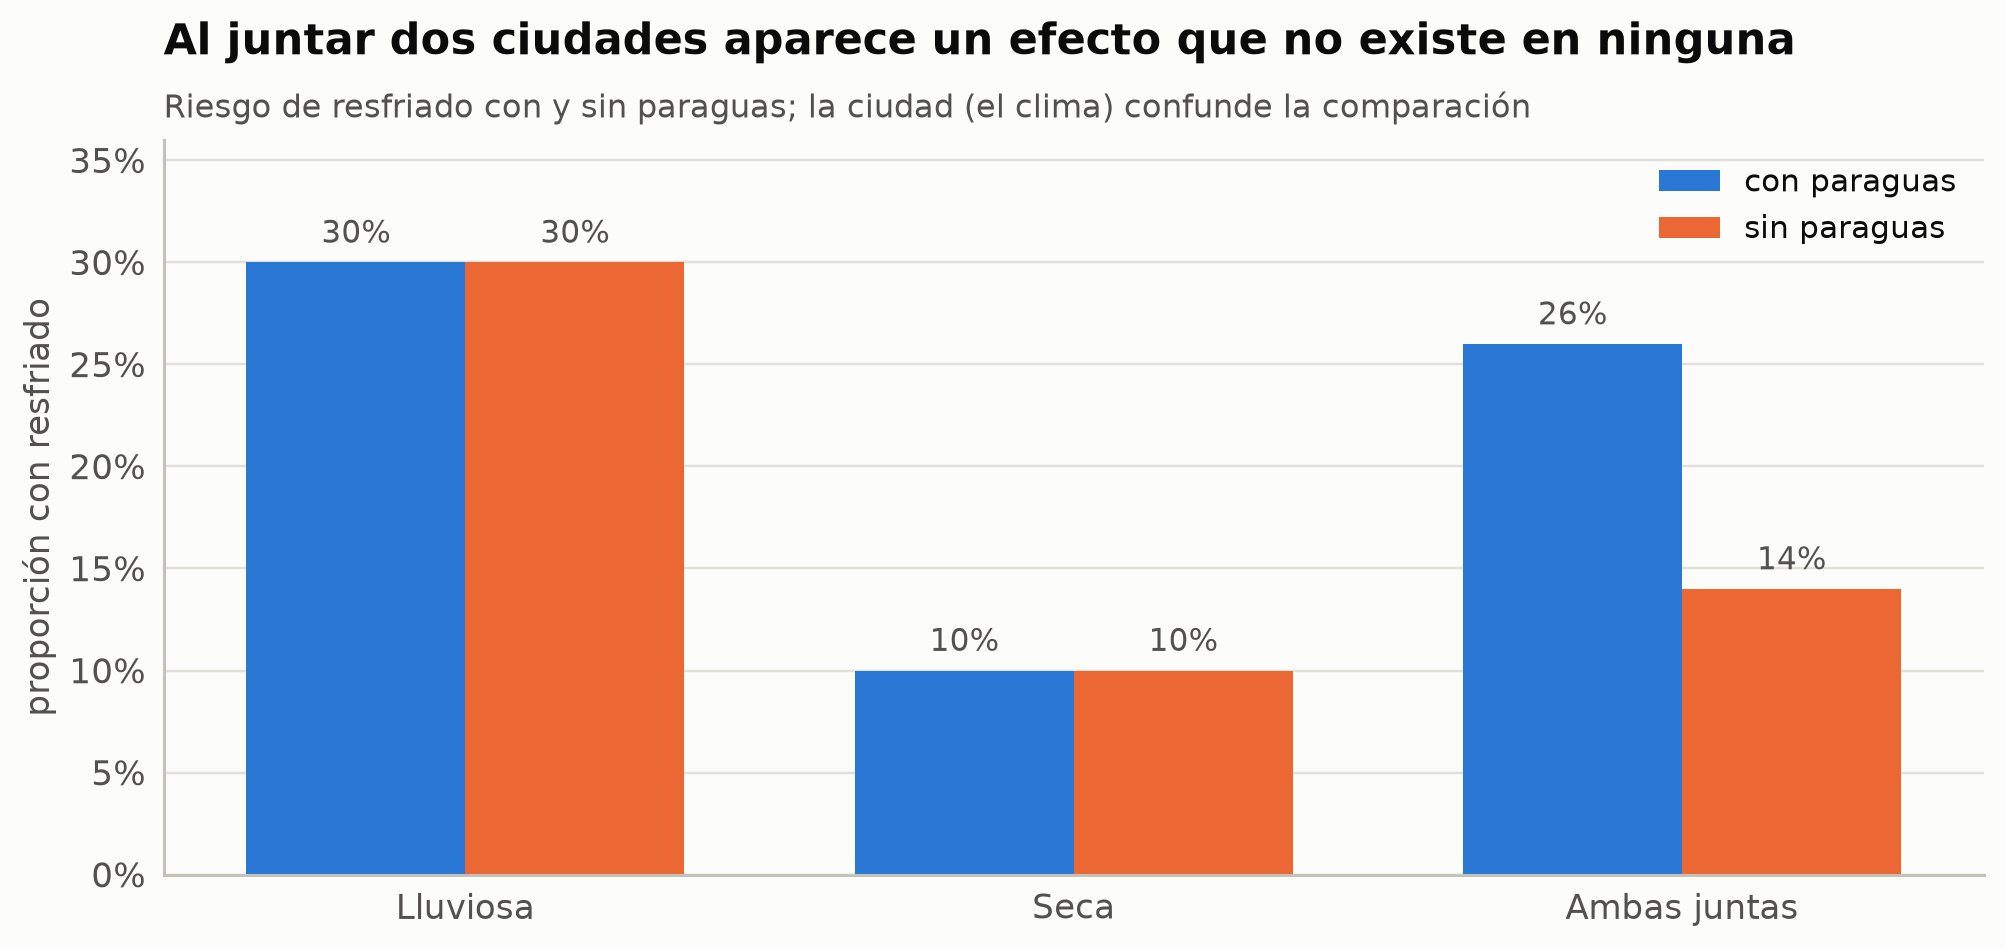

In [2]:
# Tablas 2x2 por ciudad: filas = paraguas (sí / no), columnas = resfriado (sí / no)
cities = {"lluviosa": np.array([[120, 280], [30, 70]]),
          "seca":     np.array([[10, 90],  [40, 360]])}

def odds_ratio(t):
    return (t[0, 0] * t[1, 1]) / (t[0, 1] * t[1, 0])

pooled = sum(cities.values())
for name, t in cities.items():
    print(f"Ciudad {name:9s}: OR = {odds_ratio(t):.2f}")
print(f"Ambas juntas     : OR = {odds_ratio(pooled):.2f}   ← asociación espuria")
# Mantel-Haenszel: combina los estratos sin mezclar sus poblaciones
num = sum(t[0, 0] * t[1, 1] / t.sum() for t in cities.values())
den = sum(t[0, 1] * t[1, 0] / t.sum() for t in cities.values())
print(f"Mantel-Haenszel  : OR = {num / den:.2f}   ← comparación dentro de cada ciudad")

fig, ax = plt.subplots(figsize=(9, 4.2))
groups = ["Lluviosa", "Seca", "Ambas juntas"]
risk_with = [120 / 400, 10 / 100, 130 / 500]
risk_without = [30 / 100, 40 / 400, 70 / 500]
x = np.arange(3); w = 0.36
b1 = ax.bar(x - w / 2, risk_with, w, color=ec.BLUE, label="con paraguas")
b2 = ax.bar(x + w / 2, risk_without, w, color=ec.ORANGE, label="sin paraguas")
for bars in (b1, b2):
    for r in bars:
        ax.text(r.get_x() + r.get_width() / 2, r.get_height() + 0.006, f"{r.get_height():.0%}",
                ha="center", va="bottom", fontsize=10, color=ec.INK_2)
ax.set_xticks(x, groups); ax.set_ylabel("proporción con resfriado"); ax.set_ylim(0, 0.36)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.legend(loc="upper right", frameon=False)
ec.title(ax, "Al juntar dos ciudades aparece un efecto que no existe en ninguna",
         "Riesgo de resfriado con y sin paraguas; la ciudad (el clima) confunde la comparación")
plt.show()

> 🔎 **Qué observamos.** En cada ciudad las dos barras son iguales (OR = 1), y Mantel-Haenszel lo confirma: OR = 1,00.
> Sólo al mezclar las ciudades aparece la diferencia 26 % frente a 14 %, porque los que llevan paraguas son sobre todo
> de la ciudad lluviosa, que es la más fría. En genética la "ciudad" es la población de origen, y el "paraguas" es
> cualquier alelo cuya frecuencia difiera entre poblaciones.

> ✅ **Compruebe su comprensión.** ¿Qué dos condiciones deben cumplirse a la vez para que la ciudad produzca una
> asociación espuria? (Pista: si el riesgo de resfriado fuera igual en las dos ciudades, ¿habría confusión?)

## 2. La idea y el diseño de un GWAS

Un **estudio de asociación del genoma completo** (GWAS, *genome-wide association study*) prueba, **una a una**, cientos
de miles o millones de variantes para detectar las que difieren en frecuencia entre casos y controles, o que se
correlacionan con un rasgo cuantitativo. No necesita familias ni una hipótesis previa sobre qué genes intervienen: se
apoya en que, gracias al **desequilibrio de ligamiento** (Lección 10.2), una variante genotipada "etiqueta" a sus vecinas
no genotipadas, incluida la causal. La premisa biológica es la hipótesis de **enfermedad común, variante común**: buena
parte del riesgo genético de las enfermedades frecuentes se debería a variantes frecuentes, cada una con un efecto
pequeño.

### Dos diseños

| | Casos y controles | Rasgo cuantitativo |
|---|---|---|
| Fenotipo $y_i$ | 1 = enfermo, 0 = sano | un número: estatura, glucosa, colesterol LDL |
| Modelo | regresión logística; efecto como $\mathrm{OR}_j=e^{\beta_j}$ | regresión lineal; $\beta_j$ en unidades del rasgo |
| Ejemplo práctico | diabetes tipo 2 en un hospital frente a donantes de sangre | estatura en un biobanco poblacional |
| Riesgo típico | casos y controles reclutados en lugares distintos (¡paraguas!) | el rasgo varía con la dieta, la edad o el centro de medición |
| Potencia | máxima con proporciones parecidas de casos y controles | depende de la varianza que explica la variante, $q^2$ |

### Una historia que abrió la era de los GWAS

En 2007, el **Wellcome Trust Case Control Consortium** (WTCCC) publicó un estudio con unos 2 000 casos de cada una de
siete enfermedades comunes (trastorno bipolar, enfermedad coronaria, enfermedad de Crohn, hipertensión, artritis
reumatoide y diabetes de tipos 1 y 2) y 3 000 controles compartidos, genotipados en unos 500 000 SNP. Encontró 24
señales de asociación independientes con $p<5\times10^{-7}$, muchas en genes nunca antes relacionados con esas
enfermedades. Tan importante como los hallazgos fue el **método**: el artículo estableció buena parte del control de
calidad, el análisis de estratificación y el uso de gráficos QQ que se volvieron estándar. Diez años después, los GWAS
habían identificado miles de loci asociados con cientos de rasgos (Visscher *et al.*, 2017).

### El flujo de trabajo

La figura siguiente reproduce las etapas del libro. Todas son importantes, pero **dos concentran la mayor parte de
los errores**: el control de la estructura poblacional y la corrección por comparaciones múltiples. A ellas dedicamos
casi toda la clase.

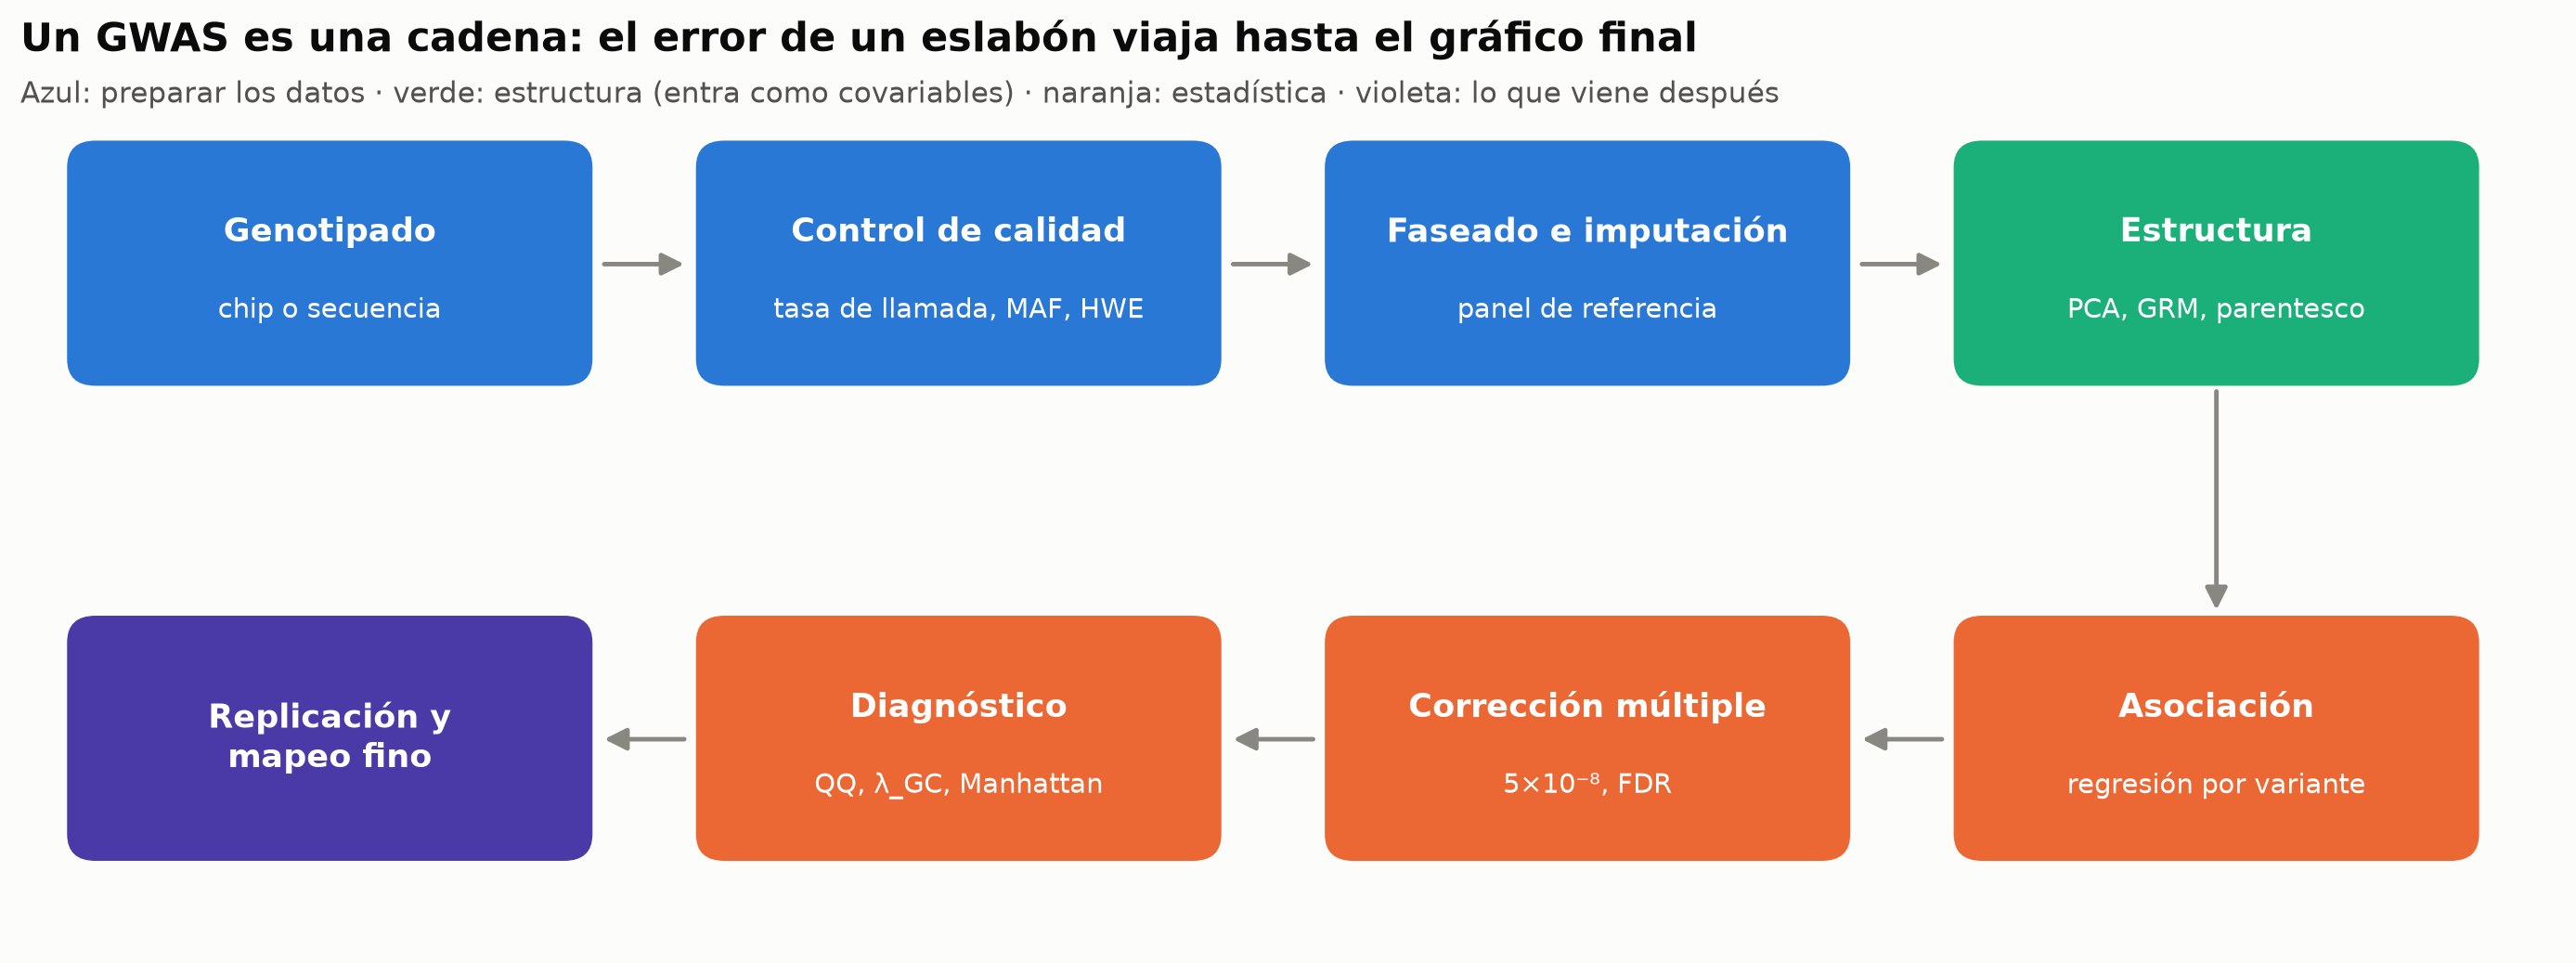

In [3]:
# Flujo de trabajo de un GWAS (misma disposición y colores que la figura del libro)
fig, ax = plt.subplots(figsize=(12.5, 4.6))
ax.set_xlim(0, 12.5); ax.set_ylim(0, 4.6); ax.axis("off"); ax.grid(False)
steps_top = [("Genotipado", "chip o secuencia", ec.BLUE), ("Control de calidad", "tasa de llamada, MAF, HWE", ec.BLUE),
             ("Faseado e imputación", "panel de referencia", ec.BLUE), ("Estructura", "PCA, GRM, parentesco", ec.AQUA)]
steps_bot = [("Replicación y\nmapeo fino", "", ec.VIOLET), ("Diagnóstico", "QQ, λ_GC, Manhattan", ec.ORANGE),
             ("Corrección múltiple", "5×10⁻⁸, FDR", ec.ORANGE), ("Asociación", "regresión por variante", ec.ORANGE)]
W, H, xs = 2.55, 1.25, [0.25 + i * 3.1 for i in range(4)]
def box(x, y, main, sub, color):
    ax.add_patch(FancyBboxPatch((x, y), W, H, boxstyle="round,pad=0.02,rounding_size=0.14", fc=color, ec="none"))
    ax.text(x + W / 2, y + H / 2 + (0.16 if sub else 0), main, ha="center", va="center", color="white",
            fontsize=11.5, fontweight="bold")
    if sub:
        ax.text(x + W / 2, y + H / 2 - 0.25, sub, ha="center", va="center", color="white", fontsize=9.5)
for x, (m, s, c) in zip(xs, steps_top):
    box(x, 2.95, m, s, c)
for x, (m, s, c) in zip(xs, steps_bot):
    box(x, 0.45, m, s, c)
arrow = dict(arrowstyle="-|>", color=ec.MUTED, lw=1.6, mutation_scale=16)
for i in range(3):
    ax.annotate("", xy=(xs[i + 1] - 0.05, 3.57), xytext=(xs[i] + W + 0.05, 3.57), arrowprops=arrow)
    ax.annotate("", xy=(xs[i] + W + 0.05, 1.07), xytext=(xs[i + 1] - 0.05, 1.07), arrowprops=arrow)
ax.annotate("", xy=(xs[3] + W / 2, 1.72), xytext=(xs[3] + W / 2, 2.93), arrowprops=arrow)
ax.set_title("Un GWAS es una cadena: el error de un eslabón viaja hasta el gráfico final", loc="left", pad=6)
ax.text(0, 4.42, "Azul: preparar los datos · verde: estructura (entra como covariables) · naranja: estadística · "
        "violeta: lo que viene después", transform=ax.transData, fontsize=10, color=ec.INK_2)
plt.show()

> 🔎 **Qué observamos.** El **control de calidad** (azul) elimina individuos y variantes con muchos datos faltantes,
> frecuencias muy bajas o desviaciones extremas de Hardy-Weinberg (Lección 10.1); lo veremos en acción con datos reales
> en la sección 5. La **imputación** aprovecha el LD con un panel de referencia (Lección 10.2) para pasar de cientos de
> miles a decenas de millones de variantes. La **estructura** (verde) no es un resultado: es un insumo que entra en el
> modelo. Y todo hallazgo debe **replicarse** en una muestra independiente (violeta): la variante más significativa rara
> vez es la causal.

## 3. El modelo aditivo

### La intuición: cada copia suma un escalón

Imagine una escalera con tres peldaños: 0, 1 o 2 copias del **alelo de efecto** en la variante $j$. El modelo aditivo
dice que **cada copia sube el rasgo la misma cantidad**, $\beta_j$: del peldaño 0 al 1 se sube lo mismo que del 1 al 2.
Estimar $\beta_j$ es entonces ajustar una recta a las medias del rasgo en los tres grupos de genotipo.

### Resuelto a mano: seis personas y su estatura

| Persona | 1 | 2 | 3 | 4 | 5 | 6 |
|---|---|---|---|---|---|---|
| copias $g_{ij}$ | 0 | 0 | 1 | 1 | 2 | 2 |
| estatura $y_i$ (cm) | 160 | 164 | 165 | 169 | 170 | 174 |

Las medias son $\bar g = 1$ y $\bar y = 167$. La pendiente de mínimos cuadrados es la covarianza dividida por la
varianza del genotipo:

$$
\hat\beta_j=\frac{\sum_i (g_{ij}-\bar g)(y_i-\bar y)}{\sum_i (g_{ij}-\bar g)^2}
=\frac{(-1)(-7)+(-1)(-3)+0+0+(1)(3)+(1)(7)}{1+1+0+0+1+1}=\frac{20}{4}=5\ \text{cm por copia}.
$$

### Las ecuaciones del libro

Para cada variante $j$ se ajusta un modelo de regresión en el que el genotipo entra como el número de copias del
alelo de efecto, $g_{ij}\in\{0,1,2\}$ (o su dosis imputada, un número real entre 0 y 2). Para un **rasgo cuantitativo**,

$$
y_i = \alpha + \beta_j\, g_{ij} + \boldsymbol\gamma^{\top}\mathbf{c}_i + \varepsilon_i,\qquad
\varepsilon_i\sim\mathcal N(0,\sigma^2),
$$

y para una **enfermedad** (caso/control), la regresión logística

$$
\log\frac{P(y_i=1)}{1-P(y_i=1)} = \alpha + \beta_j\, g_{ij} + \boldsymbol\gamma^{\top}\mathbf{c}_i ,
\qquad \mathrm{OR}_j=e^{\beta_j}.
$$

La hipótesis nula es $\beta_j=0$, y se contrasta con el estadístico de Wald $z_j=\hat\beta_j/\widehat{\mathrm{se}}(\hat\beta_j)$,
que bajo la nula es aproximadamente normal estándar (o, equivalentemente, $z_j^2\sim\chi^2_1$).

| Símbolo | Significado |
|---|---|
| $y_i$ | fenotipo del individuo $i$: un valor continuo o un indicador de enfermedad (1 = caso) |
| $g_{ij}$ | número de copias del alelo de efecto en la variante $j$ |
| $\beta_j$ | efecto aditivo: cambio en el rasgo (o en el logaritmo de las probabilidades) por cada copia adicional |
| $\mathbf{c}_i,\ \boldsymbol\gamma$ | covariables (sexo, edad, componentes principales) y sus coeficientes |
| $\mathrm{OR}_j$ | razón de probabilidades (*odds ratio*) por copia del alelo |
| $z_j$ | estadístico de Wald; $z_j^2\sim\chi^2_1$ bajo la nula |

Comprobemos el ejemplo a mano con la función `gwas_lineal` del libro (que acepta muchas variantes a la vez, aquí sólo
una):

In [4]:
g_hand = np.array([0, 0, 1, 1, 2, 2], float)
y_hand = np.array([160, 164, 165, 169, 170, 174], float)
b_hand, p_hand = gwas_lineal(y_hand, g_hand[:, None])
print(f"beta_j estimado = {b_hand[0]:.2f} cm por copia   |   p = {p_hand[0]:.4f}")
print("Medias por genotipo:", {k: y_hand[g_hand == k].mean() for k in (0, 1, 2)})

beta_j estimado = 5.00 cm por copia   |   p = 0.0151
Medias por genotipo: {0: np.float64(162.0), 1: np.float64(167.0), 2: np.float64(172.0)}


> 🔎 **Qué observamos.** $\hat\beta_j=5$ cm, como a mano, y las medias por genotipo (162, 167, 172) están exactamente
> en una recta. Con sólo seis personas el valor $p$ es pequeño porque el ejemplo es "de juguete": el ruido es mínimo.
> En la vida real el efecto de una variante sobre la estatura es de **milímetros**, y el ruido de centímetros.

### ¿Por qué aditivo, si hay alelos dominantes y recesivos?

Porque es el modelo con **un solo grado de libertad** que mejor potencia tiene frente a una amplia gama de modelos
verdaderos: una variante dominante o recesiva sigue produciendo una **tendencia monótona** en la media de los tres
genotipos, que la regresión lineal detecta. La alternativa, la prueba "genotípica" que compara las tres medias sin
suponer nada (2 grados de libertad), gasta un grado de libertad extra y paga por ello.

> 🤔 **Antes de ejecutar, prediga.** Si la variante verdadera es **recesiva** (sólo las personas con 2 copias cambian),
> ¿qué prueba ganará: la aditiva (1 g.l.) o la genotípica (2 g.l.)? ¿Y si es dominante?

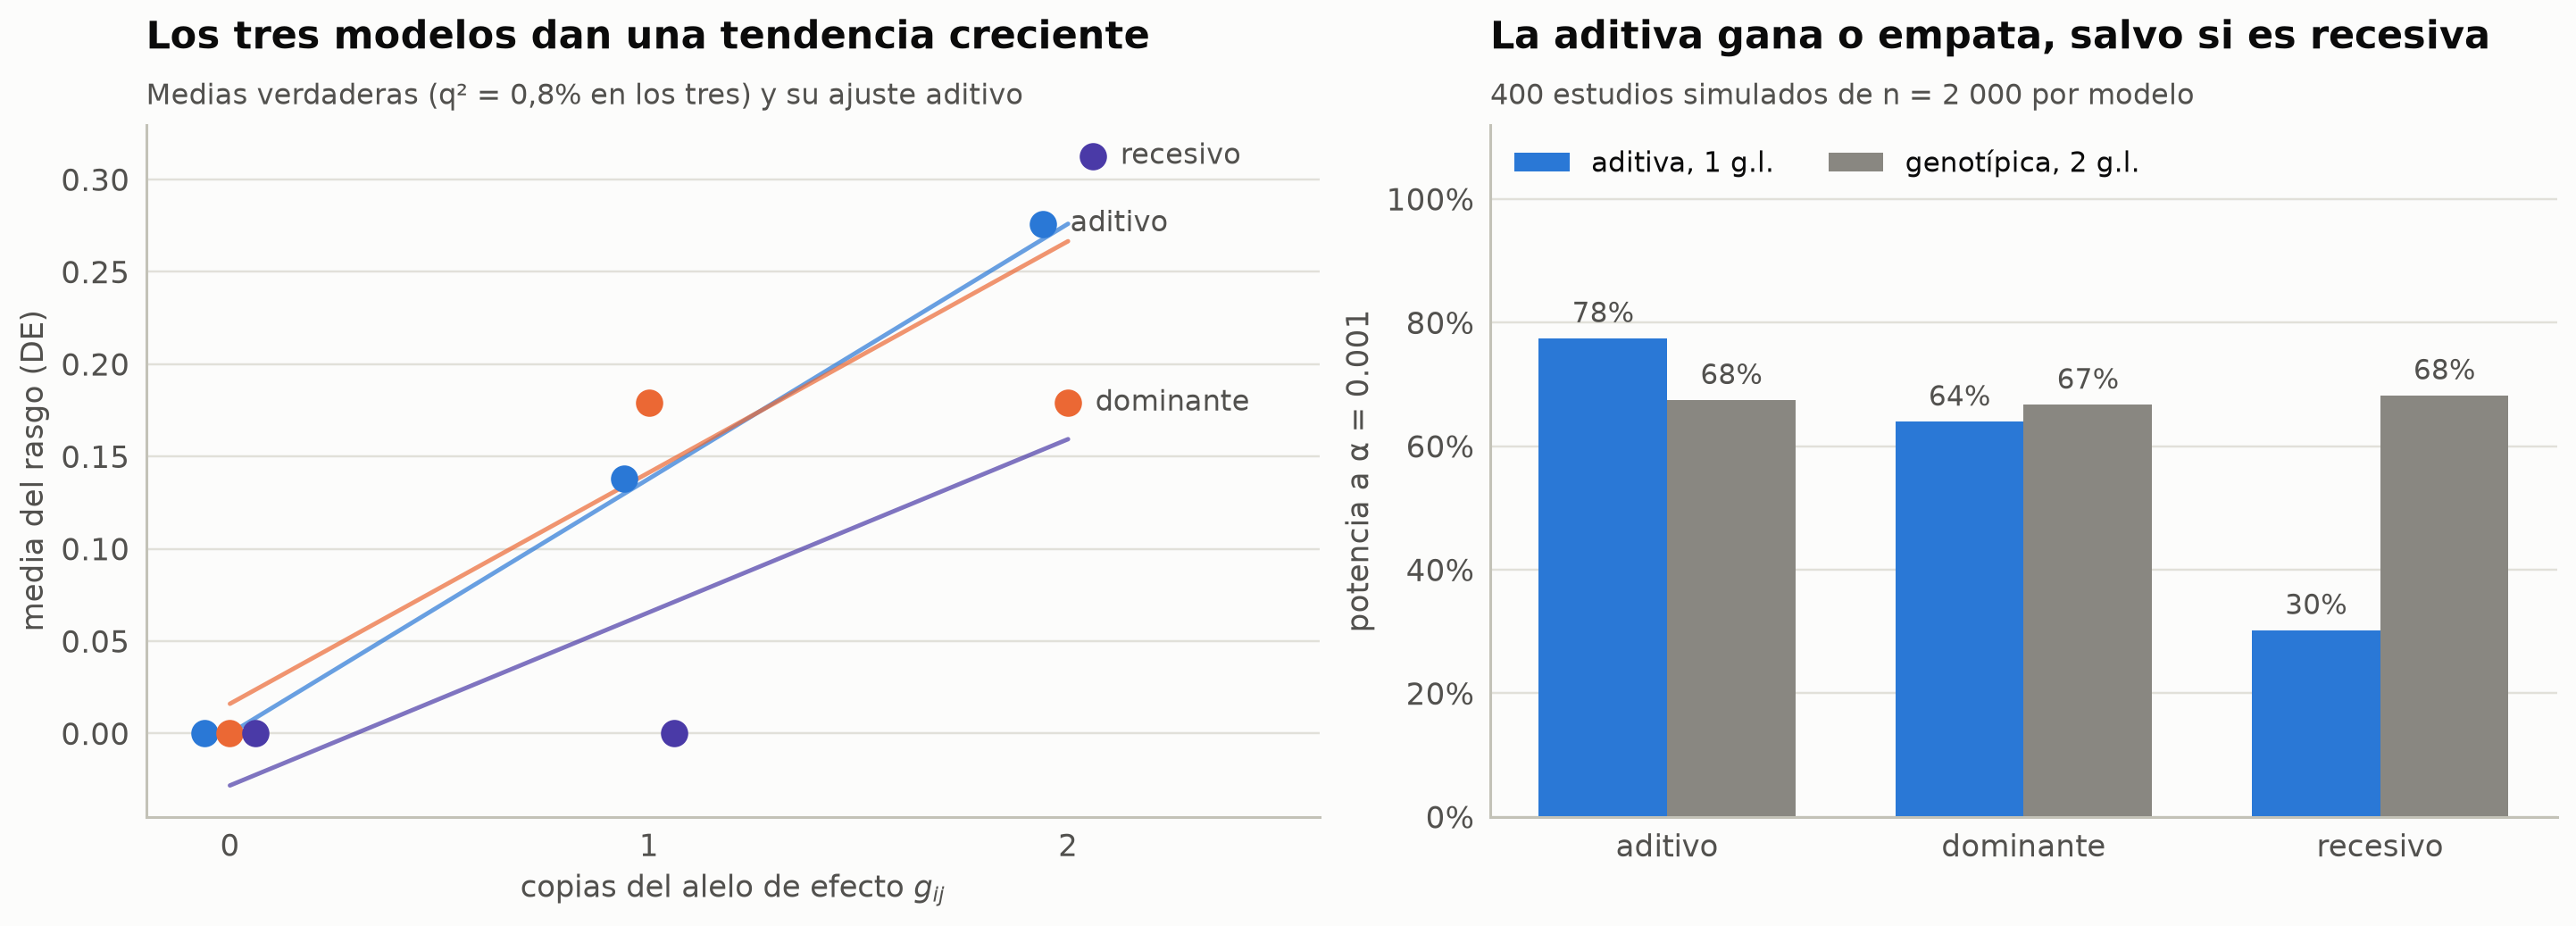

In [5]:
# Simulación: 400 estudios de n = 2 000 con una variante de p = 0,3 bajo tres modelos verdaderos
rng = np.random.default_rng(103)
n_sim, reps, p_sim, alpha_sim, q2_sim = 2000, 400, 0.3, 1e-3, 0.008
models = {"aditivo": [0, 1, 2], "dominante": [0, 1, 1], "recesivo": [0, 0, 1]}
hwe_w = np.array([(1 - p_sim) ** 2, 2 * p_sim * (1 - p_sim), p_sim ** 2])
def scaled_means(codes):
    """Medias por genotipo escaladas para que los tres modelos expliquen la MISMA varianza q² (comparación justa)."""
    c = np.array(codes, float)
    var_c = hwe_w @ c ** 2 - (hwe_w @ c) ** 2
    return c * math.sqrt(q2_sim / var_c)
g = rng.binomial(2, p_sim, size=(reps, n_sim)).astype(float)
eps = rng.normal(size=(reps, n_sim))
power = {}
for name, codes in models.items():
    y = scaled_means(codes)[g.astype(int)] + eps
    # prueba aditiva (1 g.l.): correlación genotipo-rasgo → t de Student
    gc, yc = g - g.mean(1, keepdims=True), y - y.mean(1, keepdims=True)
    r = (gc * yc).sum(1) / np.sqrt((gc ** 2).sum(1) * (yc ** 2).sum(1))
    t = r * np.sqrt((n_sim - 2) / (1 - r ** 2))
    p_add = 2 * stats.t.sf(np.abs(t), n_sim - 2)
    # prueba genotípica (2 g.l.): ANOVA de una vía con los tres grupos
    p_gen = np.array([stats.f_oneway(*[y[i][g[i] == k] for k in (0, 1, 2)]).pvalue for i in range(reps)])
    power[name] = ((p_add < alpha_sim).mean(), (p_gen < alpha_sim).mean())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [1.1, 1]})
ax = axes[0]
for (name, codes), col, dx in zip(models.items(), [ec.BLUE, ec.ORANGE, ec.VIOLET], [-0.06, 0, 0.06]):
    means = scaled_means(codes)
    ax.plot(np.arange(3) + dx, means, "o", color=col, ms=9, zorder=3)
    # recta aditiva que mejor ajusta las tres medias (ponderadas por las frecuencias de HWE)
    slope, icpt = np.polyfit([0, 1, 2], means, 1, w=np.sqrt(hwe_w))
    ax.plot([0, 2], [icpt, icpt + 2 * slope], color=col, lw=1.6, alpha=0.7)
    ax.annotate(name, (2 + dx, means[2]), xytext=(10, 0), textcoords="offset points", va="center",
                fontsize=10.5, color=ec.INK_2)
ax.set_xticks([0, 1, 2]); ax.set_xlabel("copias del alelo de efecto $g_{ij}$"); ax.set_xlim(-0.2, 2.6)
ax.set_ylabel("media del rasgo (DE)")
ec.title(ax, "Los tres modelos dan una tendencia creciente",
         f"Medias verdaderas (q² = {q2_sim:.1%} en los tres) y su ajuste aditivo".replace(".", ","))
ax = axes[1]
xx = np.arange(3); wbar = 0.36
pa = [power[m][0] for m in models]; pg = [power[m][1] for m in models]
b1 = ax.bar(xx - wbar / 2, pa, wbar, color=ec.BLUE, label="aditiva, 1 g.l.")
b2 = ax.bar(xx + wbar / 2, pg, wbar, color=ec.MUTED, label="genotípica, 2 g.l.")
for bars in (b1, b2):
    for rct in bars:
        ax.text(rct.get_x() + rct.get_width() / 2, rct.get_height() + 0.015, f"{rct.get_height():.0%}",
                ha="center", va="bottom", fontsize=10, color=ec.INK_2)
ax.set_xticks(xx, list(models)); ax.set_ylim(0, 1.12); ax.set_ylabel(f"potencia a α = {alpha_sim:g}")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.legend(loc="upper left", frameon=False, ncol=2)
ec.title(ax, "La aditiva gana o empata, salvo si es recesiva", f"{reps} estudios simulados de n = {n_sim:,} por modelo".replace(",", " "))
plt.show()

> 🔎 **Qué observamos.** Con la misma varianza explicada en los tres modelos, la prueba de 1 grado de libertad gana
> con claridad bajo el modelo aditivo y prácticamente empata bajo el dominante. Bajo el recesivo, con un alelo de frecuencia 0,3, la recta ajusta mal tres medias
> con forma de "palo de hockey" y la prueba genotípica la supera: el precio de suponer un modelo. Como casi nunca sabemos de antemano el modelo verdadero, el aditivo es el
> mejor compromiso, y por eso es el que usan PLINK, REGENIE o BOLT-LMM por omisión.

### Casos y controles: la prueba de tendencia de Armitage

Cuando $y_i$ vale 0 o 1, la regresión logística es el modelo natural. Antes de que existieran computadoras rápidas se
usaba una prueba equivalente que sólo necesita una tabla de $2\times3$: la **prueba de tendencia de Cochran-Armitage**
(Armitage, 1955). Con los genotipos codificados como 0, 1 y 2, su estadístico es, en una forma muy útil,

$$
T_{\mathrm{CA}} = N\, r^2_{g,y}\ \sim\ \chi^2_1 \text{ bajo la nula},
$$

donde $r_{g,y}$ es la correlación de Pearson entre el número de copias y el indicador de caso. Es la **prueba de
puntuación** (*score test*) de la misma regresión logística aditiva: en muestras grandes coincide con $z_j^2$ de Wald.

| Símbolo | Significado |
|---|---|
| $N$ | número total de personas (casos + controles) |
| $r_{g,y}$ | correlación entre $g_{ij}$ y $y_i\in\{0,1\}$ |
| $T_{\mathrm{CA}}$ | estadístico de tendencia; se compara con $\chi^2_1$ |

**Resuelto a mano.** Un estudio de diabetes tipo 2 con 1 000 casos y 1 000 controles da:

| | $g=0$ | $g=1$ | $g=2$ | total |
|---|---|---|---|---|
| casos | 360 | 480 | 160 | 1 000 |
| controles | 490 | 420 | 90 | 1 000 |

Con $N=2000$: $\bar y = 0{,}5$; la suma de copias es $800$ en casos y $600$ en controles, así que $\bar g=0{,}7$;
$\operatorname{cov}(g,y)=800/2000-0{,}7\cdot0{,}5=0{,}05$; $\operatorname{var}(g)=1900/2000-0{,}7^2=0{,}46$ y
$\operatorname{var}(y)=0{,}25$. Entonces $r^2=0{,}05^2/(0{,}46\cdot0{,}25)=0{,}0217$ y $T_{\mathrm{CA}}=2000\cdot0{,}0217\approx43{,}5$.

In [6]:
# Tabla 2x3 → datos individuales
cases, controls = np.array([360, 480, 160]), np.array([490, 420, 90])
g_cc = np.r_[np.repeat([0, 1, 2], cases), np.repeat([0, 1, 2], controls)].astype(float)
y_cc = np.r_[np.ones(cases.sum()), np.zeros(controls.sum())]
N = len(y_cc)
r = np.corrcoef(g_cc, y_cc)[0, 1]
T_ca = N * r ** 2
print(f"Armitage: r² = {r**2:.5f}   T_CA = {T_ca:.2f}   p = {stats.chi2.sf(T_ca, 1):.2e}")

def logistic_wald(y, g, iters=25):
    """Regresión logística y ~ 1 + g por Newton-Raphson (IRLS); devuelve beta, se y z de Wald."""
    X = np.column_stack([np.ones_like(g), g]); b = np.zeros(2)
    for _ in range(iters):
        mu = 1 / (1 + np.exp(-X @ b))
        H = X.T @ (X * (mu * (1 - mu))[:, None])            # información de Fisher
        b = b + np.linalg.solve(H, X.T @ (y - mu))
    se = np.sqrt(np.diag(np.linalg.inv(H)))
    return b[1], se[1], b[1] / se[1]

beta_l, se_l, z_l = logistic_wald(y_cc, g_cc)
print(f"Logística: beta = {beta_l:.4f}  OR por copia = {np.exp(beta_l):.3f}  "
      f"IC95 % = [{np.exp(beta_l - 1.96 * se_l):.3f}, {np.exp(beta_l + 1.96 * se_l):.3f}]")
print(f"           z² de Wald = {z_l**2:.2f}   p = {stats.chi2.sf(z_l**2, 1):.2e}")

Armitage: r² = 0.02174   T_CA = 43.48   p = 4.29e-11
Logística: beta = 0.4418  OR por copia = 1.556  IC95 % = [1.363, 1.776]
           z² de Wald = 42.79   p = 6.11e-11


> 🔎 **Qué observamos.** La prueba de tendencia ($T_{\mathrm{CA}}\approx43{,}5$) y el $z^2$ de Wald de la regresión
> logística dan casi el mismo número y valores $p$ del mismo orden: son dos caras del mismo modelo aditivo. La
> logística, además, nos da el **tamaño del efecto**: cada copia multiplica las probabilidades de diabetes por el OR
> impreso arriba. Su ventaja práctica es que admite **covariables** (edad, sexo, componentes principales), algo que la
> tabla de $2\times3$ no puede hacer.

> ✅ **Compruebe su comprensión.** Si duplicamos todos los recuentos de la tabla (2 000 casos y 2 000 controles con
> las mismas proporciones), ¿qué le pasa a $r^2$? ¿Y a $T_{\mathrm{CA}}$?

### Cuánta varianza explica una variante y cuántas personas hacen falta

La varianza del rasgo explicada por una variante aditiva tiene una forma sencilla:

$$
q^2_j = \frac{2p_j(1-p_j)\,\beta_j^2}{\sigma_y^2}, \qquad \mathbb{E}[z_j^2]\approx 1 + \frac{n\,q_j^2}{1-q_j^2}.
$$

| Símbolo | Significado |
|---|---|
| $q_j^2$ | fracción de la varianza fenotípica explicada por la variante $j$ |
| $2p_j(1-p_j)$ | varianza del genotipo bajo HWE; las variantes raras explican poca varianza aunque su efecto sea grande |
| $\sigma_y^2$ | varianza total del rasgo |
| $n$ | tamaño de muestra |
| $n q^2/(1-q^2)$ | parámetro de no centralidad del $\chi^2_1$: determina la potencia |

**El ejemplo del libro.** Una variante con $p=0{,}3$ que desplaza el rasgo $0{,}05$ desviaciones estándar por copia
explica $q^2=2\cdot0{,}3\cdot0{,}7\cdot0{,}05^2=0{,}00105$, apenas **una milésima** de la varianza. Con un umbral
$\alpha=5\times10^{-8}$ ($\chi^2_1>29{,}7$), para detectarla con 80 % de potencia hacen falta unos **40 000**
individuos; si explicara la mitad de eso, unos **79 000**.

> 🤔 **Antes de ejecutar, prediga.** Con $q^2=0{,}1\,\%$, ¿qué potencia tendrá un estudio de 10 000 personas? ¿Un
> 20 %, un 50 %…? Y con 50 000?

In [7]:
thr_chi = stats.chi2.isf(GW, 1)
print(f"Umbral χ²₁ para p = 5e-8: {thr_chi:.2f}")
for pp, b in ((0.3, 0.05), (0.1, 0.1)):
    print(f"p = {pp}, beta = {b} DE  →  q² = 2p(1-p)β² = {2 * pp * (1 - pp) * b * b:.5f}")

def power_gw(n, q2, alpha=GW):
    """Potencia de la prueba χ²₁ con no centralidad n q²/(1-q²)."""
    return stats.ncx2.sf(stats.chi2.isf(alpha, 1), 1, n * q2 / (1 - q2))

for n, q2 in ((10_000, 0.001), (50_000, 0.001), (100_000, 0.0005), (500_000, 0.0005)):
    print(f"n = {n:>7,}  q² = {q2:<6}  NCP = {n * q2 / (1 - q2):6.1f}  potencia = {power_gw(n, q2):.3f}")
for q2 in (0.0005, 0.001):                       # n para 80 % de potencia (bisección en escala log)
    lo, hi = 1e3, 1e7
    for _ in range(80):
        mid = math.sqrt(lo * hi)
        lo, hi = (mid, hi) if power_gw(mid, q2) < 0.8 else (lo, mid)
    print(f"n para 80 % de potencia con q² = {q2}: {hi:,.0f}")

Umbral χ²₁ para p = 5e-8: 29.72
p = 0.3, beta = 0.05 DE  →  q² = 2p(1-p)β² = 0.00105
p = 0.1, beta = 0.1 DE  →  q² = 2p(1-p)β² = 0.00180
n =  10,000  q² = 0.001   NCP =   10.0  potencia = 0.011
n =  50,000  q² = 0.001   NCP =   50.1  potencia = 0.948
n = 100,000  q² = 0.0005  NCP =   50.0  potencia = 0.948
n = 500,000  q² = 0.0005  NCP =  250.1  potencia = 1.000
n para 80 % de potencia con q² = 0.0005: 79,162
n para 80 % de potencia con q² = 0.001: 39,561


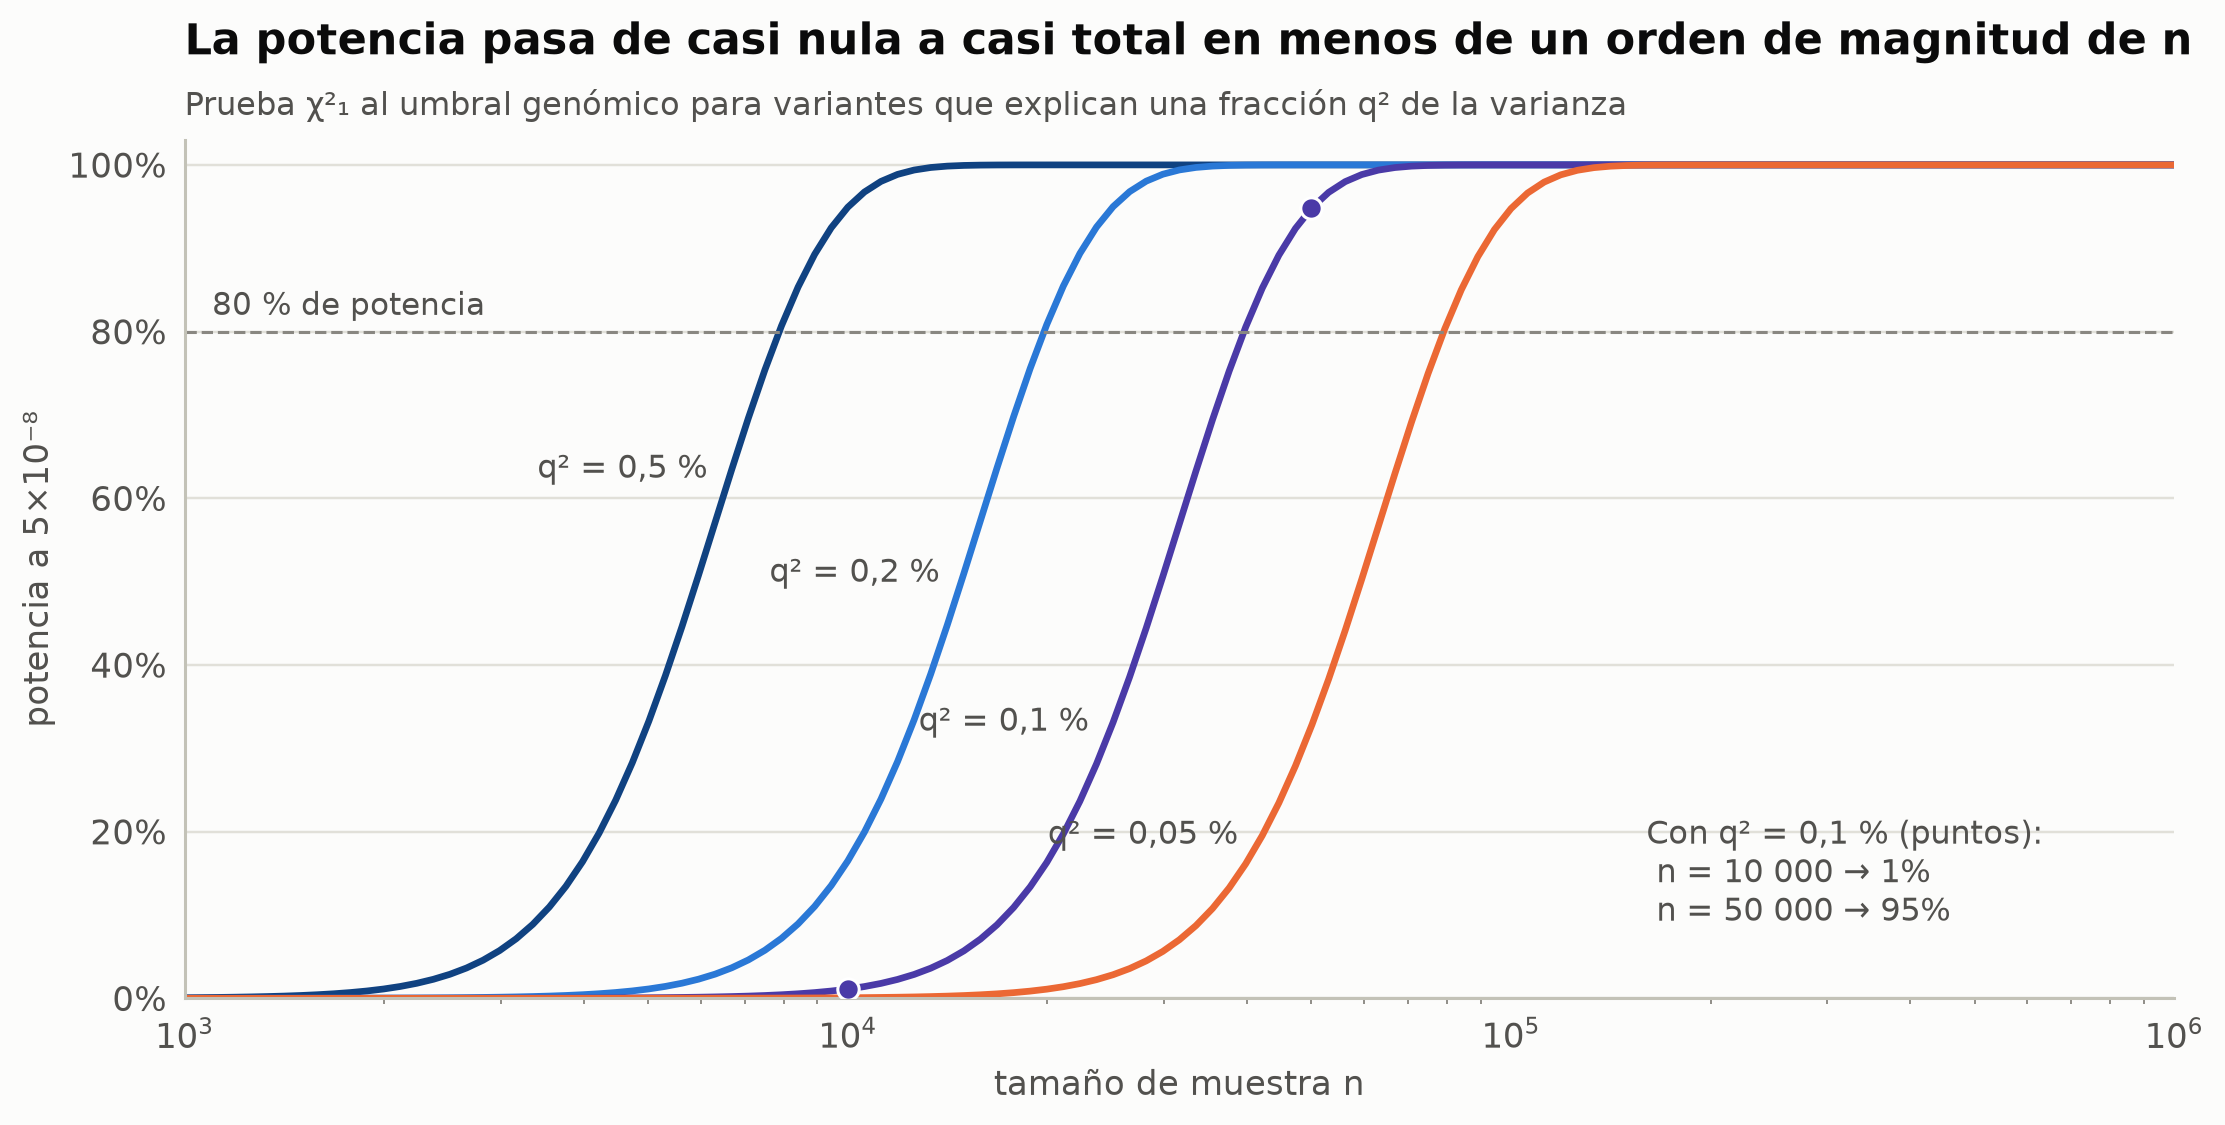

In [8]:
# La figura de potencia del libro (fig. 10-bh b)
nn = np.logspace(3, 6, 121)
fig, ax = plt.subplots(figsize=(10, 5))
curves = [(0.005, "#104281"), (0.002, ec.BLUE), (0.001, ec.VIOLET), (0.0005, ec.ORANGE)]
for (q2, col), lev in zip(curves, (0.62, 0.47, 0.32, 0.17)):
    pw = power_gw(nn, q2)
    ax.plot(nn, pw, color=col, lw=2.2)
    i = np.searchsorted(pw, lev)
    ax.annotate(f"q² = {q2 * 100:g} %".replace(".", ","), (nn[i], pw[i]), xytext=(-8, 0),
                textcoords="offset points", ha="right", va="center", fontsize=10.5, color=ec.INK_2)
ax.axhline(0.8, color=ec.MUTED, ls="--", lw=1)
ax.text(1.1e3, 0.82, "80 % de potencia", color=ec.INK_2, fontsize=10)
for n, q2 in ((10_000, 0.001), (50_000, 0.001)):
    ax.plot(n, power_gw(n, q2), "o", color=ec.VIOLET, ms=7, mec="white", zorder=4)
ax.text(1.6e5, 0.08, f"Con q² = 0,1 % (puntos):\n n = 10 000 → {power_gw(1e4, 0.001):.0%}\n"
        f" n = 50 000 → {power_gw(5e4, 0.001):.0%}", fontsize=10.5, color=ec.INK_2, va="bottom")
ax.set_xscale("log"); ax.set_xlim(1e3, 1e6); ax.set_ylim(0, 1.03)
ax.set_xlabel("tamaño de muestra n"); ax.set_ylabel("potencia a 5×10⁻⁸")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ec.title(ax, "La potencia pasa de casi nula a casi total en menos de un orden de magnitud de n",
         "Prueba χ²₁ al umbral genómico para variantes que explican una fracción q² de la varianza")
plt.show()

> 🔎 **Qué observamos.** Con $q^2=0{,}1\,\%$ la potencia es del **1 %** con 10 000 personas y del **95 %** con
> 50 000: la curva es un escalón. Por eso los GWAS de estatura o de diabetes pasaron de decenas de loci a cientos o
> miles cuando las muestras crecieron de decenas de miles a cientos de miles de personas. Y por eso un estudio pequeño
> que "no encuentra nada" no demuestra que no haya nada: simplemente estaba en la parte plana de la curva.

> ✅ **Compruebe su comprensión.** Una variante rara ($p=0{,}01$) con un efecto grande ($\beta=0{,}3$ DE por copia),
> ¿explica más o menos varianza que la variante común del ejemplo del libro? Calcule $q^2$.

## 4. Estratificación poblacional

Volvamos a los paraguas. Suponga que la muestra mezcla **dos poblaciones** con frecuencias alélicas distintas en muchas
variantes, y que el rasgo también difiere en promedio entre ellas, por razones genéticas o ambientales. Entonces
**toda** variante diferenciada entre las poblaciones mostrará una asociación con el rasgo, aunque no tenga ningún
efecto. Este sesgo, la **estratificación poblacional**, no afecta a unas pocas variantes sino a todo el genoma, y deja
una huella característica: **infla la distribución completa** de los estadísticos de prueba.

### Control genómico: medir la inflación con la mediana

Devlin y Roeder (1999) propusieron medir esa inflación con la **mediana**. Bajo la nula, $z^2\sim\chi^2_1$, cuya mediana
es $0{,}4549$. Si la estratificación multiplica todos los estadísticos por un factor aproximadamente constante,

$$
\hat\lambda_{GC} = \frac{\operatorname{mediana}(z_1^2,\dots,z_M^2)}{0{,}4549},\qquad \tilde z_j^2 = \frac{z_j^2}{\hat\lambda_{GC}},
$$

y dividir por $\hat\lambda_{GC}$ restaura la calibración.

| Símbolo | Significado |
|---|---|
| $M$ | número de variantes probadas |
| $z_j^2$ | estadístico $\chi^2_1$ de la variante $j$ |
| $0{,}4549$ | mediana teórica de una $\chi^2_1$ (el valor que tendría la mediana si no hubiera ninguna inflación) |
| $\hat\lambda_{GC}$ | factor de inflación genómica; $\approx1$ en un estudio bien controlado |
| $\tilde z_j^2$ | estadístico corregido por control genómico |

La mediana es **robusta**: las pocas variantes verdaderamente asociadas apenas la mueven. Un $\lambda_{GC}$ cercano a 1
indica un estudio bien controlado. Salvedad importante: en rasgos muy poligénicos con muestras enormes, miles de
variantes causales de efecto diminuto inflan **legítimamente** la mediana, y un $\lambda_{GC}$ de 1,1 o más no implica
necesariamente confusión.

**Resuelto a mano.** Nueve variantes dan, ordenados, $z^2 = 0{,}02;\ 0{,}15;\ 0{,}31;\ 0{,}52;\ \mathbf{0{,}83};\ 0{,}97;\
1{,}40;\ 2{,}10;\ 5{,}60$. La mediana es el quinto valor, $0{,}83$, así que $\hat\lambda_{GC}=0{,}83/0{,}4549\approx1{,}82$:
la mitad de los estadísticos está por encima de lo que la nula permite. Observe que cambiar el último valor por 560
no movería la mediana: por eso las señales reales no "contaminan" $\hat\lambda_{GC}$.

In [9]:
z2_hand = np.array([0.02, 0.15, 0.31, 0.52, 0.83, 0.97, 1.40, 2.10, 5.60])
print(f"mediana teórica de χ²₁ = {stats.chi2.ppf(0.5, 1):.4f}")
print(f"λ_GC = {np.median(z2_hand):.2f} / 0.4549 = {np.median(z2_hand) / stats.chi2.ppf(0.5, 1):.2f}")
z2_hand[-1] = 560
print(f"con el último valor = 560: λ_GC = {np.median(z2_hand) / stats.chi2.ppf(0.5, 1):.2f}  (no cambia)")

mediana teórica de χ²₁ = 0.4549
λ_GC = 0.83 / 0.4549 = 1.82
con el último valor = 560: λ_GC = 1.82  (no cambia)


### Componentes principales: corregir a cada variante según su propia diferenciación

La corrección por $\lambda_{GC}$ es **uniforme**, pero la estratificación no lo es: afecta más a las variantes **más
diferenciadas** entre poblaciones. Price *et al.* (2006) propusieron EIGENSTRAT: calcular los ejes principales de
variación genética (la PCA de la Lección 10.2) y eliminar de genotipos y fenotipos la parte explicada por ellos, lo que
equivale a incluir los primeros componentes como covariables $\mathbf{c}_i$ en el modelo lineal. Así, cada variante se
corrige en proporción a su propia diferenciación.

La función `gwas_lineal` del libro hace exactamente eso con el teorema de **Frisch-Waugh-Lovell**: el coeficiente de un
SNP en una regresión con covariables es igual al de la regresión simple entre los residuos del SNP y del fenotipo,
después de proyectar ambos fuera del espacio de las covariables. Así se prueban todas las variantes con dos productos de
matrices, sin un bucle.

### Ejemplo del libro: «Una asociación espuria y su corrección»

Simulamos 2 000 individuos de dos poblaciones (1 000 de cada una, $F_{ST}\approx0{,}02$, modelo de Balding-Nichols) y
10 000 SNP, con 10 variantes causales de efecto pequeño y un rasgo que, además, es **0,3 desviaciones estándar más
alto en la segunda población**. El libro obtuvo: $\hat\lambda_{GC}=1{,}86$ sin corregir, con **148** variantes por
debajo de $p<10^{-3}$ (cuando por azar se esperarían 10 más unas pocas causales); el primer componente correlaciona en
$0{,}997$ con la población, y con dos componentes como covariables, $\hat\lambda_{GC}=0{,}98$ y quedan **18** variantes
con $p<10^{-3}$.

Todas las figuras simuladas del capítulo 10 del libro salen de **un único generador aleatorio** (semilla 1908) que se
usa en orden a lo largo del capítulo. Para obtener exactamente las mismas cifras sin rehacer todo el capítulo,
guardamos en `data/103_rng_libro.json` el **estado** de ese generador justo antes de cada simulación de esta sección.

> 🤔 **Antes de ejecutar, prediga.** Si la inflación viene sólo de la diferencia de medias entre poblaciones, ¿cuántos
> componentes principales deberían bastar para eliminarla?

In [10]:
RNG_BOOK = json.load(open(course_file("103_rng_libro.json")))
def book_rng(section):
    """Generador en el mismo estado que el del libro al empezar esa simulación."""
    r = np.random.default_rng()
    r.bit_generator.state = RNG_BOOK[section]
    return r

def balding_nichols(pa, F, r):
    """Frecuencias de una población derivada de un ancestro con frecuencia pa (Balding-Nichols)."""
    a = pa * (1 - F) / F
    b = (1 - pa) * (1 - F) / F
    return r.beta(a, b)

t0 = time.time()
rng_b = book_rng("estratificacion")
n1 = n2 = 1000
Mg = 10000
pa = rng_b.uniform(0.05, 0.95, Mg)
p1, p2 = balding_nichols(pa, 0.02, rng_b), balding_nichols(pa, 0.02, rng_b)
G_sim = np.vstack([rng_b.binomial(2, p1, (n1, Mg)), rng_b.binomial(2, p2, (n2, Mg))]).astype(float)
pop_sim = np.r_[np.zeros(n1), np.ones(n2)]
causal_sim = rng_b.choice(Mg, 10, replace=False)
beta_sim = rng_b.normal(0, 0.12, 10)
Gc_causal = G_sim[:, causal_sim] - G_sim[:, causal_sim].mean(0)
y_sim = Gc_causal @ beta_sim + 0.3 * pop_sim + rng_b.normal(0, 1, n1 + n2)

# 1) regresión ingenua (sin covariables)
_, p_naive_sim = gwas_lineal(y_sim, G_sim)
# 2) dos componentes principales como covariables. Los autovectores de Z Zᵀ (2 000 x 2 000) son los
#    mismos que los vectores singulares izquierdos de Z, pero se calculan mucho más rápido.
Zs = (G_sim - G_sim.mean(0)) / (G_sim.std(0) + 1e-12)
evals, evecs = np.linalg.eigh(Zs @ Zs.T)
U_sim = evecs[:, ::-1][:, :10]                          # de mayor a menor autovalor
del Zs
_, p_pc_sim = gwas_lineal(y_sim, G_sim, U_sim[:, :2])

res = pd.DataFrame({
    "cifra": ["λ_GC ingenuo", "λ_GC con 2 PCs", "p < 1e-3 ingenuo", "p < 1e-3 con 2 PCs",
              "p < 5e-8 ingenuo (causales)", "p < 5e-8 con 2 PCs (causales)", "|corr(PC1, población)|"],
    "obtenido": [f"{lambda_gc(p_naive_sim):.3f}", f"{lambda_gc(p_pc_sim):.3f}",
                 int((p_naive_sim < 1e-3).sum()), int((p_pc_sim < 1e-3).sum()),
                 f"{(p_naive_sim < GW).sum()} ({(p_naive_sim[causal_sim] < GW).sum()})",
                 f"{(p_pc_sim < GW).sum()} ({(p_pc_sim[causal_sim] < GW).sum()})",
                 f"{abs(np.corrcoef(U_sim[:, 0], pop_sim)[0, 1]):.3f}"],
    "libro": ["1.862", "0.983", 148, 18, "3 (3)", "2 (2)", "0.997"]})
display(res.set_index("cifra"))
print(f"({time.time() - t0:.1f} s)")

,obtenido,libro
cifra,,
λ_GC ingenuo,1.862,1.862
λ_GC con 2 PCs,0.982,0.983
p < 1e-3 ingenuo,148,148
p < 1e-3 con 2 PCs,18,18
p < 5e-8 ingenuo (causales),3 (3),3 (3)
p < 5e-8 con 2 PCs (causales),2 (2),2 (2)
"|corr(PC1, población)|",0.997,0.997


(1.7 s)


> 🔎 **Qué observamos.** Las cifras coinciden con las del libro. La única diferencia, una milésima en $\hat\lambda_{GC}$
> con PCs, se debe a los grados de libertad: el script que generó las cifras del libro usó $n-2$ tras residualizar, y
> `gwas_lineal`, como el listado del libro, usa $n-k-1$. (Si ejecuta el notebook con otra versión mayor de NumPy, alguna cifra
> podría diferir un poco: los algoritmos de muestreo pueden cambiar entre versiones.) Sin corregir, la mediana de
> los $z^2$ está un 86 % por encima de lo esperado y hay unas 15 veces más variantes con $p<10^{-3}$ de las que el azar
> explica. Dos componentes bastan porque sólo hay dos poblaciones: el primer componente **es** la población
> (correlación 0,997), y el segundo absorbe un poco de estructura residual.

### El gráfico QQ: la radiografía de la inflación

Un **gráfico cuantil-cuantil** (QQ) compara el $k$-ésimo valor $p$ más pequeño observado con el esperado bajo la
hipótesis nula global, $(k-0{,}5)/M$, ambos en escala $-\log_{10}$. Si todas las variantes fueran nulas, los puntos
caerían sobre la diagonal. La **banda gris** es el intervalo del 95 % de cada estadístico de orden bajo la nula: el
$k$-ésimo menor de $M$ valores uniformes sigue una distribución $\mathrm{Beta}(k,\,M-k+1)$.

| Símbolo | Significado |
|---|---|
| $p_{(k)}$ | $k$-ésimo valor $p$ más pequeño |
| $(k-0{,}5)/M$ | valor esperado (aproximado) de $p_{(k)}$ bajo la nula |
| $\mathrm{Beta}(k,M-k+1)$ | distribución exacta de $p_{(k)}$ bajo la nula; sus cuantiles 2,5 % y 97,5 % dan la banda |

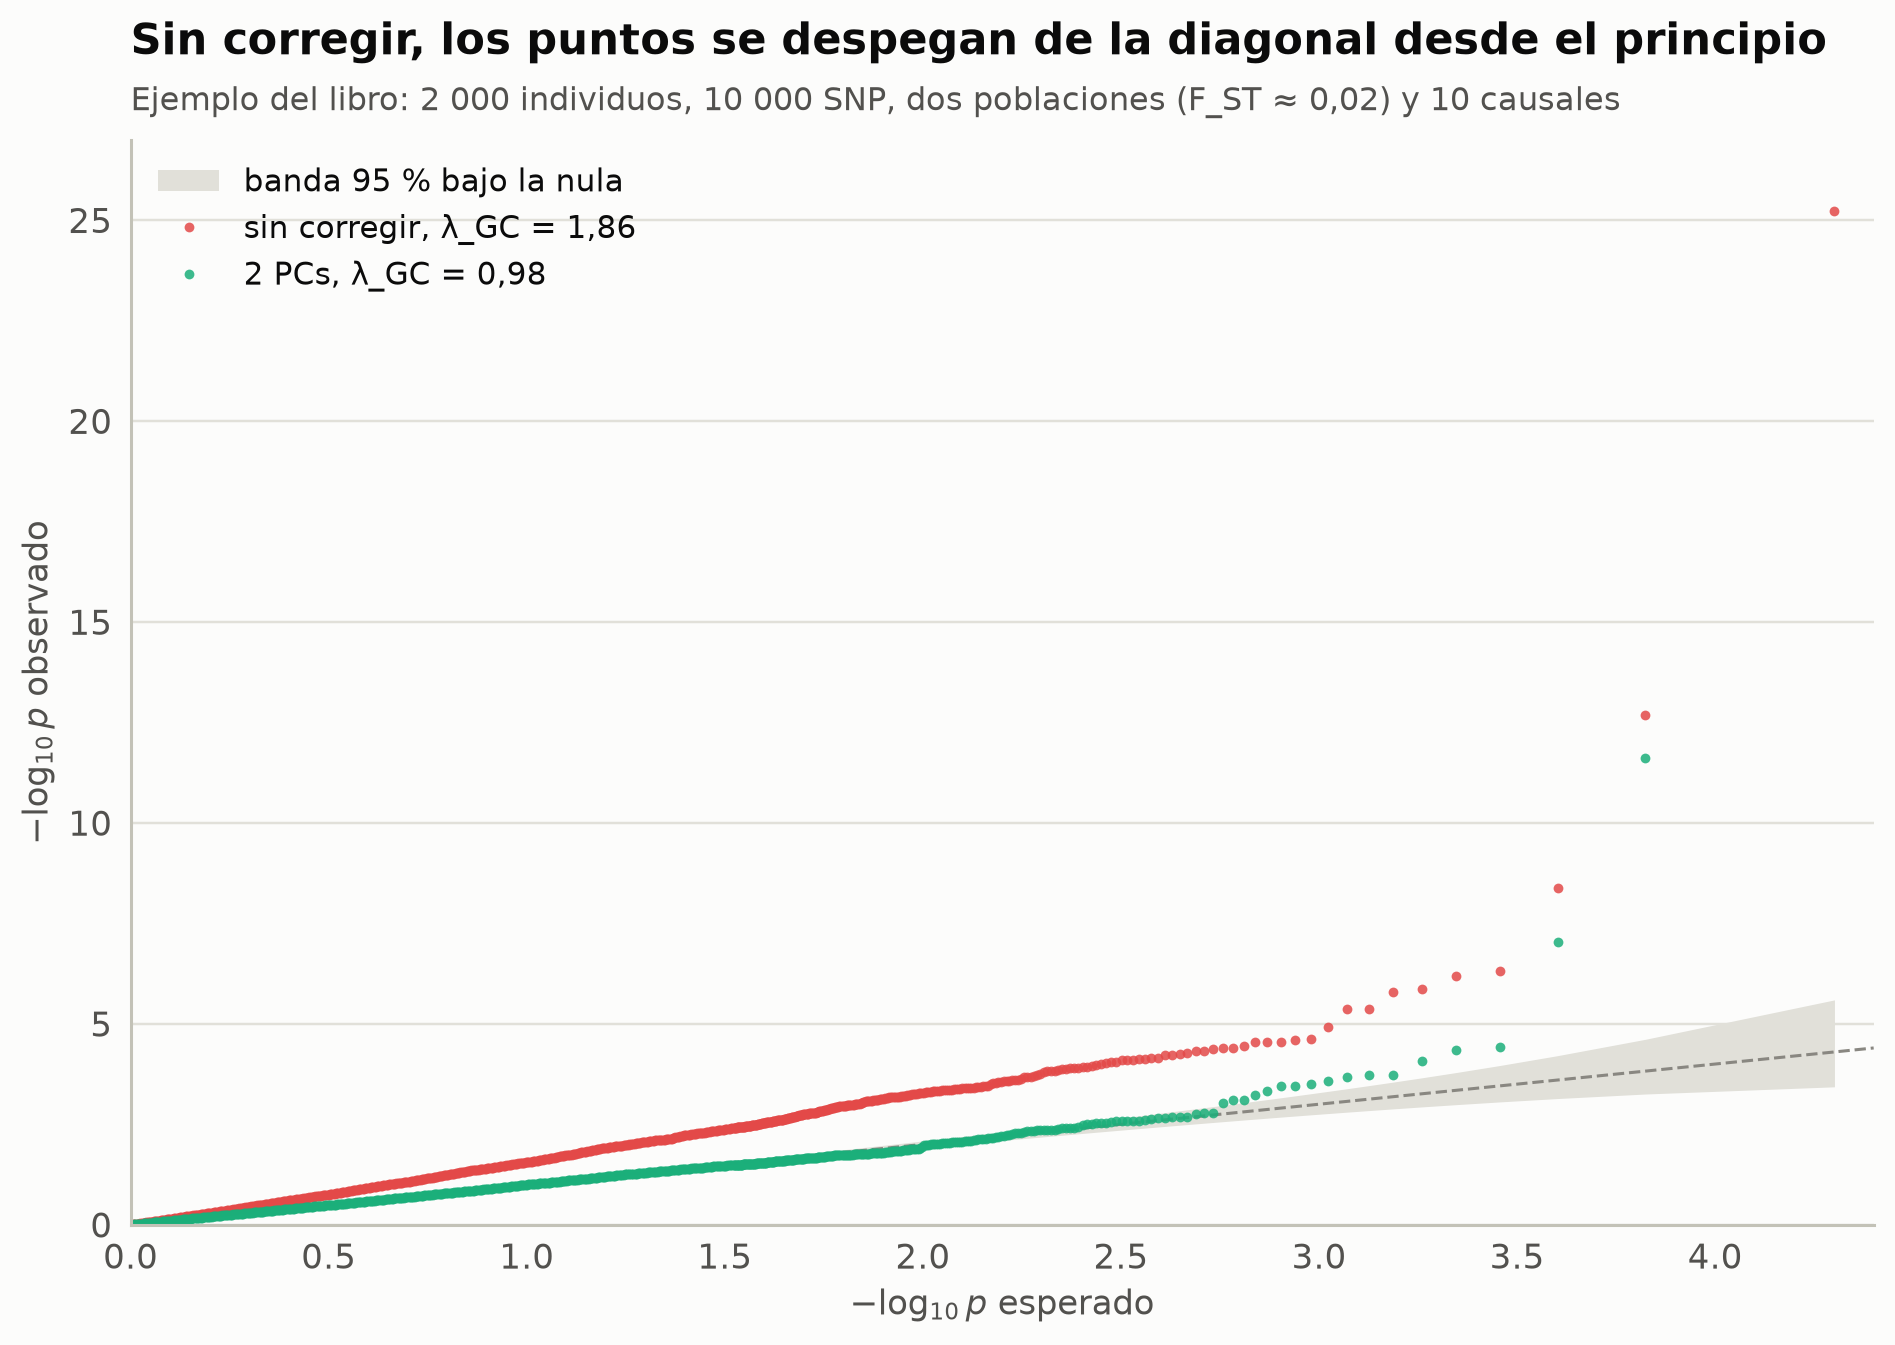

In [11]:
def qq_rows(pv, keep_top=300, n_rest=500):
    """Puntos del QQ (esperado, observado) en -log10: toda la cola y una submuestra del resto (como el libro)."""
    pv = np.sort(pv)
    m = len(pv)
    e = -np.log10((np.arange(1, m + 1) - 0.5) / m)
    o = -np.log10(np.maximum(pv, 1e-300))
    idx = list(range(min(keep_top, m)))
    rest = np.unique(np.round(np.geomspace(keep_top + 1, m, n_rest)).astype(int) - 1)
    idx = sorted(set(idx) | set(rest.tolist()))
    return e[idx], o[idx]

def qq_band(m, npts=120):
    """Banda del 95 % de los estadísticos de orden bajo la nula (distribución Beta)."""
    ks = np.unique(np.round(np.geomspace(1, m, npts)).astype(int))
    lo = stats.beta.ppf(0.025, ks, m - ks + 1)
    hi = stats.beta.ppf(0.975, ks, m - ks + 1)
    return -np.log10((ks - 0.5) / m), -np.log10(hi), -np.log10(lo)

def draw_qq(ax, series, m, xmax=None, ymax=None):
    e_b, lo_b, hi_b = qq_band(m)
    ax.fill_between(e_b, lo_b, hi_b, color=ec.GRID, lw=0, label="banda 95 % bajo la nula")
    top = xmax or e_b.max() * 1.05
    ax.plot([0, top], [0, top], color=ec.MUTED, ls="--", lw=1)
    for pv, col, lab in series:
        e, o = qq_rows(pv)
        ax.plot(e, o, "o", ms=3.2, color=col, alpha=0.85, mec="none", label=lab)
    ax.set_xlim(0, top); ax.set_ylim(0, ymax)
    ax.set_xlabel("$-\\log_{10} p$ esperado"); ax.set_ylabel("$-\\log_{10} p$ observado")
    ax.legend(loc="upper left", frameon=False)

fig, ax = plt.subplots(figsize=(8.5, 6))
draw_qq(ax, [(p_naive_sim, ec.RED, f"sin corregir, λ_GC = {lambda_gc(p_naive_sim):.2f}".replace(".", ",")),
             (p_pc_sim, ec.AQUA, f"2 PCs, λ_GC = {lambda_gc(p_pc_sim):.2f}".replace(".", ","))], Mg, xmax=4.4, ymax=27)
ec.title(ax, "Sin corregir, los puntos se despegan de la diagonal desde el principio",
         "Ejemplo del libro: 2 000 individuos, 10 000 SNP, dos poblaciones (F_ST ≈ 0,02) y 10 causales")
plt.show()

> 🔎 **Qué observamos.** Sin corrección (rojo), los puntos se separan de la diagonal **desde el principio**, síntoma de
> inflación de *todo* el genoma. Con dos componentes principales (verde), la nube vuelve a la banda y sólo se despega en
> la cola, donde están las causales. En esta simulación modesta, las variantes que superan $5\times10^{-8}$ son causales
> en ambos análisis: la inflación se concentra en la **zona intermedia** de valores $p$. Pero la inflación crece con el
> tamaño de muestra (la no centralidad espuria es proporcional a $n$), y en un estudio diez veces mayor esas mismas
> diferencias de frecuencia producirían **rascacielos falsos** en el gráfico Manhattan. En la sección siguiente lo
> veremos con genomas reales.

> ✅ **Compruebe su comprensión.** Un QQ cuyos puntos siguen la diagonal hasta $-\log_{10}p\approx3$ y luego se
> disparan hacia arriba, ¿indica estratificación o señales reales? ¿Y uno que se separa desde $-\log_{10}p\approx0{,}5$?

### Modelos lineales mixtos (para saber más)

Los componentes principales capturan bien la estructura a gran escala, pero no el **parentesco críptico** (primos
lejanos en la muestra) ni la estructura fina. Los modelos mixtos modelan toda la similitud genética a la vez:

$$
\mathbf{y} = X\boldsymbol\gamma + \mathbf{g}_j\beta_j + \mathbf{u} + \boldsymbol\varepsilon,\qquad
\mathbf{u}\sim\mathcal N\!\left(\mathbf 0,\ \sigma_g^2\,\Psi\right),\quad
\boldsymbol\varepsilon\sim\mathcal N\!\left(\mathbf 0,\ \sigma_e^2 I\right).
$$

| Símbolo | Significado |
|---|---|
| $\mathbf{u}$ | efecto genético poligénico aleatorio: la suma de los efectos de todas las demás variantes |
| $\Psi$ | matriz de parentesco genómico (GRM) de la Lección 10.2: individuos más emparentados tienen efectos $\mathbf u$ más correlacionados |
| $\sigma_g^2,\ \sigma_e^2$ | varianzas genética y residual; $\sigma_g^2/(\sigma_g^2+\sigma_e^2)$ es la heredabilidad atribuible a los SNP |

Yang *et al.* (2011) popularizaron, con GCTA, la estimación por REML de la varianza que **todos los SNP** explican
conjuntamente (la heredabilidad SNP). Ajustar este modelo para millones de variantes era prohibitivo (el coste crece con
el cubo del número de individuos) hasta que Loh *et al.* (2015) desarrollaron BOLT-LMM, que evita construir y
factorizar $\Psi$ y aumenta la potencia en cohortes grandes.

## 5. 🧪 Caso real: una falsa asociación con la lactasa en 2 504 genomas

### La historia: la lactasa "hace crecer"

En 2005, Campbell *et al.* estudiaron la estatura en estadounidenses de ascendencia europea y encontraron una
asociación fuerte con una variante del gen de la **lactasa** (*LCT*). Parecía una historia biológica atractiva: la
persistencia de la lactasa permite a los adultos digerir la leche, y la leche aporta calcio y proteína. Pero la
asociación era **espuria**. El alelo de persistencia, la variante −13910 C>T (rs4988235, descrita por Enattah *et al.*,
2002, y sometida a una selección positiva muy fuerte y reciente según Bersaglieri *et al.*, 2004), es mucho más
frecuente en el norte de Europa que en el sur; y la estatura media **también** sigue un gradiente norte-sur. Al tener en
cuenta el origen europeo de los participantes, la asociación desaparecía. Es la encuesta de los paraguas con genes: la
"ciudad" era la región de Europa de la que venían los abuelos.

### Nuestro experimento

Reproduciremos el **mecanismo** con genotipos **reales** del Proyecto 1000 Genomas (fase 3; 2 504 personas de 26
poblaciones agrupadas en 5 superpoblaciones: AFR, AMR, EAS, EUR y SAS):

* `1000G_chr22_thinned_genotypes.npz`: 3 292 SNP del cromosoma 22 (MAF ≥ 5 %, espaciados ≥ 10 kb) que usaremos como
  "genoma" de fondo y para calcular los componentes principales;
* `1000G_chr2_LCT_136.3-136.9Mb.vcf.gz`: 907 SNP faseados de la región *LCT/MCM6* del cromosoma 2, incluida
  rs4988235, que en la hebra positiva del genoma de referencia (GRCh37) es **2:136608646 G>A** (el alelo A es el de
  persistencia, T en la hebra de *LCT*).

Sobre esos genotipos simularemos un rasgo (llamémoslo "estatura", en desviaciones estándar) con **dos** componentes:

1. una diferencia **no genética** de $d=0{,}6$ DE a favor de las personas de ascendencia europea (en la vida real,
   dieta, nivel socioeconómico o incluso el protocolo de medición de cada centro de reclutamiento);
2. **una** variante causal verdadera del cromosoma 22 que explica $q^2=2\,\%$ de la varianza.

Nada en la región de la lactasa afecta al rasgo. Si el GWAS encuentra algo ahí, es un paraguas.

La escala de nuestro experimento es continental porque 3 000 SNP de un solo cromosoma **no** alcanzan para ver la
estructura fina norte-sur dentro de Europa (volveremos a esto en el Ejercicio 4); el mecanismo, en cambio, es idéntico.

In [12]:
t0 = time.time()
npz = np.load(course_file("1000G_chr22_thinned_genotypes.npz"), allow_pickle=True)
samples = npz["samples"]
panel = (pd.read_csv(course_file("1000G_phase3_panel.tsv"), sep="\t", usecols=[0, 1, 2, 3])
         .set_index("sample").loc[samples])
G22_raw, pos22_raw = npz["genotypes"], npz["pos"]

# Región LCT: leemos el VCF a mano (GT fasado "a|b" → a + b copias del alelo ALT)
lct_pos, lct_ref, lct_alt, lct_rows = [], [], [], []
with gzip.open(course_file("1000G_chr2_LCT_136.3-136.9Mb.vcf.gz"), "rt") as fh:
    for line in fh:
        if line.startswith("##"):
            continue
        f = line.rstrip("\n").split("\t")
        if line.startswith("#CHROM"):
            vcf_samples = f[9:]
            continue
        lct_pos.append(int(f[1])); lct_ref.append(f[3]); lct_alt.append(f[4])
        lct_rows.append([int(s[0]) + int(s[2]) for s in f[9:]])
GL_raw = np.array(lct_rows, dtype=np.int8).T
lct_pos = np.array(lct_pos)
assert list(vcf_samples) == list(samples), "las muestras deben estar en el mismo orden"
pops, spop = panel["pop"].values, panel["super_pop"].values
print(f"{len(samples)} personas · chr22: {G22_raw.shape[1]} SNP · región LCT: {GL_raw.shape[1]} SNP "
      f"({time.time() - t0:.1f} s)")
print(panel["super_pop"].value_counts().to_dict())

2504 personas · chr22: 3292 SNP · región LCT: 907 SNP (0.4 s)
{'AFR': 661, 'EAS': 504, 'EUR': 503, 'SAS': 489, 'AMR': 347}


### Paso 1 · Control de calidad: Hardy-Weinberg dentro de cada población

El libro filtra con `--hwe 1e-6`: se descartan las variantes cuyo recuento de genotipos se aleja demasiado de
$p^2:2pq:q^2$. Pero **¿dentro de qué grupo?** Si probamos HWE en la muestra completa, o incluso dentro de una
superpoblación, el **efecto Wahlund** (Lección 10.1) nos hará descartar precisamente las variantes más diferenciadas:
¡la propia rs4988235 falla HWE en EUR porque mezcla británicos (74 % de A en CEU) e italianos (9 % en TSI)! Por eso
probamos HWE **dentro de cada una de las 26 poblaciones** y descartamos una variante si falla en alguna.

In [13]:
def hwe_min_p(G, groups):
    """Menor valor p de la prueba χ² de HWE (1 g.l.) entre los grupos, para cada columna de G."""
    min_p = np.ones(G.shape[1])
    for grp in np.unique(groups):
        g = G[groups == grp]; n = len(g)
        c = np.stack([(g == k).sum(0) for k in range(3)]).astype(float)
        p = (2 * c[2] + c[1]) / (2 * n)
        e = np.stack([n * (1 - p) ** 2, 2 * n * p * (1 - p), n * p ** 2])
        with np.errstate(divide="ignore", invalid="ignore"):
            x2 = np.nansum(np.where(e > 0, (c - e) ** 2 / e, np.nan), axis=0)
        pv = stats.chi2.sf(x2, 1)
        pv[(p == 0) | (p == 1)] = 1
        min_p = np.minimum(min_p, pv)
    return min_p

hwe22, hweL = hwe_min_p(G22_raw, pops), hwe_min_p(GL_raw, pops)
keep22, keepL = hwe22 > 1e-6, hweL > 1e-6
i_lct_raw = int(np.where(lct_pos == 136608646)[0][0])
print(f"chr22: descartamos {(~keep22).sum()} de {len(keep22)} SNP · región LCT: {(~keepL).sum()} de {len(keepL)}")
print(f"rs4988235: p HWE mínimo por población = {hweL[i_lct_raw]:.2g} (pasa) · "
      f"en EUR completo = {hwe_min_p(GL_raw[spop == 'EUR'][:, [i_lct_raw]], np.zeros((spop == 'EUR').sum()))[0]:.1g}")
worst = int(np.argmin(hwe22))
cnt = np.bincount(G22_raw[:, worst], minlength=3)
# cociente heterocigotos observados / esperados (bajo HWE global) de cada SNP
p_all = G22_raw.mean(0) / 2
het_ratio = (G22_raw == 1).mean(0) / (2 * p_all * (1 - p_all))
for lab, j in (("exceso", int(np.argmax(het_ratio))), ("déficit", int(np.argmin(het_ratio)))):
    cnt = np.bincount(G22_raw[:, j], minlength=3)
    print(f"Mayor {lab} de heterocigotos (chr22:{pos22_raw[j]:,}): genotipos 0/1/2 = {cnt.tolist()} · "
          f"obs/esp = {het_ratio[j]:.2f} · p HWE mínimo = {hwe22[j]:.0e}")

chr22: descartamos 180 de 3292 SNP · región LCT: 13 de 907
rs4988235: p HWE mínimo por población = 0.05 (pasa) · en EUR completo = 9e-09
Mayor exceso de heterocigotos (chr22:17,496,339): genotipos 0/1/2 = [110, 2382, 12] · obs/esp = 1.91 · p HWE mínimo = 3e-24
Mayor déficit de heterocigotos (chr22:21,836,429): genotipos 0/1/2 = [260, 40, 2204] · obs/esp = 0.08 · p HWE mínimo = 2e-24


> 🔎 **Qué observamos.** Unos 180 SNP del cromosoma 22 (el 5 %) fallan HWE en alguna población. Los dos extremos son
> elocuentes. Con **exceso** de heterocigotos, casi todas las personas son "heterocigotas" y casi nadie es homocigoto
> para el alelo alternativo, algo biológicamente imposible en 26 poblaciones a la vez: es la firma de un **paralog**, dos
> copias casi idénticas de la región que el genotipado confunde con dos alelos de un solo locus. Con **déficit**, casi no
> hay heterocigotos: la firma típica de una deleción polimórfica (un "alelo nulo" que hace pasar a los heterocigotos por
> homocigotos) o de un error sistemático de llamado. Un GWAS con esos SNP podría producir "asociaciones" puramente
> técnicas. En cambio,
> rs4988235 pasa el filtro por población aunque falle en EUR entero, porque su "exceso de homocigotos" en EUR es efecto
> Wahlund, no un error.

### Paso 2 · La estructura: PCA de los SNP del cromosoma 22

Usamos la función `pca_genotipos` del libro (Lección 10.2) **sólo** con los SNP del cromosoma 22. No incluimos la región
*LCT*: son cientos de SNP en LD fuerte que podrían "secuestrar" un componente (el recuadro «El PCA también ve el LD» del
libro), y además no queremos que la variante que vamos a probar defina la covariable que la corrige.

PCA de 2504 x 3112 en 3.0 s · primeros autovalores: [282.1, 114.0, 42.9, 37.0, 16.5, 15.4]


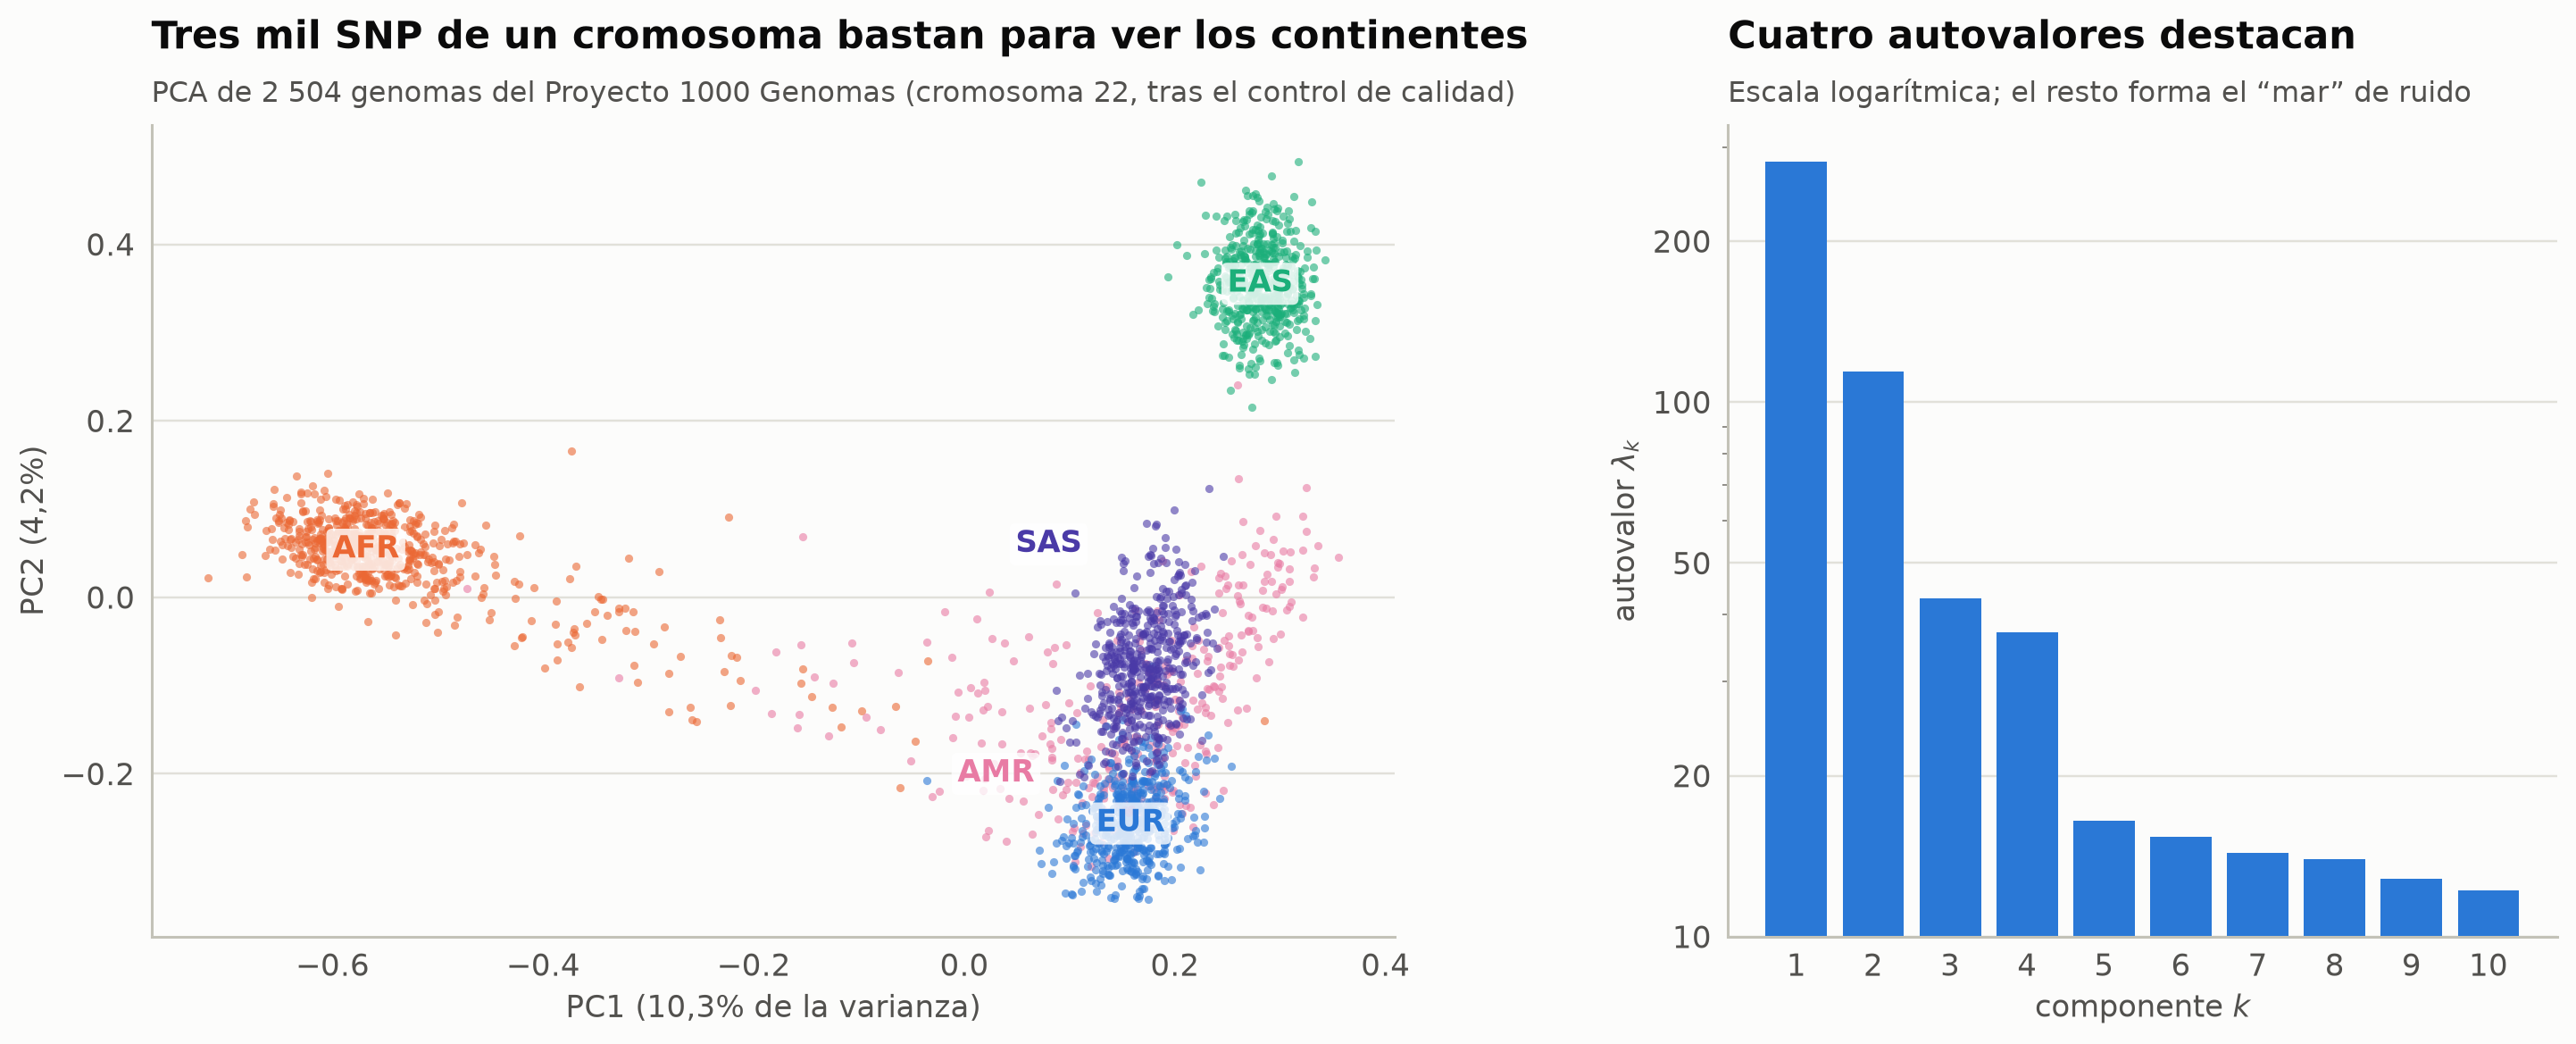

In [14]:
def pca_genotipos(G, k=10):
    """G: n x M con 0/1/2. Devuelve coordenadas y autovalores."""
    p = G.mean(axis=0) / 2
    ok = (p > 0.01) & (p < 0.99)          # descartar monomórficos
    Z = (G[:, ok] - 2 * p[ok]) / np.sqrt(2 * p[ok] * (1 - p[ok]))
    U, S, _ = np.linalg.svd(Z, full_matrices=False)
    lam = S ** 2 / Z.shape[1]                    # autovalores de Psi
    return U[:, :k] * np.sqrt(lam[:k]), lam

G22 = G22_raw[:, keep22].astype(float); pos22 = pos22_raw[keep22]
GL = GL_raw[:, keepL].astype(float); posL = lct_pos[keepL]
t0 = time.time()
PCs, lam_pca = pca_genotipos(G22, k=10)
print(f"PCA de {G22.shape[0]} x {G22.shape[1]} en {time.time() - t0:.1f} s · "
      f"primeros autovalores: {np.round(lam_pca[:6], 1).tolist()}")

SP_ORDER = ["AFR", "AMR", "EAS", "EUR", "SAS"]
SP_COL = dict(zip(SP_ORDER, [ec.ORANGE, ec.MAGENTA, ec.AQUA, ec.BLUE, ec.VIOLET]))
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), gridspec_kw={"width_ratios": [1.5, 1]})
ax = axes[0]
for s in SP_ORDER:
    m = spop == s
    ax.scatter(PCs[m, 0], PCs[m, 1], s=9, color=SP_COL[s], alpha=0.6, lw=0, label=s)
    lx, ly = {"AMR": (0.03, -0.2), "SAS": (0.08, 0.06)}.get(s, (np.median(PCs[m, 0]), np.median(PCs[m, 1])))
    ax.annotate(s, (lx, ly), fontsize=11, fontweight="bold", color=SP_COL[s], ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8))
ax.set_xlabel(f"PC1 ({lam_pca[0] / lam_pca.sum():.1%} de la varianza)".replace(".", ","))
ax.set_ylabel(f"PC2 ({lam_pca[1] / lam_pca.sum():.1%})".replace(".", ","))
ec.title(ax, "Tres mil SNP de un cromosoma bastan para ver los continentes",
         "PCA de 2 504 genomas del Proyecto 1000 Genomas (cromosoma 22, tras el control de calidad)")
ax = axes[1]
ax.bar(np.arange(1, 11), lam_pca[:10], color=ec.BLUE)
ax.set_xticks(np.arange(1, 11)); ax.set_xlabel("componente $k$"); ax.set_ylabel("autovalor $\\lambda_k$")
ax.set_yscale("log")
ax.set_yticks([10, 20, 50, 100, 200], ["10", "20", "50", "100", "200"])
ax.yaxis.set_minor_formatter(plt.NullFormatter())
ec.title(ax, "Cuatro autovalores destacan", "Escala logarítmica; el resto forma el “mar” de ruido")
plt.show()

> 🔎 **Qué observamos.** PC1 separa a África del resto y PC2 a Asia oriental de Europa; los mestizos americanos (AMR)
> forman un puente entre Europa y los demás, y SAS queda entre Europa y Asia oriental. Con cinco superpoblaciones
> esperamos unos **cuatro** autovalores destacados ($K-1$), y eso vemos. Esos cuatro ejes son nuestra medida de la
> "ciudad" de cada persona.

### Paso 3 · El rasgo simulado y el GWAS ingenuo

> 🤔 **Antes de ejecutar, prediga.** La frecuencia del alelo de persistencia es 0,51 en EUR y menor de 0,25 en las
> demás superpoblaciones. Si el rasgo es 0,6 DE más alto en EUR por causas ambientales, ¿aparecerá la región *LCT* en
> el GWAS ingenuo? ¿Sobre el umbral de $5\times10^{-8}$?

In [15]:
SEED_TRAIT, D_EUR, Q2_CAUSAL = 2009, 0.6, 0.02
POS_CAUSAL = 50_352_623                                   # SNP causal simulado (chr22, frecuencia ≈ 0,28 en todo el mundo)
is_eur = (spop == "EUR").astype(float)
j_c = int(np.where(pos22 == POS_CAUSAL)[0][0])
g_c = G22[:, j_c]
p_c = g_c.mean() / 2
beta_c = math.sqrt(Q2_CAUSAL / (2 * p_c * (1 - p_c)))      # q² = 2p(1-p)β² (σ_y² ≈ 1)
rng_t = np.random.default_rng(SEED_TRAIT)
y_real = D_EUR * is_eur + beta_c * (g_c - g_c.mean()) + rng_t.normal(0, 1, len(is_eur)) * math.sqrt(1 - Q2_CAUSAL)

# Tabla de SNP: primero la región LCT (chr2), luego el chr22
X_real = np.column_stack([GL, G22])
snps = pd.DataFrame({"chrom": [2] * GL.shape[1] + [22] * G22.shape[1], "pos": np.r_[posL, pos22]})
for s in SP_ORDER:
    snps[f"f_{s}"] = X_real[spop == s].mean(0) / 2
i_lct = int(np.where((snps.chrom == 2) & (snps.pos == 136608646))[0][0])
i_cau = int(np.where((snps.chrom == 22) & (snps.pos == POS_CAUSAL))[0][0])
is22 = (snps.chrom == 22).values

# GWAS con K = 0, 1, …, 10 componentes principales como covariables
t0 = time.time()
P_by_K = {K: gwas_lineal(y_real, X_real, None if K == 0 else PCs[:, :K])[1] for K in range(11)}
lam_by_K = {K: lambda_gc(P_by_K[K][is22]) for K in P_by_K}
print(f"11 GWAS de {X_real.shape[1]} SNP en {time.time() - t0:.1f} s")
p0, p4 = P_by_K[0], P_by_K[4]
print(f"Ingenuo : λ_GC = {lam_by_K[0]:.2f} · SNP con p < 5e-8: {(p0 < GW).sum()} "
      f"({(p0[~is22] < GW).sum()} en la región LCT, {(p0[is22] < GW).sum()} en el chr22)")
print(f"4 PCs   : λ_GC = {lam_by_K[4]:.2f} · SNP con p < 5e-8: {(p4 < GW).sum()} "
      f"({(p4[~is22] < GW).sum()} en la región LCT, {(p4[is22] < GW).sum()} en el chr22)")

11 GWAS de 4006 SNP en 1.1 s
Ingenuo : λ_GC = 4.96 · SNP con p < 5e-8: 63 (51 en la región LCT, 12 en el chr22)
4 PCs   : λ_GC = 1.04 · SNP con p < 5e-8: 1 (0 en la región LCT, 1 en el chr22)


In [16]:
# Tres maneras de analizar las dos variantes que nos interesan
chi0 = stats.chi2.isf(p0, 1)
rows = []
for name, i in (("rs4988235 (LCT, sin efecto)", i_lct), (f"chr22:{POS_CAUSAL:,} (causal, q² = 2 %)", i_cau)):
    rows.append({"variante": name,
                 "p ingenuo": f"{p0[i]:.1e}",
                 "p control genómico (χ²/λ)": f"{stats.chi2.sf(chi0[i] / lam_by_K[0], 1):.1e}",
                 "p con 4 PCs": f"{p4[i]:.1e}"})
display(pd.DataFrame(rows).set_index("variante"))
lead = int(np.argmin(np.where(~is22, p0, 1)))
print(f"Variante líder de la torre LCT en el análisis ingenuo: 2:{snps.pos[lead]:,} (p = {p0[lead]:.1e}); "
      f"¿es rs4988235? {'sí' if lead == i_lct else 'no'}")

,p ingenuo,p control genómico (χ²/λ),p con 4 PCs
variante,,,
"rs4988235 (LCT, sin efecto)",3.6e-15,4.1e-04,1.6e-02
"chr22:50,352,623 (causal, q² = 2 %)",3.6e-14,6.7e-04,4.3e-15


Variante líder de la torre LCT en el análisis ingenuo: 2:136,818,006 (p = 9.5e-18); ¿es rs4988235? no


> 🔎 **Qué observamos.** El análisis ingenuo está **inflado** en todo el cromosoma 22 ($\hat\lambda_{GC}$ muy por encima
> de 1) y declara significativa una torre entera de SNP en la región *LCT*, con rs4988235 muy por debajo de
> $5\times10^{-8}$: exactamente la trampa en la que habría caído un estudio de la estatura. Fíjese en las dos maneras de
> corregir:
>
> * El **control genómico** divide *todos* los $\chi^2$ por el mismo $\hat\lambda_{GC}$. Hunde la señal espuria… pero
>   también la **verdadera**, porque con una inflación tan grande el castigo uniforme es brutal.
> * Los **componentes principales** corrigen a cada variante según su propia diferenciación: la región *LCT* vuelve al
>   ruido y la variante causal, que tiene frecuencias parecidas en todos los continentes, conserva (e incluso mejora) su
>   significación.
>
> Además, la variante líder de la torre espuria no tiene por qué ser rs4988235: en una región de LD largo (el barrido
> selectivo de la Lección 10.2) muchas vecinas etiquetan la misma diferencia de frecuencias.

### Paso 4 · El gráfico Manhattan, antes y después

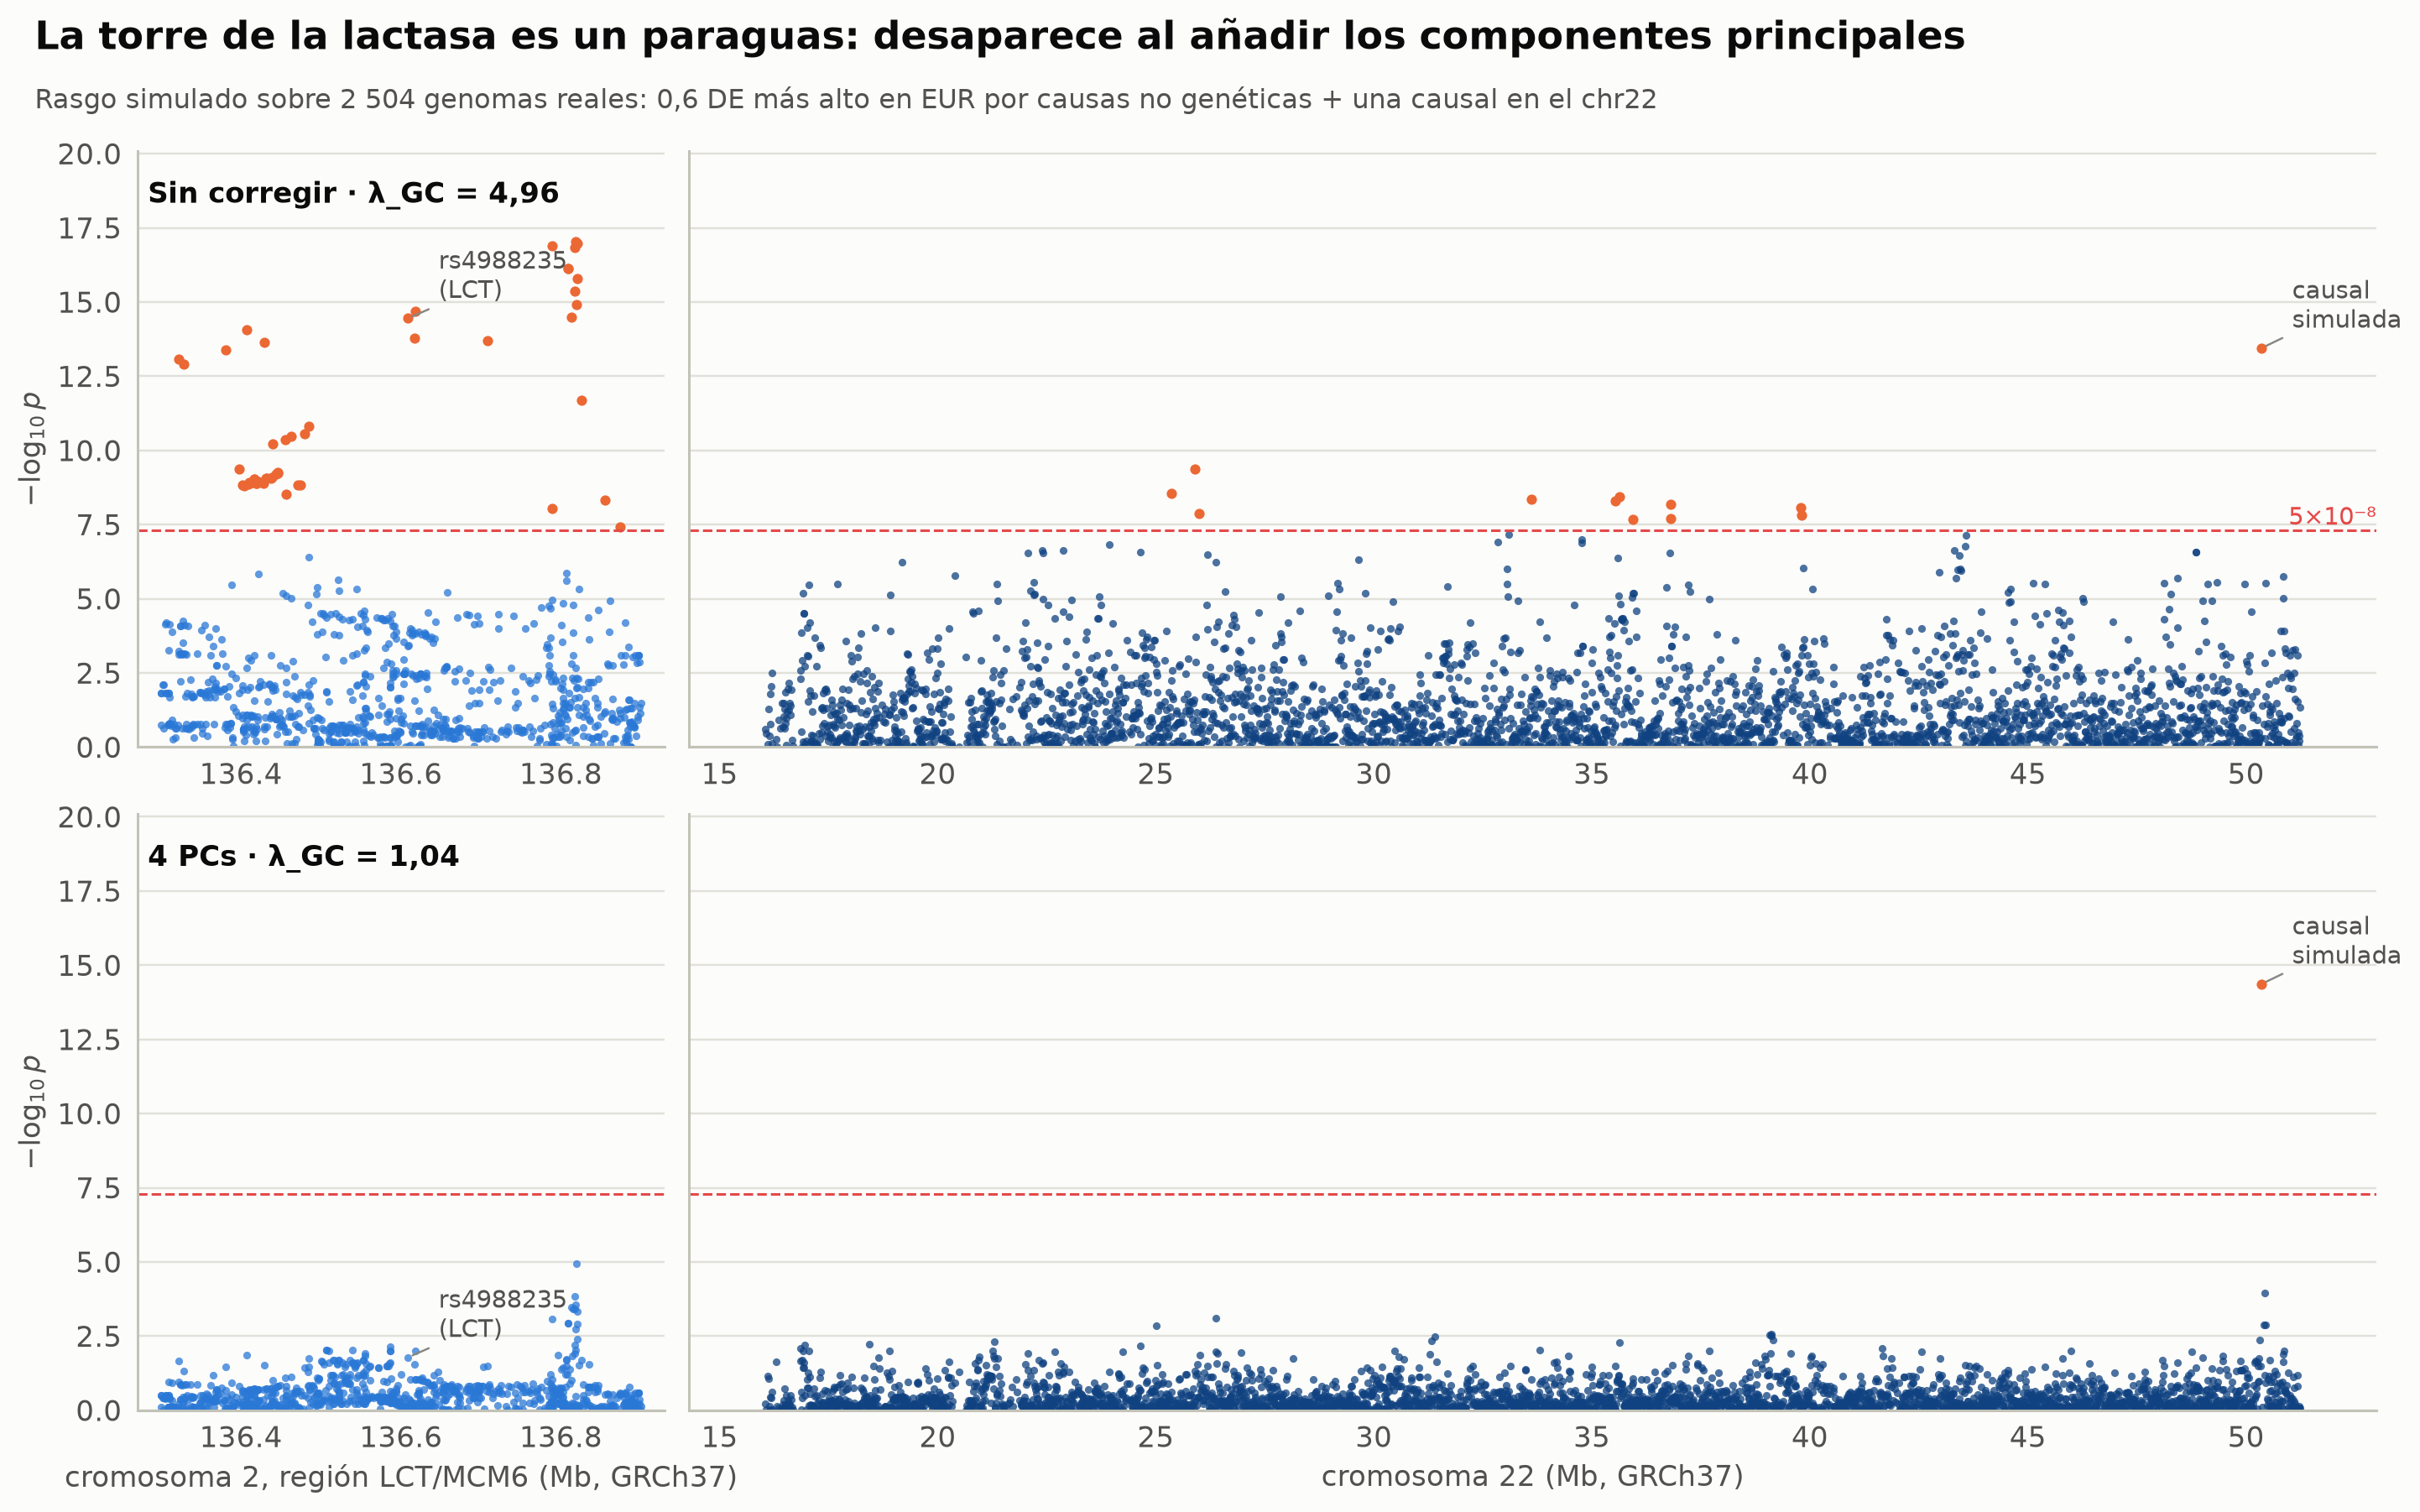

In [17]:
def manhattan_panels(axes_row, pv, title_left):
    """Dibuja la región LCT (izquierda) y el chr22 (derecha) en una fila de dos ejes."""
    lp = -np.log10(pv)
    for ax, chrom, col in ((axes_row[0], 2, ec.BLUE), (axes_row[1], 22, "#104281")):
        m = (snps.chrom == chrom).values
        x = snps.pos[m].values / 1e6
        sig = pv[m] < GW
        ax.scatter(x[~sig], lp[m][~sig], s=9, color=col, alpha=0.75, lw=0)
        ax.scatter(x[sig], lp[m][sig], s=16, color=ec.ORANGE, lw=0)
        ax.axhline(-math.log10(GW), color=ec.RED, ls="--", lw=1)
        ax.grid(axis="x", visible=False)
    axes_row[0].set_ylabel("$-\\log_{10} p$")
    axes_row[0].text(0.02, 0.95, title_left, transform=axes_row[0].transAxes, va="top", fontsize=11,
                     fontweight="bold", color=ec.INK)
    for i, lab in ((i_lct, "rs4988235\n(LCT)"), (i_cau, "causal\nsimulada")):
        ax = axes_row[0] if snps.chrom[i] == 2 else axes_row[1]
        ax.annotate(lab, (snps.pos[i] / 1e6, lp[i]), xytext=(12, 8), textcoords="offset points", fontsize=9.5,
                    color=ec.INK_2, arrowprops=dict(arrowstyle="-", color=ec.MUTED, lw=0.8))

ymax = -np.log10(min(p0.min(), p4.min())) * 1.18
fig, axes = plt.subplots(2, 2, figsize=(13, 7.4), sharey=True, gridspec_kw={"width_ratios": [1, 3.2]})
manhattan_panels(axes[0], p0, f"Sin corregir · λ_GC = {lam_by_K[0]:.2f}".replace(".", ","))
manhattan_panels(axes[1], p4, f"4 PCs · λ_GC = {lam_by_K[4]:.2f}".replace(".", ","))
for ax in axes.ravel():
    ax.set_ylim(0, ymax)
axes[0, 1].text(1.0, -math.log10(GW), " 5×10⁻⁸", transform=axes[0, 1].get_yaxis_transform(), va="bottom",
                ha="right", fontsize=9.5, color=ec.RED)
axes[1, 0].set_xlabel("cromosoma 2, región LCT/MCM6 (Mb, GRCh37)")
axes[1, 1].set_xlabel("cromosoma 22 (Mb, GRCh37)")
ec.fig_title(fig, "La torre de la lactasa es un paraguas: desaparece al añadir los componentes principales",
             "Rasgo simulado sobre 2 504 genomas reales: 0,6 DE más alto en EUR por causas no genéticas + una causal en el chr22")
plt.show()

> 🔎 **Qué observamos.** Arriba, sin corregir, la región *LCT* forma un **rascacielos** y el cromosoma 22 entero está
> "levantado": su horizonte de ruido flota más alto de lo normal, y varios SNP del chr22 sin ningún efecto rozan o
> superan el umbral. Abajo, con 4 componentes, el horizonte baja, la torre de la lactasa desaparece y sólo queda en pie
> la variante causal. Con $n=2\,504$ la simulación es modesta; en un biobanco de 500 000 personas la misma diferencia de
> medias produciría cientos de torres falsas.

### Paso 5 · 🎬 El QQ se desinfla a medida que añadimos componentes

Veamos el efecto de cada componente por separado: del análisis ingenuo ($K=0$) a $K=10$.

![Vista previa: el gráfico QQ del GWAS real se desinfla al añadir componentes principales; λ_GC cae de ≈5 a ≈1 y la cola de la región LCT se hunde.](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-10-poblaciones-gwas/10.3_qq_pcs.gif)

*Vista previa: el gráfico QQ del GWAS real se desinfla al añadir componentes principales; λ_GC cae de ≈5 a ≈1 y la cola de la región LCT se hunde.*

In [18]:
# 🎬 Animación: QQ del chr22 (azul) y de la región LCT (naranja) para K = 0 … 10
M22 = int(is22.sum()); ML = int((~is22).sum())
e_b, lo_b, hi_b = qq_band(M22)
fig, ax = plt.subplots(figsize=(8.5, 6.2))
ax.fill_between(e_b, lo_b, hi_b, color=ec.GRID, lw=0)
ax.plot([0, 4], [0, 4], color=ec.MUTED, ls="--", lw=1)
top = -np.log10(p0.min()) * 1.08
ax.set_xlim(0, 3.7); ax.set_ylim(0, top)
ax.set_xlabel("$-\\log_{10} p$ esperado"); ax.set_ylabel("$-\\log_{10} p$ observado")
pts22, = ax.plot([], [], "o", ms=3.5, color=ec.BLUE, mec="none", alpha=0.85, label=f"chr22 ({M22} SNP)")
ptsL, = ax.plot([], [], "o", ms=3.5, color=ec.ORANGE, mec="none", alpha=0.85, label=f"región LCT ({ML} SNP)")
ax.axhline(-math.log10(GW), color=ec.RED, ls="--", lw=1)
ax.legend(loc="upper left", frameon=False, bbox_to_anchor=(0, 0.93))
info = ax.text(0.02, 0.97, "", transform=ax.transAxes, va="top", fontsize=12, fontweight="bold", color=ec.INK)
ax.set_title("Cada componente principal se lleva una parte de la inflación", loc="left")
frames = [K for K in range(11) for _ in range(3)] + [10] * 3
def qq_xy(pv):
    pv = np.sort(pv); m = len(pv)
    return -np.log10((np.arange(1, m + 1) - 0.5) / m), -np.log10(pv)
def update(f):
    K = frames[f]
    pts22.set_data(*qq_xy(P_by_K[K][is22]))
    ptsL.set_data(*qq_xy(P_by_K[K][~is22]))
    info.set_text(f"K = {K} PCs   ·   λ_GC (chr22) = {lam_by_K[K]:.2f}".replace(".", ","))
    return pts22, ptsL, info
update(0)
ec.animate(fig, update, frames=len(frames), interval=260, name="10.3_qq_pcs")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

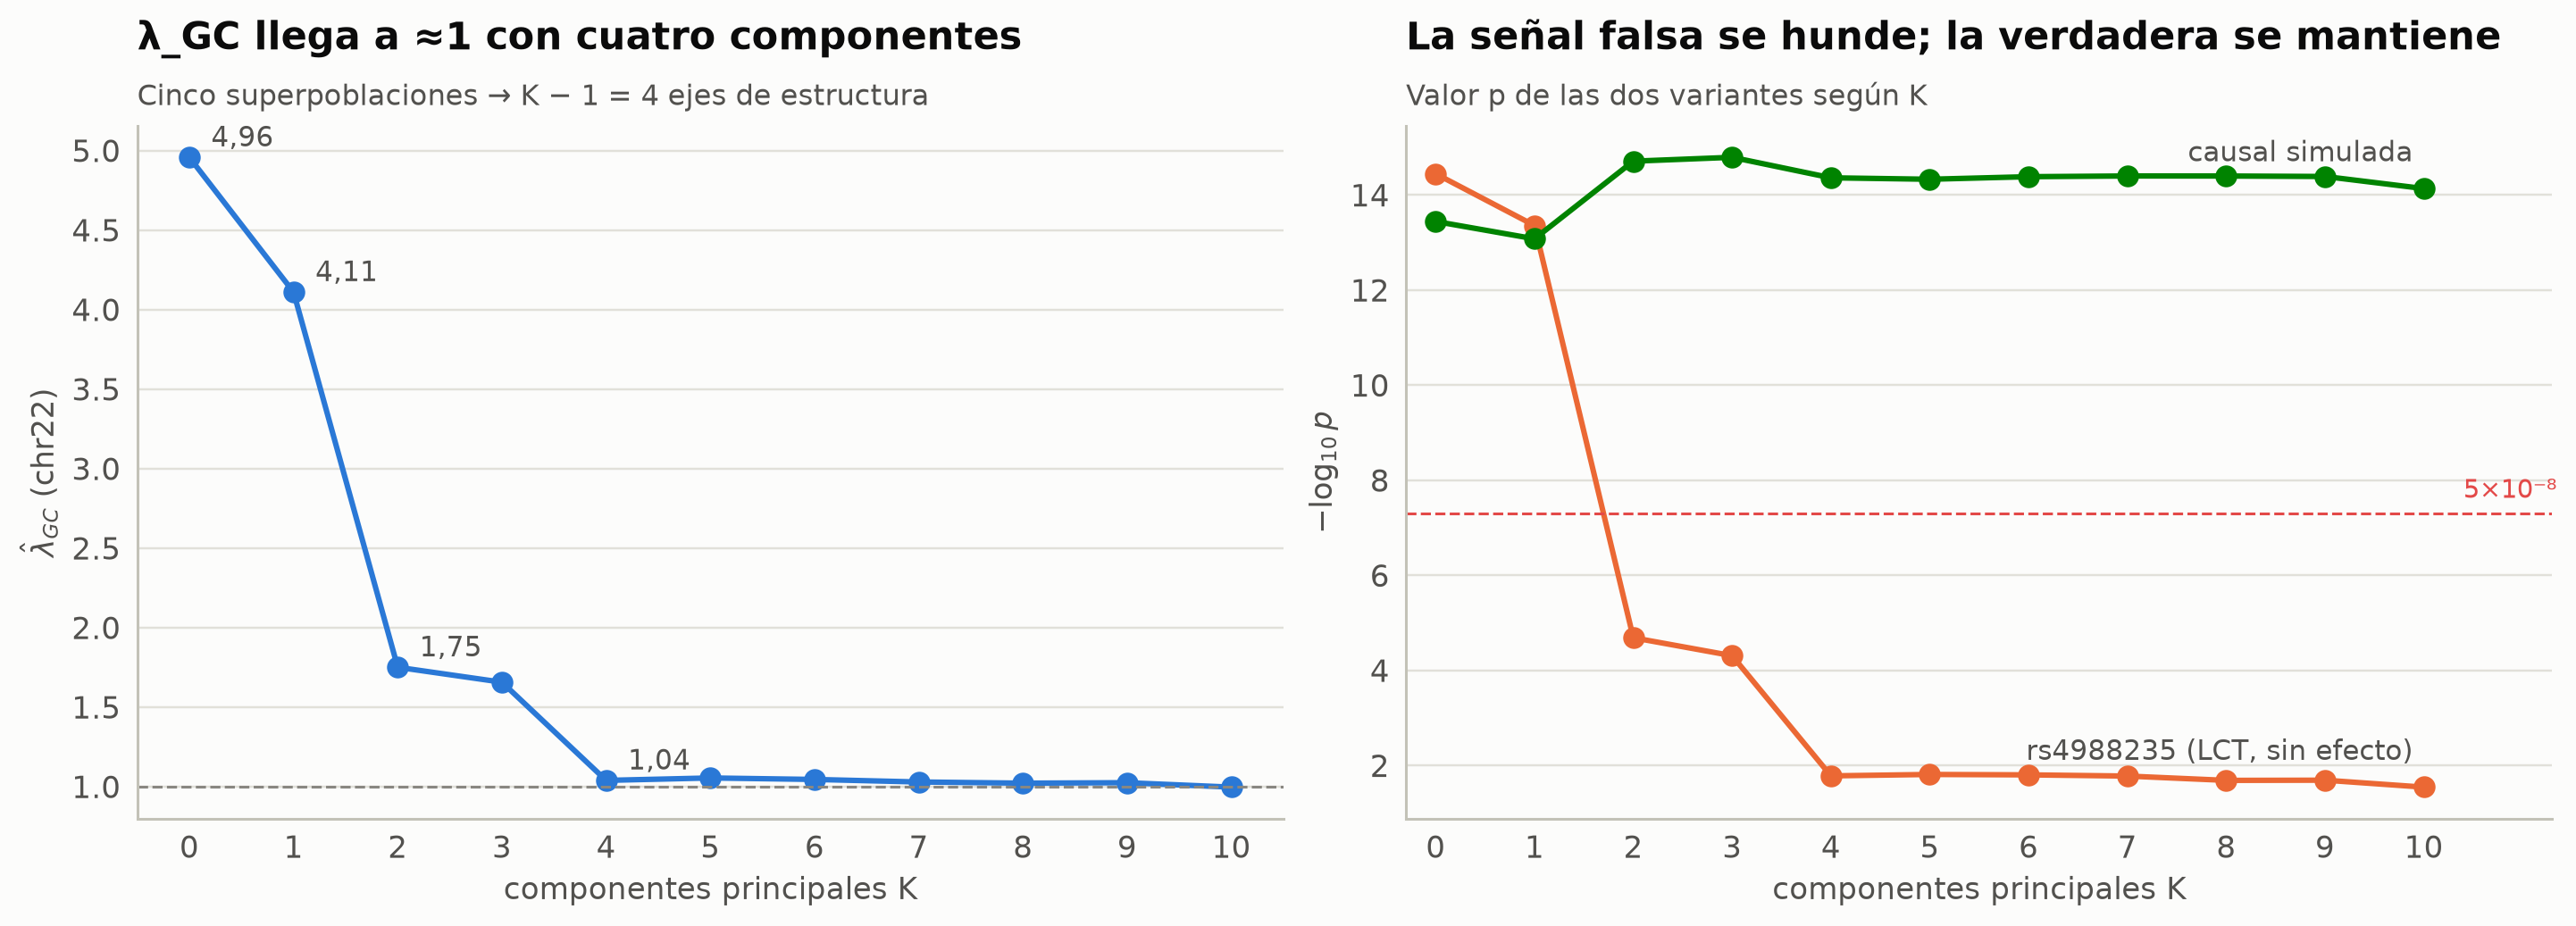

In [19]:
Ks = np.arange(11)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
ax = axes[0]
ax.plot(Ks, [lam_by_K[K] for K in Ks], "o-", color=ec.BLUE, lw=2)
ax.axhline(1, color=ec.MUTED, ls="--", lw=1)
for K in (0, 1, 2, 4):
    ax.annotate(f"{lam_by_K[K]:.2f}".replace(".", ","), (K, lam_by_K[K]), xytext=(8, 4),
                textcoords="offset points", fontsize=10, color=ec.INK_2)
ax.set_xlabel("componentes principales K"); ax.set_ylabel("$\\hat\\lambda_{GC}$ (chr22)"); ax.set_xticks(Ks)
ec.title(ax, "λ_GC llega a ≈1 con cuatro componentes", "Cinco superpoblaciones → K − 1 = 4 ejes de estructura")
ax = axes[1]
for i, lab, col in ((i_lct, "rs4988235 (LCT, sin efecto)", ec.ORANGE), (i_cau, "causal simulada", ec.GREEN)):
    vals = [-np.log10(P_by_K[K][i]) for K in Ks]
    ax.plot(Ks, vals, "o-", color=col, lw=2)
    ax.annotate(lab, (10, vals[-1]), xytext=(-4, 10), textcoords="offset points", ha="right", fontsize=10,
                color=ec.INK_2)
ax.axhline(-math.log10(GW), color=ec.RED, ls="--", lw=1)
ax.text(10.4, -math.log10(GW) + 0.2, "5×10⁻⁸", va="bottom", fontsize=9.5, color=ec.RED)
ax.set_xlabel("componentes principales K"); ax.set_ylabel("$-\\log_{10} p$"); ax.set_xticks(Ks)
ax.set_xlim(-0.3, 11.3)
ec.title(ax, "La señal falsa se hunde; la verdadera se mantiene", "Valor p de las dos variantes según K")
plt.show()

> 🔎 **Qué observamos.** PC1 (África frente al resto) apenas corrige, porque nuestro confusor es "ser europeo", que
> se separa sobre todo con PC2 (Europa frente a Asia oriental); PC3 y PC4 terminan de aislar a Europa de SAS y AMR. A partir de $K=4$ la curva se aplana: añadir más componentes ya no cambia
> nada, y cuesta muy poco (un grado de libertad por componente con 2 504 personas). Por eso en la práctica se incluyen
> 10 o 20 componentes "por si acaso". Observe también que con sólo 3 112 SNP la propia estimación de $\hat\lambda_{GC}$
> tiene un error de muestreo de unas ±0,05: un 1,04 no es distinguible de 1.

### Paso 6 · 🔍 Explore el Manhattan y el QQ

Pase el ratón sobre cada punto: verá su posición, el valor $p$ antes y después de corregir y la frecuencia del alelo
en cada superpoblación. Busque la relación entre "cuánto se hunde un SNP al corregir" y "cuánto difieren sus
frecuencias entre EUR y los demás".

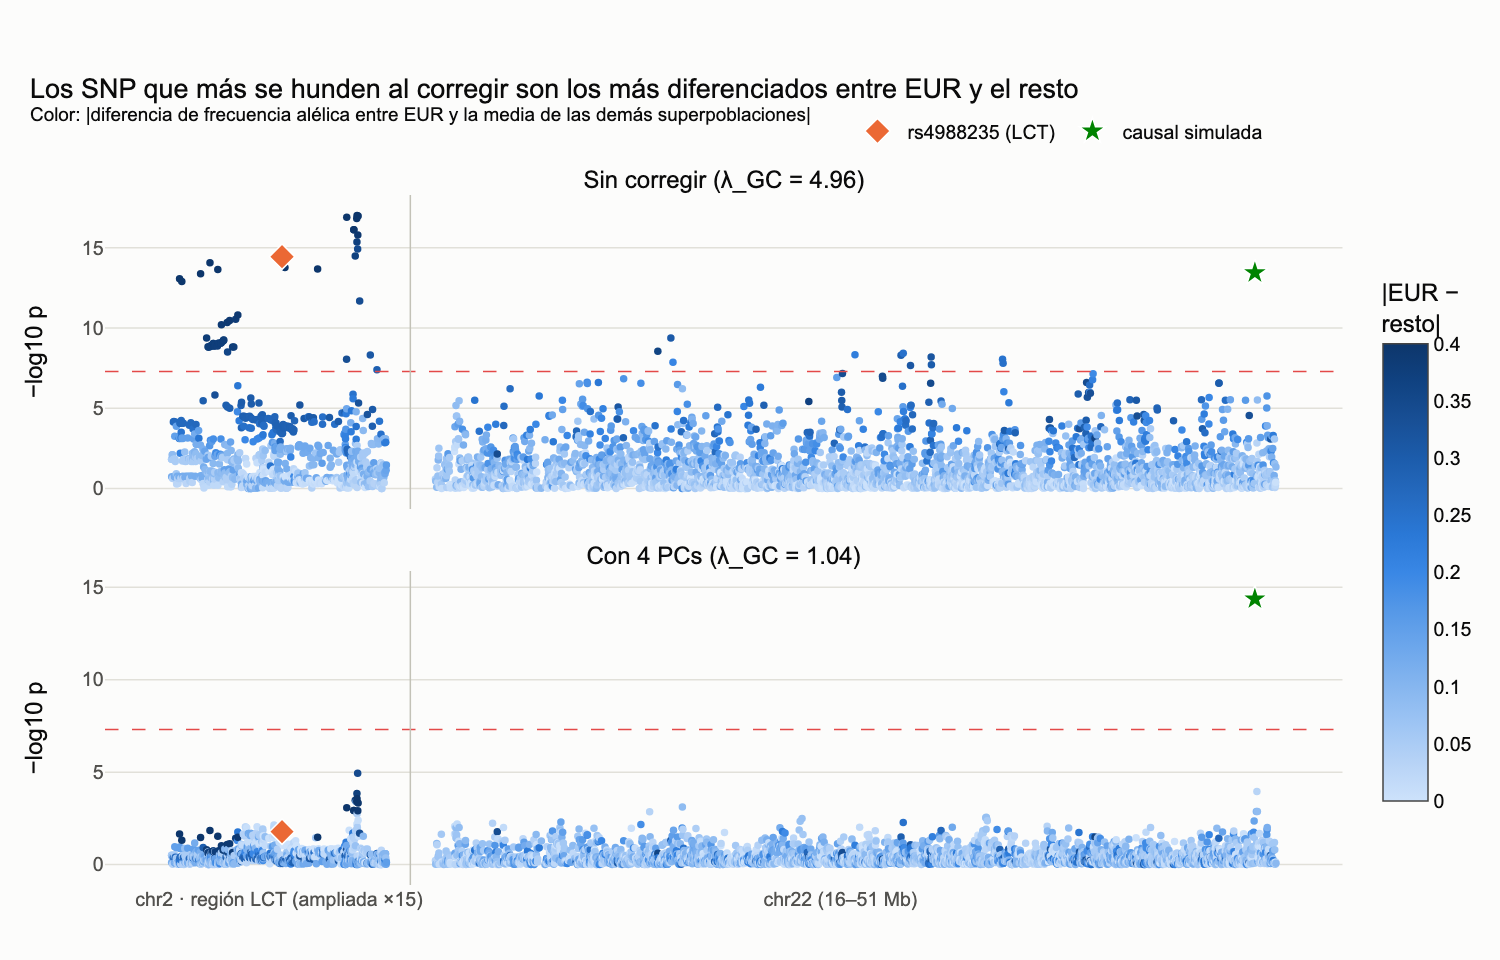

In [20]:
snps["label"] = np.where(snps.chrom == 2, "2:" + snps.pos.astype(str), "22:" + snps.pos.astype(str))
snps.loc[i_lct, "label"] = "2:136608646 · rs4988235 (LCT −13910, persistencia de la lactasa)"
snps.loc[i_cau, "label"] = f"22:{POS_CAUSAL} · variante causal simulada"
snps["d_eur"] = snps.f_EUR - snps[["f_AFR", "f_AMR", "f_EAS", "f_SAS"]].mean(axis=1)
# eje x: la región LCT (0,6 Mb) se amplía 15 veces para que su torre se vea; luego el chr22 en Mb
xoff = np.where(snps.chrom == 2, (snps.pos - 136.3e6) / 1e6 * 15, 11 + (snps.pos - 16e6) / 1e6)
hover = [f"<b>{r.label}</b><br>p ingenuo = {a:.1e}<br>p con 4 PCs = {b:.1e}<br>"
         f"frecuencia ALT: EUR {r.f_EUR:.2f} · AFR {r.f_AFR:.2f} · EAS {r.f_EAS:.2f} · SAS {r.f_SAS:.2f} · "
         f"AMR {r.f_AMR:.2f}<br>EUR − media del resto = {r.d_eur:+.2f}"
         for r, a, b in zip(snps.itertuples(), p0, p4)]
figp = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.09,
                     subplot_titles=(f"Sin corregir (λ_GC = {lam_by_K[0]:.2f})", f"Con 4 PCs (λ_GC = {lam_by_K[4]:.2f})"))
blues = [[i / (len(ec.SEQ_BLUE) - 1), c] for i, c in enumerate(ec.SEQ_BLUE)]
for row, pv in ((1, p0), (2, p4)):
    figp.add_trace(go.Scatter(x=xoff, y=-np.log10(pv), mode="markers", hovertext=hover, hoverinfo="text",
                              marker=dict(size=5, color=snps.d_eur.abs(), colorscale=blues, cmin=0, cmax=0.4,
                                          colorbar=dict(title="|EUR −<br>resto|", len=0.8) if row == 1 else None,
                                          showscale=row == 1), showlegend=False), row=row, col=1)
    for i, sym, col, nm in ((i_lct, "diamond", ec.ORANGE, "rs4988235 (LCT)"), (i_cau, "star", ec.GREEN, "causal simulada")):
        figp.add_trace(go.Scatter(x=[xoff[i]], y=[-np.log10(pv[i])], mode="markers", hovertext=[hover[i]],
                                  hoverinfo="text", name=nm, showlegend=row == 1,
                                  marker=dict(size=13, symbol=sym, color=col, line=dict(color="white", width=1))),
                          row=row, col=1)
    figp.add_hline(y=-math.log10(GW), line=dict(color=ec.RED, dash="dash", width=1), row=row, col=1)
figp.update_xaxes(tickvals=[4.5, 28], ticktext=["chr2 · región LCT (ampliada ×15)", "chr22 (16–51 Mb)"],
                  showgrid=False)
figp.add_vline(x=10, line=dict(color=ec.BASELINE, width=1))
figp.update_yaxes(title_text="−log10 p")
figp.update_layout(height=640, margin=dict(t=130, l=70, r=40, b=50),
                   legend=dict(yanchor="bottom", y=1.06, x=0.6, orientation="h"),
                   title="Los SNP que más se hunden al corregir son los más diferenciados entre EUR y el resto"
                         "<br><sup>Color: |diferencia de frecuencia alélica entre EUR y la media de las demás superpoblaciones|</sup>")
figp.show()

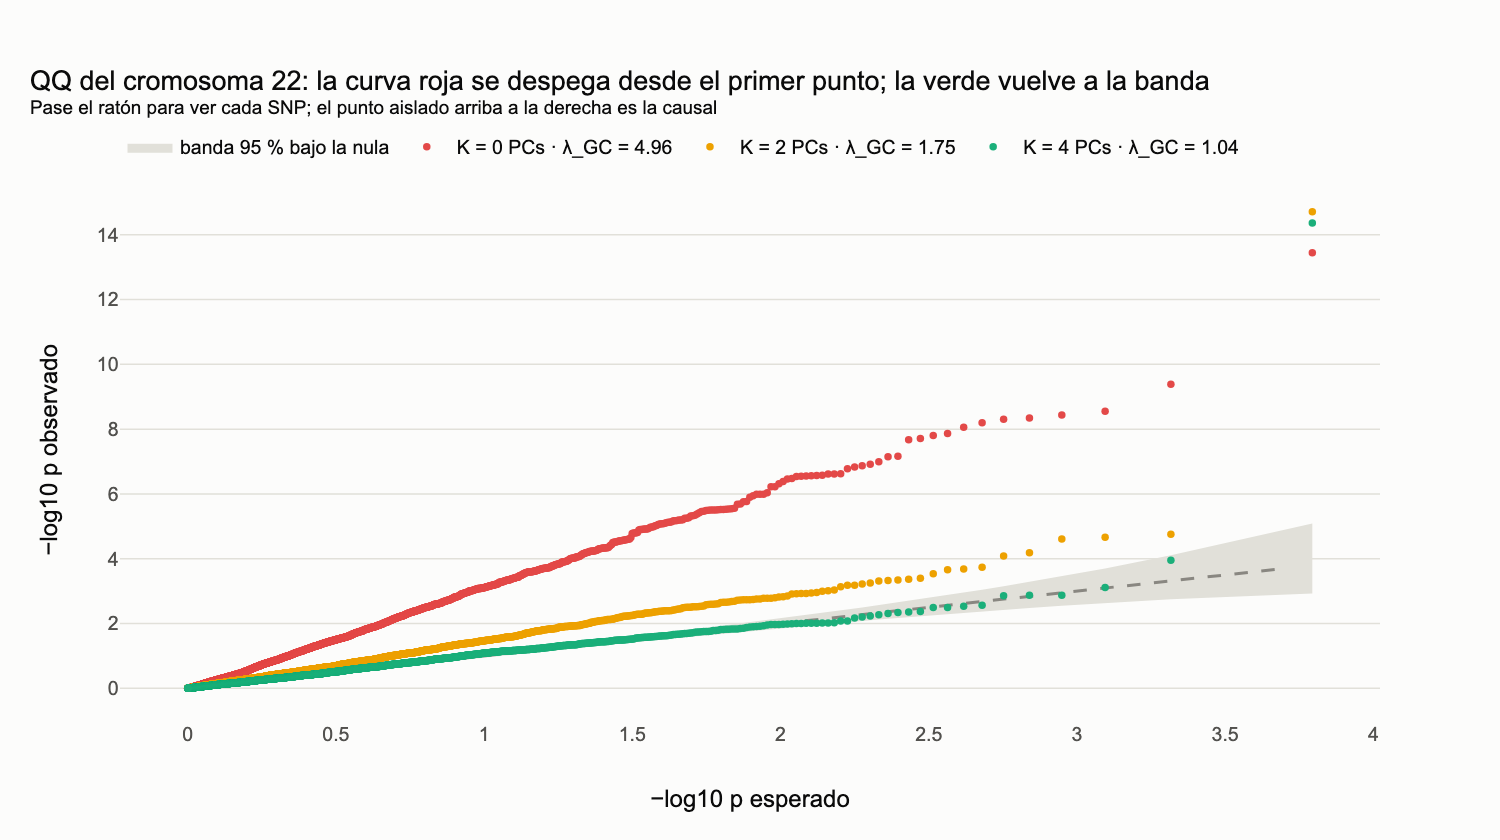

In [21]:
# QQ interactivo: ingenuo, 2 PCs y 4 PCs, con la banda del 95 %
figq = go.Figure()
e_b, lo_b, hi_b = qq_band(M22)
figq.add_trace(go.Scatter(x=np.r_[e_b, e_b[::-1]], y=np.r_[hi_b, lo_b[::-1]], fill="toself", fillcolor=ec.GRID,
                          line=dict(width=0), hoverinfo="skip", name="banda 95 % bajo la nula"))
figq.add_trace(go.Scatter(x=[0, 3.7], y=[0, 3.7], mode="lines", line=dict(color=ec.MUTED, dash="dash"),
                          hoverinfo="skip", showlegend=False))
lab22 = snps.label[is22].values
for K, col in ((0, ec.RED), (2, ec.YELLOW), (4, ec.AQUA)):
    pv = P_by_K[K][is22]; o = np.argsort(pv); m = len(pv)
    exp_ = -np.log10((np.arange(1, m + 1) - 0.5) / m)
    txt = [f"<b>{lab22[j]}</b><br>rango {k + 1} de {m}<br>p observado = {pv[j]:.1e}<br>p esperado = {10 ** -exp_[k]:.1e}"
           for k, j in enumerate(o)]
    figq.add_trace(go.Scatter(x=exp_, y=-np.log10(pv[o]), mode="markers", marker=dict(size=5, color=col),
                              hovertext=txt, hoverinfo="text", name=f"K = {K} PCs · λ_GC = {lam_by_K[K]:.2f}"))
figq.update_layout(height=560, xaxis_title="−log10 p esperado", yaxis_title="−log10 p observado",
                   legend=dict(yanchor="bottom", y=1.02, x=0, orientation="h"), margin=dict(t=120),
                   title="QQ del cromosoma 22: la curva roja se despega desde el primer punto; la verde vuelve a la banda"
                         "<br><sup>Pase el ratón para ver cada SNP; el punto aislado arriba a la derecha es la causal</sup>")
figq.show()

> 🔎 **Qué observamos.** En el Manhattan interactivo, los puntos azul oscuro (alelos mucho más o mucho menos frecuentes
> en EUR que en el resto) son los que más se hunden al corregir; los claros (frecuencias parecidas en todos los
> continentes), como la causal (estrella verde), casi no cambian. Esa
> es la diferencia entre el control genómico, que castiga a todos por igual, y los componentes principales. En el QQ,
> la curva ingenua se separa de la diagonal desde el principio; con 4 PCs la nube vuelve a la banda y sólo se despega el
> punto de la causal.

### Paso 7 · La potencia, medida en genotipos reales

¿Era "suerte" encontrar la causal? La ecuación de $q^2$ predice su potencia: con $n=2\,504$ y $q^2=2\,\%$, la no
centralidad es $2504\cdot0{,}02/0{,}98\approx51$. Comprobémoslo repitiendo el experimento cientos de veces con el mismo
SNP real y distintos valores de $q^2$.

> 🤔 **Antes de ejecutar, prediga.** ¿Qué $q^2$ hace falta con 2 504 personas para tener un 50 % de potencia al umbral
> genómico?

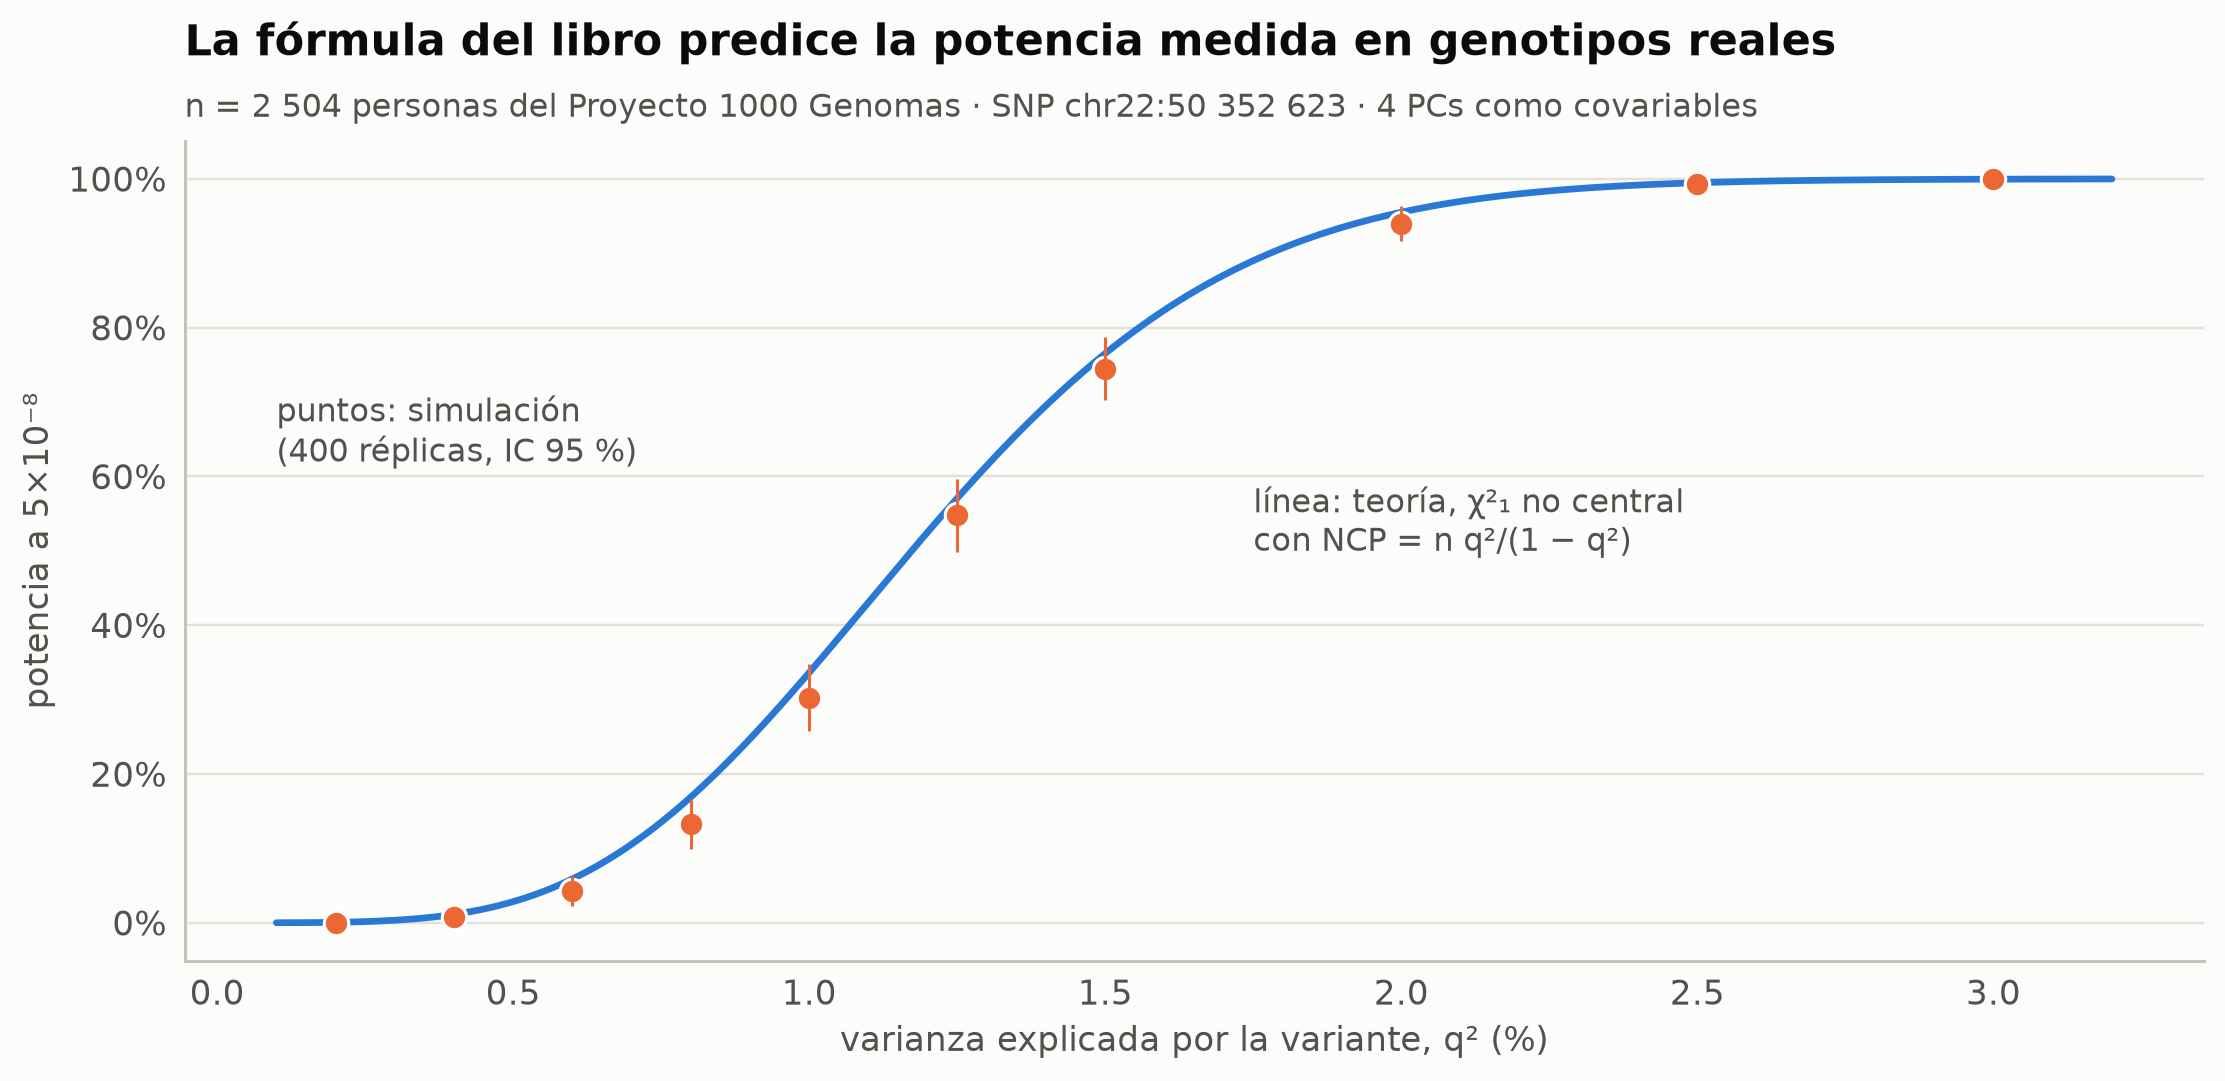

q² (%)   potencia simulada   teoría
  0.20                0.00     0.00
  0.40                0.01     0.01
  0.60                0.04     0.06
  0.80                0.13     0.17
  1.00                0.30     0.34
  1.25                0.55     0.57
  1.50                0.74     0.77
  2.00                0.94     0.96
  2.50                0.99     0.99
  3.00                1.00     1.00


In [22]:
rng_pw = np.random.default_rng(1033)
Q4, _ = np.linalg.qr(np.column_stack([np.ones(len(g_c)), PCs[:, :4]]))
gr = g_c - Q4 @ (Q4.T @ g_c); sxx = gr @ gr
n_obs, reps_pw, df_pw = len(g_c), 400, len(g_c) - Q4.shape[1] - 1
q2_grid = np.array([0.002, 0.004, 0.006, 0.008, 0.010, 0.0125, 0.015, 0.02, 0.025, 0.03])
emp = []
for q2 in q2_grid:
    b = math.sqrt(q2 / (2 * p_c * (1 - p_c)))
    Y = (D_EUR * is_eur + b * (g_c - g_c.mean()))[:, None] + rng_pw.normal(size=(n_obs, reps_pw)) * math.sqrt(1 - q2)
    Yr = Y - Q4 @ (Q4.T @ Y)
    bh = gr @ Yr / sxx
    se = np.sqrt(((Yr ** 2).sum(0) - bh ** 2 * sxx) / df_pw / sxx)
    emp.append((2 * stats.t.sf(np.abs(bh / se), df_pw) < GW).mean())
emp = np.array(emp)
qq_fine = np.linspace(0.001, 0.032, 200)
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(qq_fine * 100, power_gw(n_obs, qq_fine), color=ec.BLUE, lw=2.2)
ax.plot(q2_grid * 100, emp, "o", color=ec.ORANGE, ms=8, mec="white")
se_emp = np.sqrt(emp * (1 - emp) / reps_pw)
ax.errorbar(q2_grid * 100, emp, yerr=1.96 * se_emp, fmt="none", ecolor=ec.ORANGE, lw=1)
ax.text(1.75, 0.5, "línea: teoría, χ²₁ no central\ncon NCP = n q²/(1 − q²)", fontsize=10.5, color=ec.INK_2)
ax.text(0.1, 0.62, f"puntos: simulación\n({reps_pw} réplicas, IC 95 %)", fontsize=10.5, color=ec.INK_2)
ax.set_xlabel("varianza explicada por la variante, q² (%)"); ax.set_ylabel("potencia a 5×10⁻⁸")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ec.title(ax, "La fórmula del libro predice la potencia medida en genotipos reales",
         f"n = {n_obs:,} personas del Proyecto 1000 Genomas · SNP chr22:{POS_CAUSAL:,} · 4 PCs como covariables"
         .replace(",", " "))
plt.show()
print("q² (%)   potencia simulada   teoría")
for q2, e_ in zip(q2_grid, emp):
    print(f"{q2 * 100:6.2f}   {e_:17.2f}   {power_gw(n_obs, q2):6.2f}")

> 🔎 **Qué observamos.** Los puntos simulados caen sobre la curva teórica: la ecuación de $q^2$ del libro funciona también
> con genotipos reales, con su LD, sus frecuencias desiguales y sus covariables. Con 2 504 personas hace falta una variante
> que explique **más del 1 %** de la varianza para tener una potencia razonable. Las variantes reales de la estatura
> explican, cada una, del orden de una **diezmilésima**: por eso los GWAS de la estatura necesitan cientos de miles o
> millones de participantes.

## 6. Comparaciones múltiples

### La lotería de un millón de boletos

Si usted compra un boleto de lotería con probabilidad $1/20$ de premio, ganar sería una sorpresa agradable. Si compra
**un millón** de boletos, ganar unas 50 000 veces es lo esperado y no dice nada de su suerte. Un GWAS compra un boleto
por variante: con un millón de pruebas independientes y el umbral clásico $\alpha=0{,}05$, esperaríamos **50 000 falsos
positivos**. Hay dos filosofías para evitarlo.

### Error por familia: Bonferroni y $5\times10^{-8}$

La **tasa de error por familia** (FWER, *family-wise error rate*) es la probabilidad de cometer **al menos un** falso
positivo. Por la desigualdad de Boole, si cada una de $M$ pruebas se realiza al nivel $\alpha/M$,

$$
\mathrm{FWER} = P\Big(\bigcup_{j=1}^{M}\{p_j\le \alpha/M\}\Big) \le \sum_{j=1}^{M}\frac{\alpha}{M} = \alpha ,
$$

**sin ningún supuesto** sobre la dependencia entre pruebas.

| Símbolo | Significado |
|---|---|
| $M$ | número de pruebas (variantes) |
| $\alpha$ | error por familia que estamos dispuestos a tolerar (típicamente 0,05) |
| $\alpha/M$ | umbral de Bonferroni para cada prueba |
| FWER | probabilidad de al menos un falso positivo entre las $M$ pruebas |

En un GWAS las pruebas no son independientes: el LD hace que muchas variantes vecinas sean casi redundantes, y
Bonferroni sobre el número bruto de variantes sería demasiado conservador. Pe'er *et al.* (2008) estimaron el número
**efectivo** de pruebas independientes al evaluar prácticamente todas las variantes comunes del genoma en poblaciones de
ascendencia europea, que resultó del orden de **un millón**. De ahí el umbral convencional de significación genómica,
$0{,}05/10^6=5\times10^{-8}$. En poblaciones africanas, con LD más corto, el número efectivo de pruebas es mayor y el
umbral debería ser algo más estricto; y con variantes raras de secuenciación completa, también.

In [23]:
M, a = 1_000_000, 0.05
print(f"Falsos positivos esperados con {M:,} pruebas nulas a α = {a}: {M * a:,.0f}")
print(f"P(al menos uno) si fueran independientes: 1 − (1 − α)^M = {1 - (1 - a) ** M:.6f}")
print(f"Bonferroni: α/M = {a / M:.1e}  →  P(al menos uno) ≤ {1 - (1 - a / M) ** M:.4f}")

Falsos positivos esperados con 1,000,000 pruebas nulas a α = 0.05: 50,000
P(al menos uno) si fueran independientes: 1 − (1 − α)^M = 1.000000
Bonferroni: α/M = 5.0e-08  →  P(al menos uno) ≤ 0.0488


### Tasa de falsos descubrimientos: Benjamini-Hochberg

En estudios exploratorios (un cribado de expresión génica, una lista de candidatos para validar en el laboratorio),
controlar la probabilidad de un **solo** error puede ser excesivo. Benjamini y Hochberg (1995) propusieron controlar la
**tasa de falsos descubrimientos** (FDR): la **proporción esperada** de falsos positivos entre las pruebas declaradas
significativas. Si usted envía 100 variantes a validar con FDR = 5 %, espera que unas 5 fallen, y lo acepta.

**Procedimiento de Benjamini-Hochberg.** Se ordenan los valores $p$ de menor a mayor, $p_{(1)}\le\dots\le p_{(M)}$, y
se busca

$$
k^\ast = \max\left\{k:\ p_{(k)} \le \frac{k}{M}\,\alpha\right\}.
$$

Se rechazan las hipótesis correspondientes a $p_{(1)},\dots,p_{(k^\ast)}$. Si las pruebas son independientes, el
procedimiento garantiza $\mathrm{FDR}\le \frac{M_0}{M}\alpha\le\alpha$.

| Símbolo | Significado |
|---|---|
| $p_{(k)}$ | $k$-ésimo valor $p$ más pequeño |
| $k\alpha/M$ | umbral de BH para el rango $k$: una recta que crece con el rango |
| $k^\ast$ | número de descubrimientos: el mayor rango cuyo valor $p$ cae bajo la recta $k\alpha/M$ |
| $M_0$ | número (desconocido) de hipótesis nulas ciertas |

### Ejemplo del libro: «Bonferroni frente a Benjamini-Hochberg»

Diez pruebas dan, ordenados, los valores $p$: 0,0001, 0,0008, 0,0021, 0,0042, 0,0110, 0,0290, 0,0480, 0,0730, 0,21 y
0,62. Con $\alpha=0{,}05$:

| rango $k$ | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 |
|---|---|---|---|---|---|---|---|---|---|---|
| $p_{(k)}$ | 0,0001 | 0,0008 | 0,0021 | 0,0042 | 0,0110 | **0,0290** | 0,0480 | 0,0730 | 0,21 | 0,62 |
| Bonferroni $\alpha/M$ | 0,005 | 0,005 | 0,005 | 0,005 | 0,005 | 0,005 | 0,005 | 0,005 | 0,005 | 0,005 |
| BH $k\alpha/M$ | 0,005 | 0,010 | 0,015 | 0,020 | 0,025 | **0,030** | 0,035 | 0,040 | 0,045 | 0,050 |
| ¿$p_{(k)}\le k\alpha/M$? | sí | sí | sí | sí | sí | **sí** | no | no | no | no |

Bonferroni exige $p\le0{,}005$ y rechaza **4**. El sexto valor ($0{,}0290\le0{,}030$) todavía cae bajo su umbral de BH y el
séptimo ($0{,}048>0{,}035$) ya no, de modo que $k^\ast=6$ y se rechazan **seis** hipótesis. Observe que no es necesario
que todos los valores anteriores cumplan su propio umbral: lo que cuenta es el **mayor** $k$ que lo hace (por eso se
llama procedimiento *step-up*: se recorre desde el final hacia arriba).

> 🤔 **Antes de ejecutar, prediga.** Si el quinto valor fuera 0,0260 (por encima de su umbral 0,025), ¿cuántas
> hipótesis rechazaría BH?

In [24]:
p_ex = np.array([0.0001, 0.0008, 0.0021, 0.0042, 0.0110, 0.0290, 0.0480, 0.0730, 0.21, 0.62])
thr_ex = 0.05 * np.arange(1, 11) / 10
print("umbrales BH:", ", ".join(f"{t:.3f}" for t in thr_ex))
print(f"k* = {np.where(p_ex <= thr_ex)[0].max() + 1}   ·   Bonferroni rechaza {np.sum(p_ex <= 0.05 / 10)}")
print("benjamini_hochberg() del libro →", benjamini_hochberg(p_ex).astype(int))
p_mod = p_ex.copy(); p_mod[4] = 0.0260
print("con p_(5) = 0,0260           →", benjamini_hochberg(p_mod).astype(int), "(¡siguen siendo 6!)")

umbrales BH: 0.005, 0.010, 0.015, 0.020, 0.025, 0.030, 0.035, 0.040, 0.045, 0.050
k* = 6   ·   Bonferroni rechaza 4
benjamini_hochberg() del libro → [1 1 1 1 1 1 0 0 0 0]
con p_(5) = 0,0260           → [1 1 1 1 1 1 0 0 0 0] (¡siguen siendo 6!)


![Vista previa: el procedimiento de Benjamini-Hochberg recorre los rangos desde el mayor hasta encontrar el primer valor p bajo la recta kα/M; todo lo que queda a su izquierda se rechaza.](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-10-poblaciones-gwas/10.3_bh_stepup.gif)

*Vista previa: el procedimiento de Benjamini-Hochberg recorre los rangos desde el mayor hasta encontrar el primer valor p bajo la recta kα/M; todo lo que queda a su izquierda se rechaza.*

In [25]:
# 🎬 Animación: el recorrido step-up de BH sobre los diez valores p del libro
kk = np.arange(1, 11)
fig, ax = plt.subplots(figsize=(10, 5.4))
ax.set_yscale("log"); ax.set_ylim(5e-5, 1.2); ax.set_xlim(0.4, 10.9)
ax.plot(kk, thr_ex, color=ec.ORANGE, lw=2.2)
ax.axhline(0.005, color=ec.RED, ls="--", lw=1.4)
ax.text(10.85, thr_ex[-1] * 1.12, "BH: kα/M", ha="right", va="bottom", fontsize=10.5, color=ec.INK_2)
ax.text(10.85, 0.005 / 1.15, "Bonferroni: α/M = 0,005", ha="right", va="top", fontsize=10.5, color=ec.INK_2)
dots = ax.scatter(kk, p_ex, s=90, color=ec.MUTED, zorder=3, edgecolor="white", lw=1.5)
for k, p in zip(kk, p_ex):
    ax.annotate(f"{p:g}".replace(".", ","), (k, p), xytext=(0, 11), textcoords="offset points", ha="center",
                fontsize=9, color=ec.INK_2)
cursor = ax.axvline(10, color=ec.BLUE, lw=6, alpha=0.18)
msg = ax.text(0.02, 0.97, "", transform=ax.transAxes, va="top", fontsize=12, color=ec.INK, fontweight="bold")
ax.set_xticks(kk); ax.set_xlabel("rango k"); ax.set_ylabel("valor p ordenado $p_{(k)}$")
ax.set_title("Benjamini-Hochberg busca el MAYOR k con el punto bajo la recta", loc="left")
k_star = int(np.where(p_ex <= thr_ex)[0].max() + 1)
seq = [k for k in range(10, k_star - 1, -1) for _ in range(3)] + ["fin"] * 9
def update(f):
    s = seq[f]
    cols = [ec.MUTED] * 10
    if s == "fin":
        cursor.set_alpha(0)
        cols = [ec.BLUE if k <= k_star else ec.MUTED for k in kk]
        msg.set_text(f"k* = {k_star}: se rechazan las {k_star} primeras (Bonferroni: 4)")
    else:
        cursor.set_xdata([s, s]); cursor.set_alpha(0.18)
        ok = p_ex[s - 1] <= thr_ex[s - 1]
        cols[s - 1] = ec.GREEN if ok else ec.RED
        msg.set_text(f"k = {s}: p = {p_ex[s - 1]:g} {'≤' if ok else '>'} {thr_ex[s - 1]:.3f}".replace(".", ",")
                     + ("  → ¡encontrado!" if ok else "  → seguir bajando"))
    dots.set_color(cols); dots.set_edgecolor("white")
    return dots, cursor, msg
update(0)
ec.animate(fig, update, frames=len(seq), interval=450, name="10.3_bh_stepup")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

### La figura del libro: 200 pruebas, 20 efectos reales

El libro simula 200 pruebas, de las cuales 20 tienen un efecto real ($z\sim\mathcal N(3{,}3,\,1)$) y 180 son nulas, y
compara los tres criterios. Cifras del libro: Bonferroni declara **5** descubrimientos (0 falsos), Benjamini-Hochberg
**8** (0 falsos) y el umbral sin corregir $p<0{,}05$ declararía **25**, de los cuales **7** serían falsos.

Bonferroni = 5 (falsos 0)  [libro: 5 (0)]
BH         = 8 (falsos 0)  [libro: 8 (0)]
p < 0,05   = 25 (falsos 7)  [libro: 25 (7)]


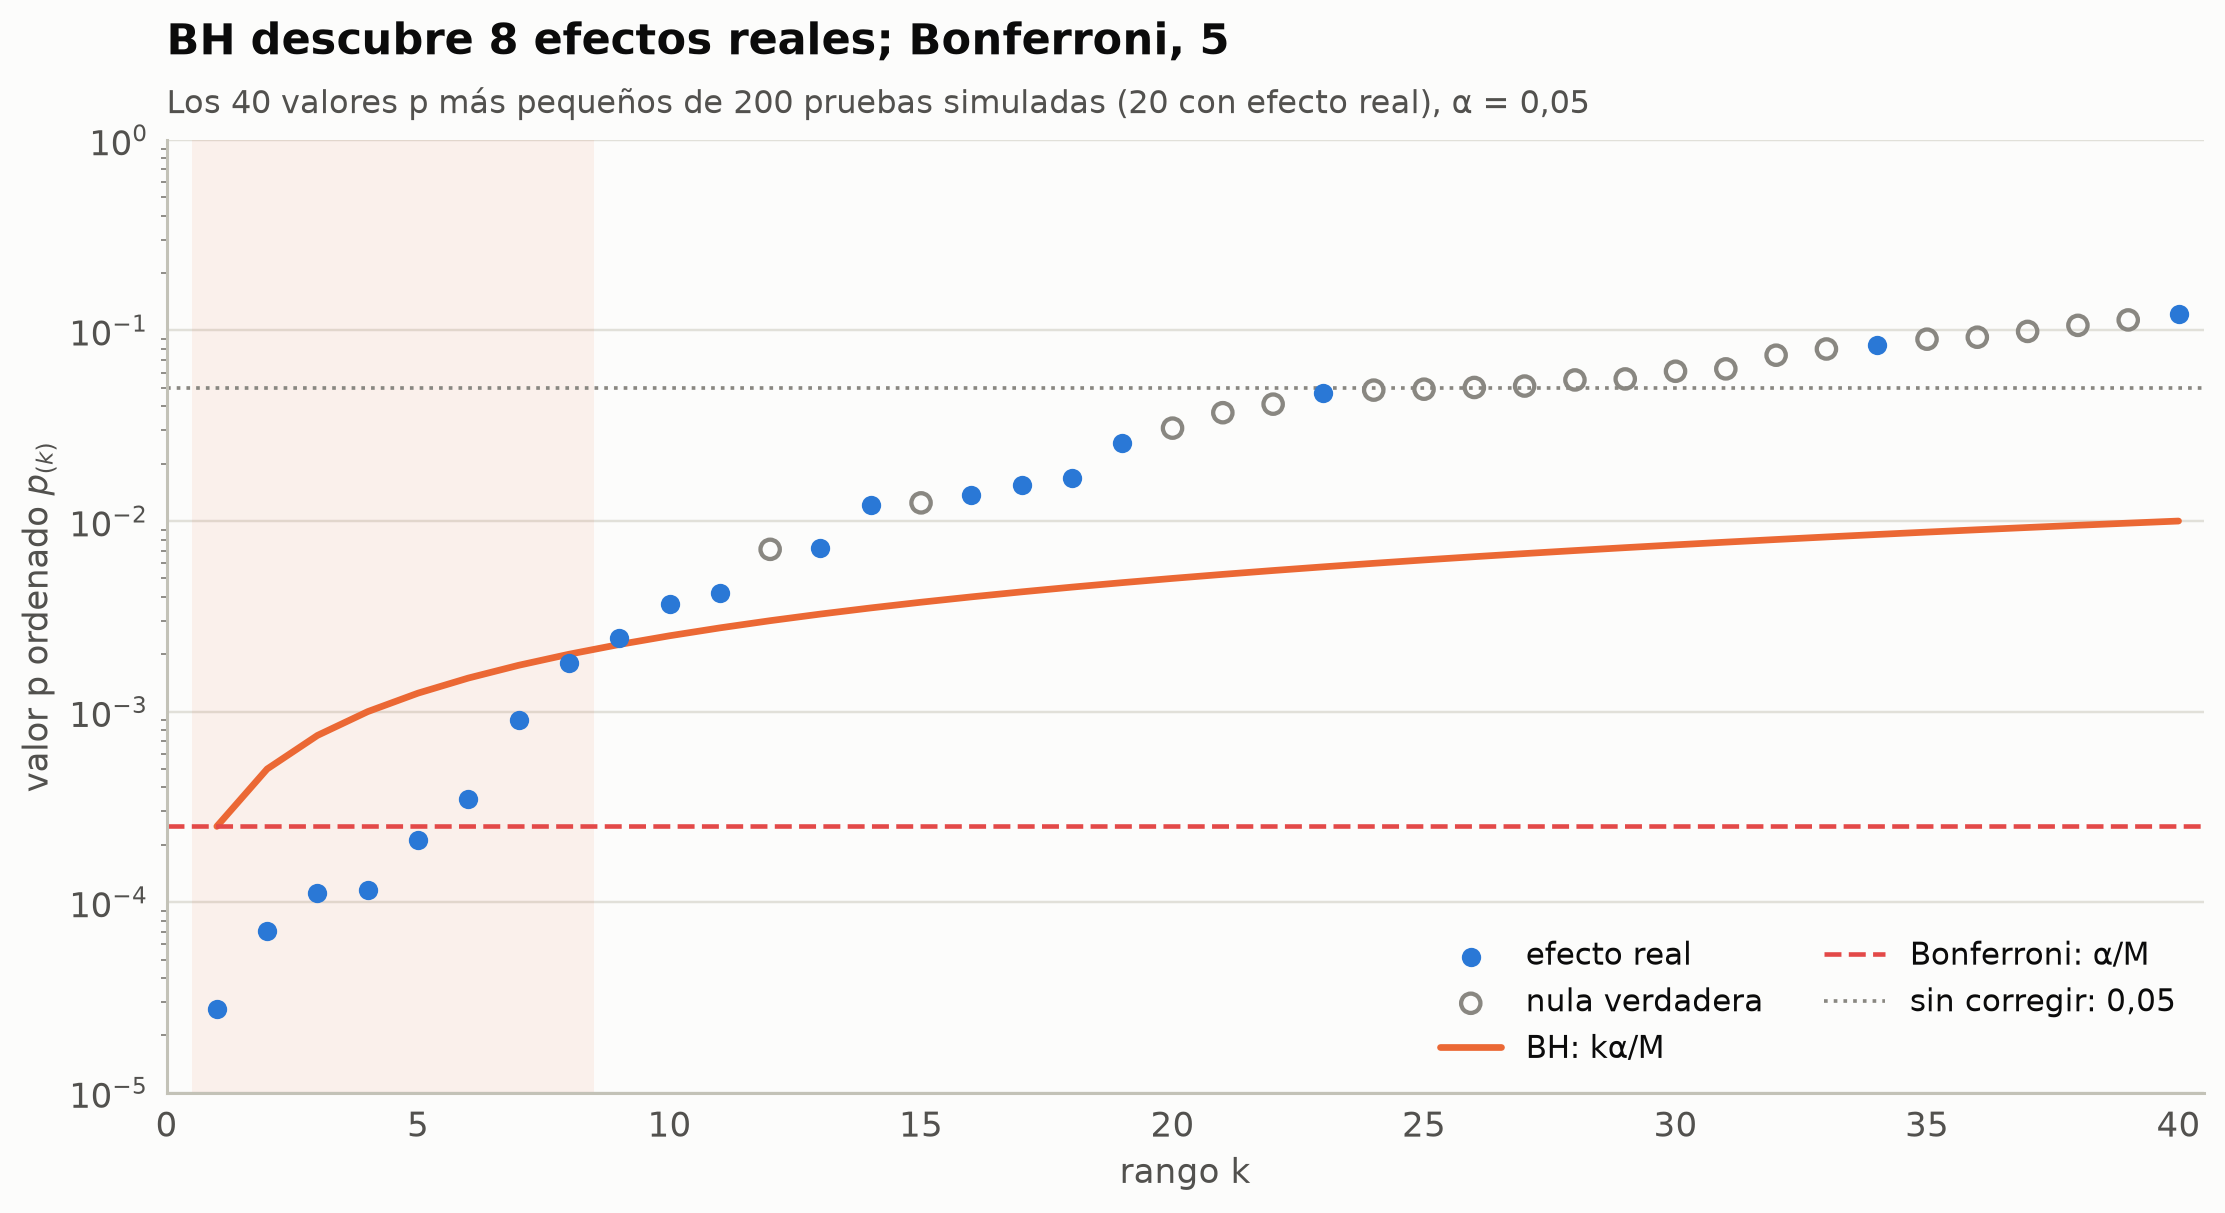

In [26]:
rng_bh = book_rng("bonferroni_bh")
m_t, m1, alpha = 200, 20, 0.05
zt = np.r_[rng_bh.normal(3.3, 1, m1), rng_bh.normal(0, 1, m_t - m1)]
pt = 2 * stats.norm.sf(np.abs(zt))
is_real = np.r_[np.ones(m1, bool), np.zeros(m_t - m1, bool)]
o = np.argsort(pt); ps, reales = pt[o], is_real[o]
kt = np.arange(1, m_t + 1)
bh_ok = np.where(ps <= alpha * kt / m_t)[0]
k_bh = bh_ok.max() + 1 if len(bh_ok) else 0
n_bon = int(np.sum(ps <= alpha / m_t)); n_raw = int(np.sum(ps < 0.05))
print(f"Bonferroni = {n_bon} (falsos {np.sum(~reales[:n_bon])})  [libro: 5 (0)]")
print(f"BH         = {k_bh} (falsos {np.sum(~reales[:k_bh])})  [libro: 8 (0)]")
print(f"p < 0,05   = {n_raw} (falsos {np.sum(~reales[ps < 0.05])})  [libro: 25 (7)]")

fig, ax = plt.subplots(figsize=(10, 5.4))
sel = kt <= 40
ax.scatter(kt[sel & reales], ps[sel & reales], s=40, color=ec.BLUE, zorder=3, label="efecto real")
ax.scatter(kt[sel & ~reales], ps[sel & ~reales], s=40, facecolors="none", edgecolors=ec.MUTED, linewidths=1.4,
           zorder=3, label="nula verdadera")
ax.plot(kt[sel], alpha * kt[sel] / m_t, color=ec.ORANGE, lw=2.2, label="BH: kα/M")
ax.axhline(alpha / m_t, color=ec.RED, ls="--", lw=1.5, label="Bonferroni: α/M")
ax.axhline(0.05, color=ec.MUTED, ls=":", lw=1.2, label="sin corregir: 0,05")
ax.axvspan(0.5, k_bh + 0.5, color=ec.ORANGE, alpha=0.08)
ax.set_yscale("log"); ax.set_ylim(1e-5, 1); ax.set_xlim(0, 40.5)
ax.set_xlabel("rango k"); ax.set_ylabel("valor p ordenado $p_{(k)}$")
ax.legend(loc="lower right", frameon=False, ncol=2)
ec.title(ax, f"BH descubre {k_bh} efectos reales; Bonferroni, {n_bon}",
         "Los 40 valores p más pequeños de 200 pruebas simuladas (20 con efecto real), α = 0,05")
plt.show()

> 🔎 **Qué observamos.** La recta de BH arranca en el mismo punto que la línea de Bonferroni ($\alpha/M$ para $k=1$) pero
> crece con el rango, y por eso "atrapa" algunos efectos reales más. El umbral sin corregir atrapa muchos más… y siete
> nulas con ellos. La elección no es técnica sino de **propósito**: en un GWAS de descubrimiento que alimentará años de
> trabajo experimental, un falso positivo es caro y se usa el umbral por familia; en un cribado exploratorio que se
> validará después, la FDR es más sensata.

### 🔍 Mueva el umbral

Con el deslizador cambie $\alpha$ y observe cuántos descubrimientos (y cuántos falsos) declara cada criterio sobre las
mismas 200 pruebas del libro.

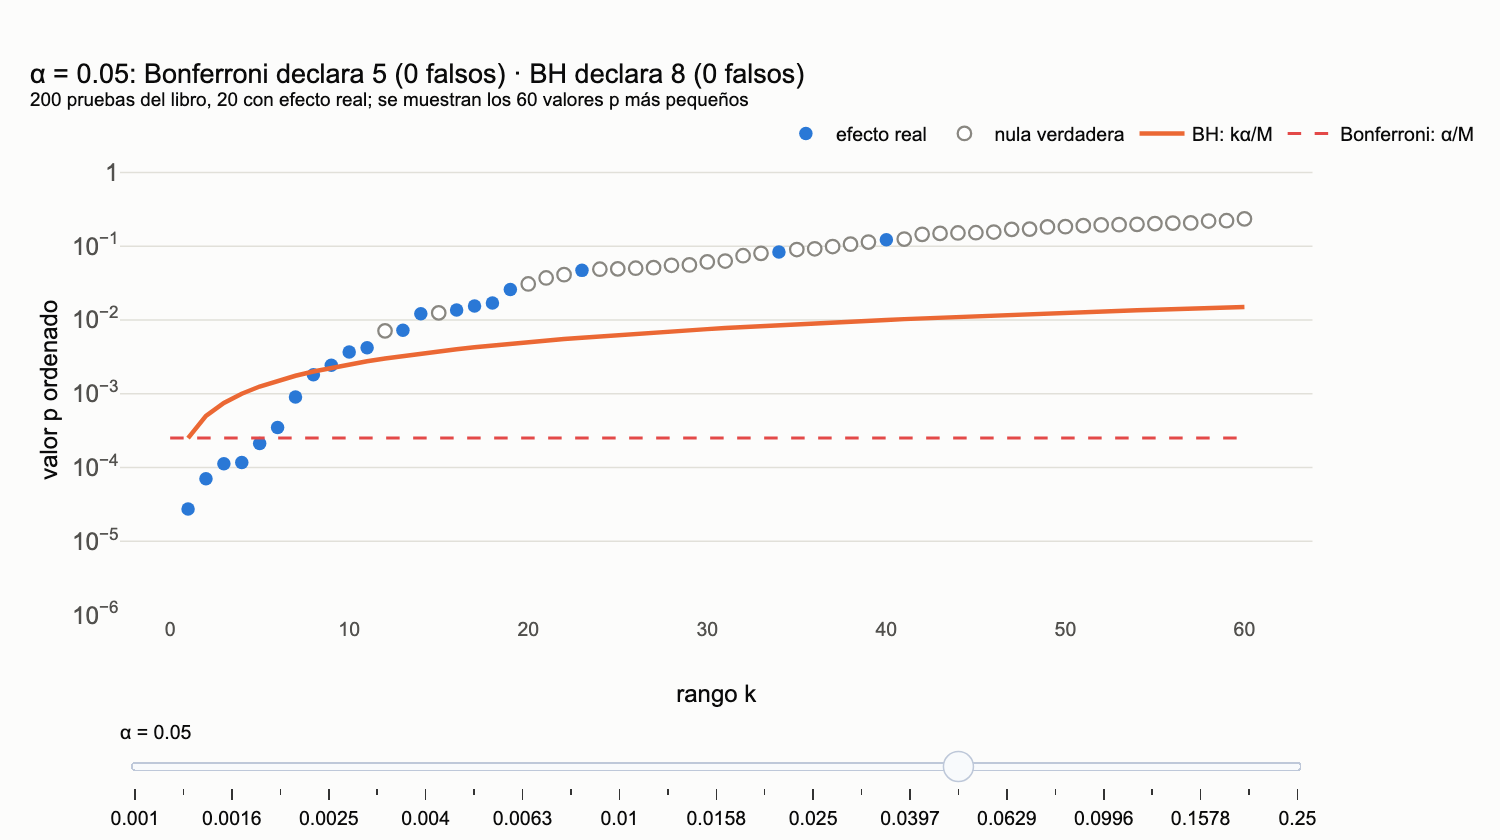

In [27]:
alphas = np.round(np.geomspace(0.001, 0.25, 25), 4)
figs = go.Figure()
hv = [f"rango {k}<br>p = {p:.2e}<br>{'efecto real' if r else 'nula verdadera'}" for k, p, r in zip(kt, ps, reales)]
nshow = 60
figs.add_trace(go.Scatter(x=kt[:nshow][reales[:nshow]], y=ps[:nshow][reales[:nshow]], mode="markers",
                          marker=dict(size=9, color=ec.BLUE), name="efecto real",
                          hovertext=np.array(hv)[:nshow][reales[:nshow]], hoverinfo="text"))
figs.add_trace(go.Scatter(x=kt[:nshow][~reales[:nshow]], y=ps[:nshow][~reales[:nshow]], mode="markers",
                          marker=dict(size=9, color="white", line=dict(color=ec.MUTED, width=1.5)),
                          name="nula verdadera", hovertext=np.array(hv)[:nshow][~reales[:nshow]], hoverinfo="text"))
def counts(a):
    kb = int(np.sum(ps <= a / m_t))
    ok = np.where(ps <= a * kt / m_t)[0]; kh = ok.max() + 1 if len(ok) else 0
    return kb, int(np.sum(~reales[:kb])), kh, int(np.sum(~reales[:kh]))
a0 = 0.05
figs.add_trace(go.Scatter(x=kt[:nshow], y=a0 * kt[:nshow] / m_t, mode="lines", line=dict(color=ec.ORANGE, width=3),
                          name="BH: kα/M", hoverinfo="skip"))
figs.add_trace(go.Scatter(x=[0, nshow], y=[a0 / m_t] * 2, mode="lines", line=dict(color=ec.RED, dash="dash", width=2),
                          name="Bonferroni: α/M", hoverinfo="skip"))
def title_for(a):
    kb, fb, kh, fh = counts(a)
    return (f"α = {a:g}: Bonferroni declara {kb} ({fb} falsos) · BH declara {kh} ({fh} falsos)"
            "<br><sup>200 pruebas del libro, 20 con efecto real; se muestran los 60 valores p más pequeños</sup>")
steps = []
for a in alphas:
    steps.append(dict(method="update", label=f"{a:g}",
                      args=[{"y": [(a * kt[:nshow] / m_t).tolist(), [a / m_t] * 2]}, {"title.text": title_for(a)},
                            [2, 3]]))
figs.update_layout(title=title_for(a0), yaxis_type="log", yaxis_range=[-6, 0.1], yaxis_exponentformat="power", xaxis_title="rango k",
                   yaxis_title="valor p ordenado", height=560, margin=dict(t=110, b=120),
                   legend=dict(yanchor="bottom", y=1.02, x=0.55, orientation="h"),
                   sliders=[dict(active=int(np.argmin(np.abs(alphas - a0))), steps=steps, y=-0.12,
                                 currentvalue=dict(prefix="α = "), pad=dict(t=30))])
figs.show()

> 🔎 **Qué observamos.** Al subir $\alpha$ los dos criterios declaran más, pero BH siempre declara **al menos** tantos como
> Bonferroni, y la proporción de falsos entre los declarados por BH se mantiene baja, del orden de $\alpha M_0/M$. Con
> $\alpha$ muy grande (0,2) BH empieza a colar nulas, como es de esperar: es exactamente lo que promete.

> ✅ **Compruebe su comprensión.** En un GWAS con $M=10^6$ variantes, ¿cuál es el umbral de BH para la variante de
> rango 1? ¿Y cuál es el de Bonferroni? ¿Por qué BH casi no ayuda en un GWAS con pocas señales?

## 7. Gráficos QQ y Manhattan: construirlos y leerlos

El resultado de un GWAS se resume en dos gráficos. El **gráfico Manhattan** sitúa cada variante según su posición en
el genoma y su $-\log_{10}p$: las asociaciones aparecen como **rascacielos** sobre un horizonte de ruido (de ahí el
nombre). El **gráfico QQ** compara la distribución completa de los valores $p$ con la esperada bajo la nula y sirve de
**diagnóstico**: una desviación temprana indica inflación; una desviación sólo en la cola, señales reales.

### El Manhattan del libro

El libro simula un GWAS de 89 999 variantes en los 22 autosomas, con LD por bloques (cada estadístico $z$ se correlaciona
con su vecino) y señales de distinta intensidad en ocho cromosomas. Reproducimos su figura con el mismo generador.
Cifras del libro: $\lambda_{GC}=1{,}009$; **35** variantes con $p<5\times10^{-8}$ en **6** cromosomas (2, 3, 6, 9, 11 y
16); pico más alto $p=1{,}42\times10^{-32}$ en el cromosoma 6; señales en los cromosomas 12 y 19 sólo sugestivas
($p\approx10^{-6}$).

In [28]:
rng_m = book_rng("manhattan")
chrlen = np.array([248, 242, 198, 190, 181, 171, 159, 145, 138, 134, 135,
                   133, 114, 107, 102, 90, 83, 80, 59, 64, 47, 51], float)     # Mb (aprox. GRCh37)
Mtot = 90000
nper_chr = np.round(chrlen / chrlen.sum() * Mtot).astype(int)
# cromosoma: (posición relativa del pico, intensidad media mu del estadístico z)
senales = {2: (0.35, 8.8), 6: (0.18, 12.5), 9: (0.62, 7.1), 11: (0.40, 6.2),
           12: (0.55, 5.1), 16: (0.30, 7.8), 19: (0.45, 5.5), 3: (0.7, 4.8)}
z_all, chr_all, pos_all = [], [], []
for c in range(1, 23):
    m = nper_chr[c - 1]
    # correlación con el vecino: 12 % de "saltos" (recombinación) y 88 % de LD fuerte
    rho = np.where(rng_m.random(m) < 0.12, rng_m.uniform(0, 0.3, m), rng_m.uniform(0.85, 0.995, m))
    z = np.empty(m)
    z[0] = rng_m.normal()
    eps = rng_m.normal(size=m)
    for j in range(1, m):
        z[j] = rho[j] * z[j - 1] + math.sqrt(1 - rho[j] ** 2) * eps[j]
    if c in senales:
        fpos, mu = senales[c]
        k = int(fpos * m)
        lr = np.cumsum(np.log(np.maximum(rho, 1e-12)))
        z += mu * np.exp(-np.abs(lr - lr[k]))           # la señal se reparte según el LD con la causal
    z_all.append(z); chr_all.append(np.full(m, c))
    pos_all.append(np.sort(rng_m.uniform(0, chrlen[c - 1], m)))
z_all, chr_all, pos_all = map(np.concatenate, (z_all, chr_all, pos_all))
pv_m = 2 * stats.norm.sf(np.abs(z_all))
lp_m = -np.log10(pv_m)
sig_m = pv_m < GW
print(f"M = {len(pv_m)}  λ_GC = {lambda_gc(pv_m):.3f} [libro 1.009]  ·  p < 5e-8: {sig_m.sum()} [35] en los cromosomas "
      f"{sorted(set(chr_all[sig_m].tolist()))} [2, 3, 6, 9, 11, 16]  ·  min p = {pv_m.min():.2e} [1.42e-32]")
for c in (12, 19):
    print(f"   chr{c}: min p = {pv_m[chr_all == c].min():.2e}  (sugestiva, no significativa)")

M = 89999  λ_GC = 1.009 [libro 1.009]  ·  p < 5e-8: 35 [35] en los cromosomas [2, 3, 6, 9, 11, 16] [2, 3, 6, 9, 11, 16]  ·  min p = 1.42e-32 [1.42e-32]
   chr12: min p = 1.35e-06  (sugestiva, no significativa)
   chr19: min p = 9.84e-07  (sugestiva, no significativa)


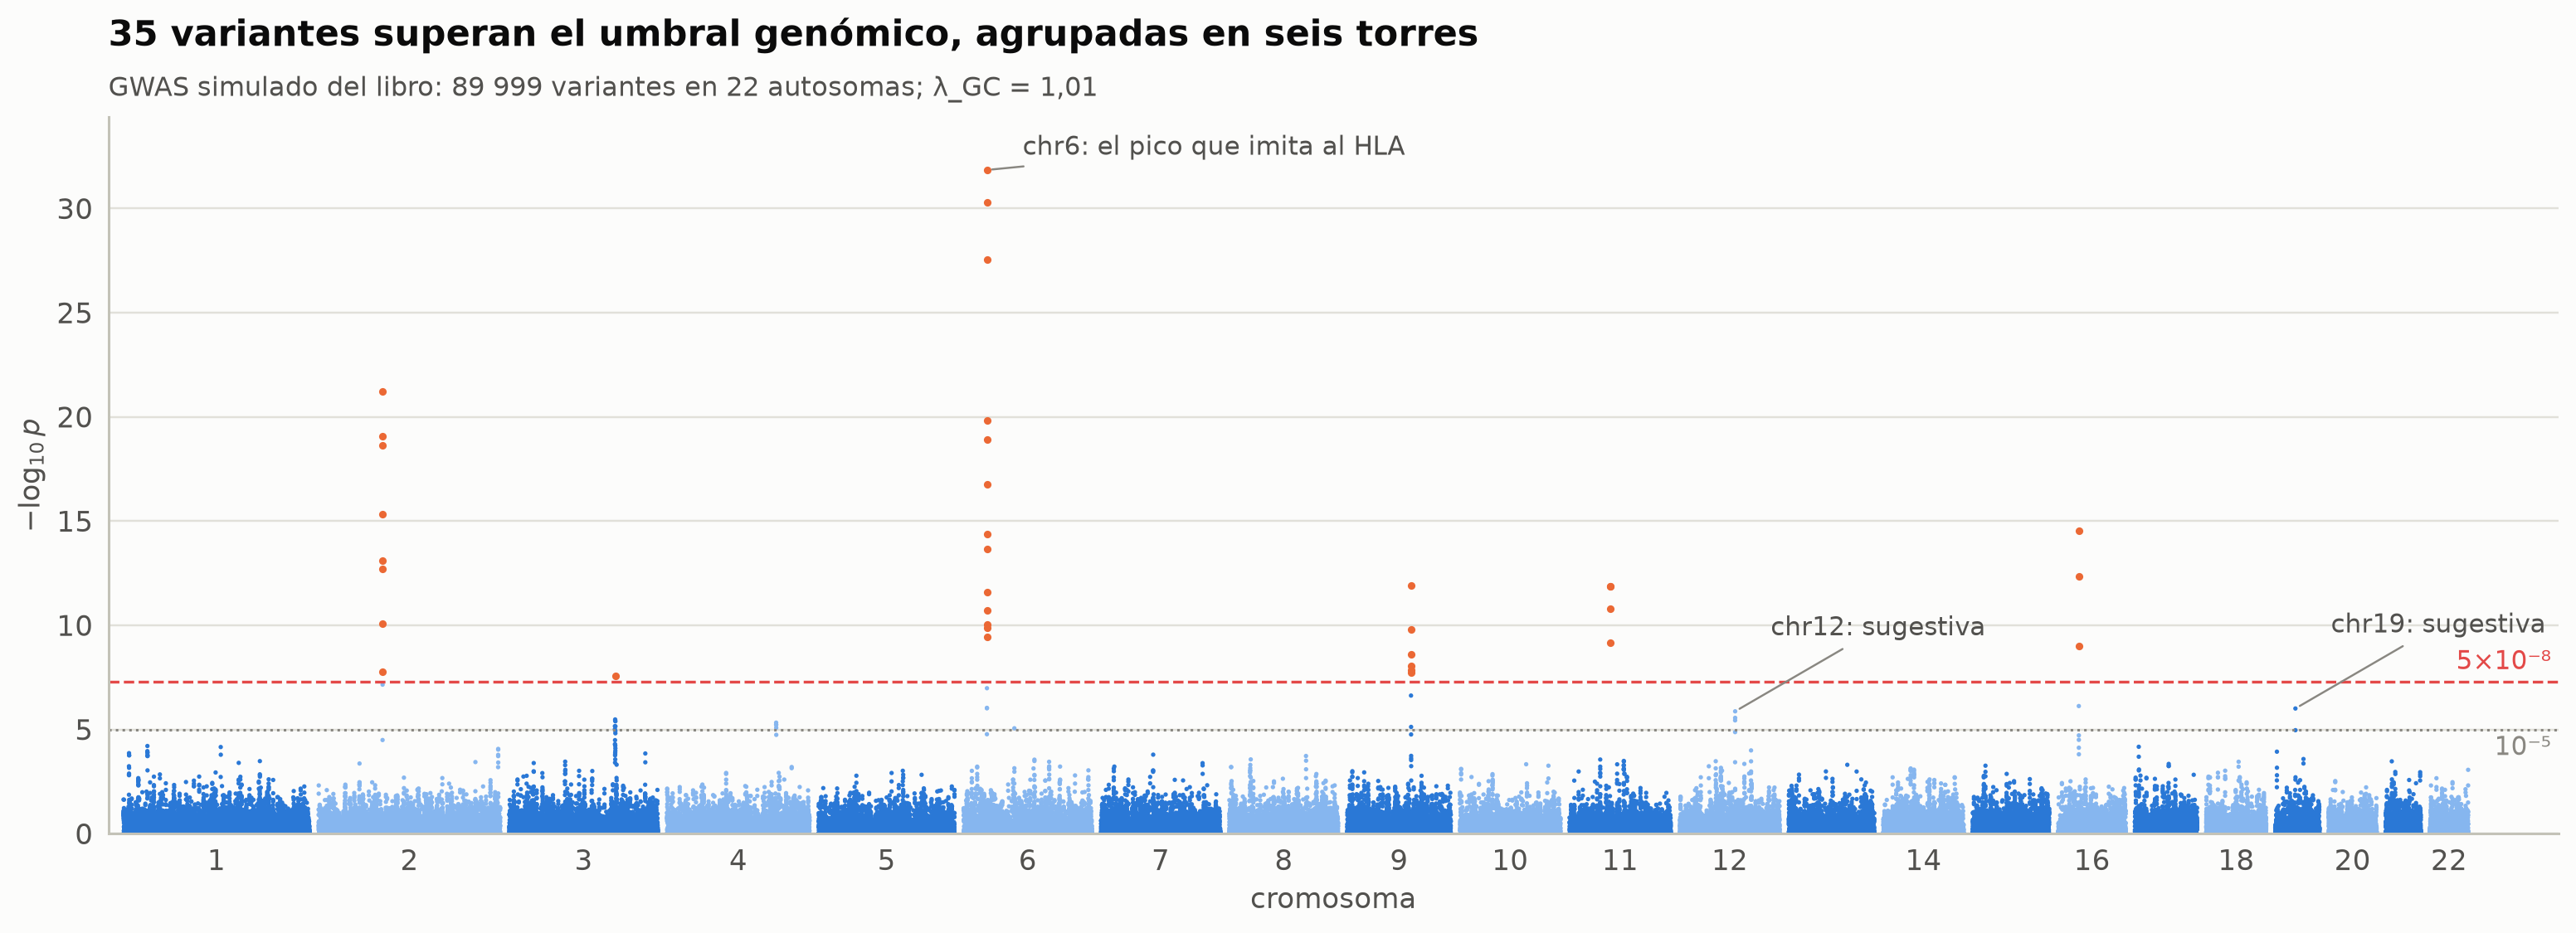

In [29]:
off = np.r_[0, np.cumsum(chrlen)[:-1]] + np.arange(22) * 12
xg = pos_all + off[chr_all - 1]
fig, ax = plt.subplots(figsize=(14, 5))
cols = np.where(chr_all % 2 == 1, ec.BLUE, ec.SEQ_BLUE[3])
ax.scatter(xg[~sig_m], lp_m[~sig_m], s=3, c=cols[~sig_m], lw=0, rasterized=True)
ax.scatter(xg[sig_m], lp_m[sig_m], s=9, c=ec.ORANGE, lw=0)
ax.axhline(-math.log10(GW), color=ec.RED, lw=1.1, ls="--")
ax.axhline(5, color=ec.MUTED, lw=1, ls=":")
ax.text(xg.max() + 110, -math.log10(GW) + 0.3, "5×10⁻⁸", fontsize=10, color=ec.RED, va="bottom", ha="right")
ax.text(xg.max() + 110, 4.7, "10⁻⁵", fontsize=10, color=ec.MUTED, va="top", ha="right")
mids = off + chrlen / 2
ax.set_xticks(mids, [str(i) if i <= 12 or i % 2 == 0 else "" for i in range(1, 23)])
ax.tick_params(axis="x", length=0); ax.grid(axis="x", visible=False)
ax.set_xlim(-20, xg.max() + 120); ax.set_ylim(0, lp_m.max() * 1.08)
ax.set_xlabel("cromosoma"); ax.set_ylabel("$-\\log_{10} p$")
for c in (6, 12, 19):
    i = np.argmax(np.where(chr_all == c, lp_m, -1))
    lab = {6: "chr6: el pico que imita al HLA", 12: "chr12: sugestiva", 19: "chr19: sugestiva"}[c]
    ax.annotate(lab, (xg[i], lp_m[i]), xytext=(14, 6 if c == 6 else 30), textcoords="offset points", fontsize=10,
                color=ec.INK_2, arrowprops=dict(arrowstyle="-", color=ec.MUTED, lw=0.8))
ec.title(ax, f"{sig_m.sum()} variantes superan el umbral genómico, agrupadas en seis torres",
         f"GWAS simulado del libro: {len(pv_m):,} variantes en 22 autosomas; λ_GC = {lambda_gc(pv_m):.2f}".replace(",", " ").replace(".", ","))
plt.show()

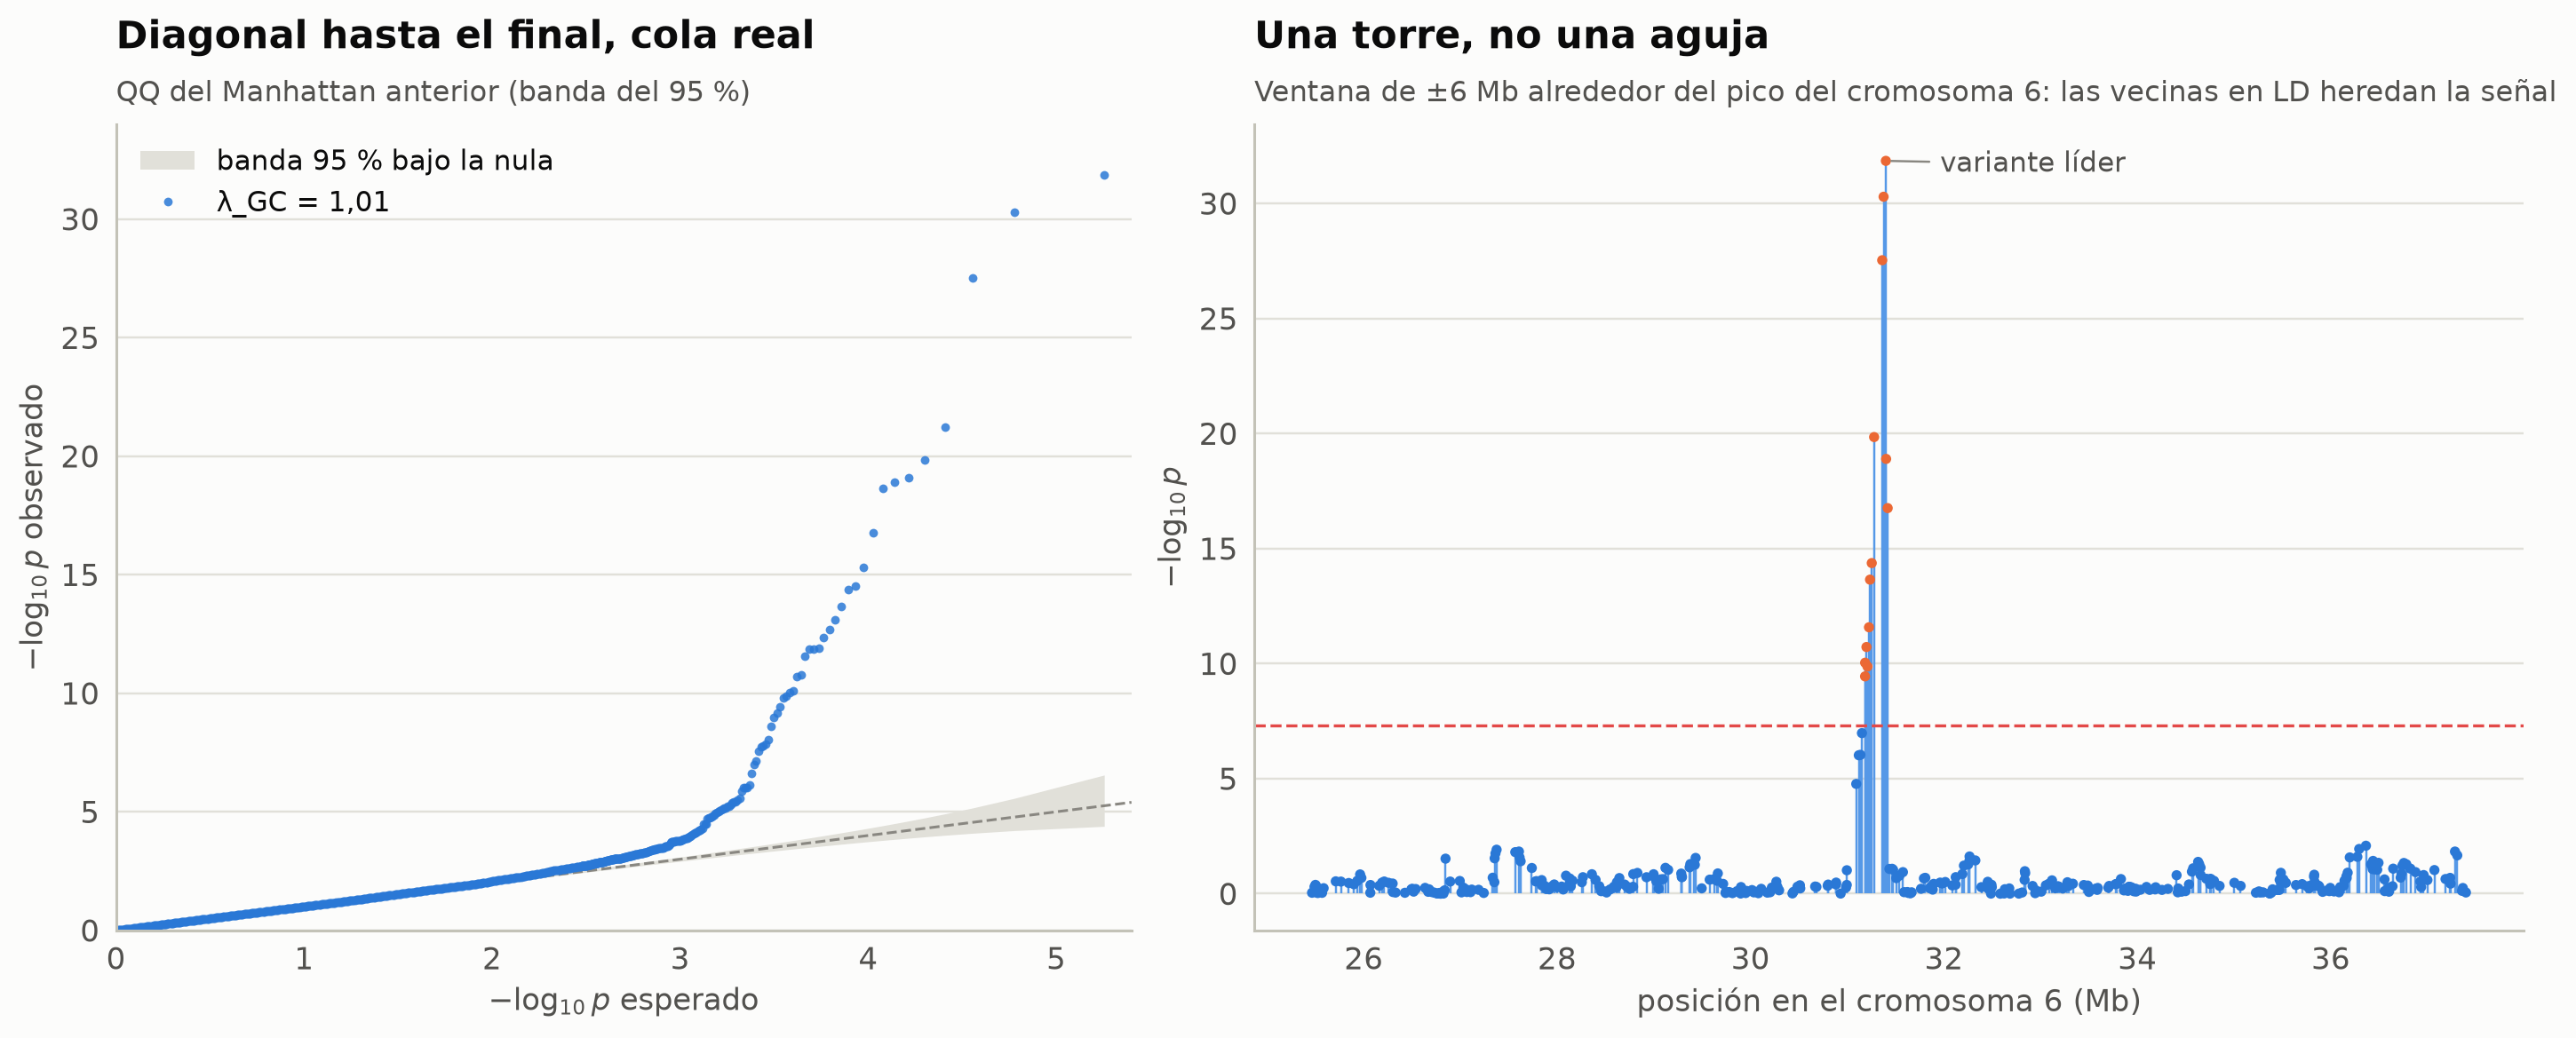

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2), gridspec_kw={"width_ratios": [1, 1.25]})
draw_qq(axes[0], [(pv_m, ec.BLUE, f"λ_GC = {lambda_gc(pv_m):.2f}".replace(".", ","))], len(pv_m), xmax=5.4, ymax=34)
ec.title(axes[0], "Diagonal hasta el final, cola real", "QQ del Manhattan anterior (banda del 95 %)")
ax = axes[1]
c6 = chr_all == 6
i6 = np.argmax(np.where(c6, lp_m, -1))
win = c6 & (np.abs(pos_all - pos_all[i6]) < 6)
ax.vlines(pos_all[win], 0, lp_m[win], color=ec.SEQ_BLUE[5], lw=0.8)
ax.scatter(pos_all[win], lp_m[win], s=14, color=np.where(sig_m[win], ec.ORANGE, ec.BLUE), zorder=3, lw=0)
ax.axhline(-math.log10(GW), color=ec.RED, lw=1.1, ls="--")
ax.annotate("variante líder", (pos_all[i6], lp_m[i6]), xytext=(20, -4), textcoords="offset points", fontsize=10,
            color=ec.INK_2, arrowprops=dict(arrowstyle="-", color=ec.MUTED, lw=0.8))
ax.set_xlabel("posición en el cromosoma 6 (Mb)"); ax.set_ylabel("$-\\log_{10} p$")
ec.title(ax, "Una torre, no una aguja", "Ventana de ±6 Mb alrededor del pico del cromosoma 6: las vecinas en LD heredan la señal")
plt.show()

> 🔎 **Qué observamos.** En el QQ los puntos siguen la diagonal casi hasta el final y sólo se despegan en la cola, donde
> están las verdaderas asociaciones: es la firma de un estudio **bien calibrado** ($\lambda_{GC}\approx1{,}01$), lo
> contrario de la estratificación de las secciones 4 y 5. El acercamiento al cromosoma 6 muestra por qué cada pico es
> una **torre**: las variantes vecinas en LD con la causal heredan una parte de su señal, proporcional a su correlación.
> Las señales de los cromosomas 12 y 19 existen, pero con este tamaño de muestra quedan en la zona **sugestiva**: el
> estudio no tiene potencia para declararlas (sección 3).

### Tres advertencias al leer un Manhattan

1. **La variante líder no es necesariamente la causal.** Es sólo la que mejor etiqueta a la causal **en esta muestra**.
   Lo vimos con datos reales: en la torre espuria de la lactasa, la variante con el menor valor $p$ no tenía por qué ser
   rs4988235. Identificar la variante causal requiere **mapeo fino** estadístico y funcional.
2. **El gen más cercano no es necesariamente el gen efector.** El locus se nombra a menudo por el gen más cercano, pero
   la variante causal puede actuar sobre un gen a cientos de kilobases, a través de un elemento regulador. (El propio
   rs4988235 está en un intrón de *MCM6* y regula a *LCT*, el gen vecino.)
3. **Una aguja aislada es sospechosa.** Un pico formado por una única variante, sin vecinas que la acompañen, suele ser
   un artefacto de genotipado (como el SNP con casi todos heterocigotos que eliminamos en el control de calidad).

### Lo mismo con PLINK 2, en la terminal

En un estudio real, con cientos de miles de personas, todo esto se hace con **PLINK** (Purcell *et al.*, 2007), cuya
segunda generación (Chang *et al.*, 2015) trabaja con operaciones a nivel de bits y paralelismo. El flujo del libro es:

```bash
# 1. Control de calidad de variantes e individuos
plink2 --bfile crudo --geno 0.02 --mind 0.02 --maf 0.01 \
       --hwe 1e-6 --make-bed --out qc
# 2. Podar por LD y calcular 10 componentes principales
plink2 --bfile qc --indep-pairwise 200 50 0.2 --out podado
plink2 --bfile qc --extract podado.prune.in --pca 10 --out pcs
# 3. Asociación con las PCs como covariables
plink2 --bfile qc --pheno fenotipo.txt --covar pcs.eigenvec \
       --glm hide-covar --out gwas
```

Cada paso tiene su equivalente en esta clase: `--hwe` es nuestro filtro de Hardy-Weinberg (¡por población!),
`--pca` es `pca_genotipos` y `--glm` con `--covar` es `gwas_lineal(y, G, PCs)`.

> ✅ **Compruebe su comprensión.** En un Manhattan usted ve una variante aislada con $p=10^{-12}$ y ninguna vecina por
> encima de $-\log_{10}p=2$. ¿Qué comprobaría antes de celebrarlo?

## 8. 🧪 Lo que los GWAS encontraron: la diabetes tipo 2 en el GWAS Catalog

Los resultados publicados se reúnen en el **GWAS Catalog**, mantenido por el NHGRI y el EBI, que recopila cientos de
miles de asociaciones curadas a partir de miles de publicaciones y ofrece además un repositorio para depositar
estadísticas resumidas completas (Sollis *et al.*, 2023). Tiene una API REST (versión 2) que responde en JSON, como las
que usamos en la Lección 2.2. Haremos tres preguntas:

1. ¿Cuántas asociaciones con la **diabetes tipo 2** (término MONDO_0005148) hay en el catálogo, y cuál es la más fuerte?
2. ¿Qué dice la ficha del estudio **GCST009379** (Mahajan *et al.*, 2018), un metaanálisis europeo de gran tamaño?
3. ¿Qué asociaciones reportó ese estudio?

Como siempre en el curso, primero buscamos una copia guardada en el repositorio (`data/api_cache/`); si no está,
preguntamos a la API en vivo; y si la API no responde, descargamos la copia del curso desde GitHub.

In [31]:
GWAS_API = "https://www.ebi.ac.uk/gwas/rest/api/v2"

def gwas_catalog(endpoint, params, cache_name):
    """1) copia del curso en ../data/api_cache; 2) API en vivo; 3) copia del curso en GitHub."""
    local = os.path.join("..", "data", "api_cache", cache_name)
    if os.path.exists(local):
        with open(local) as fh:
            return json.load(fh), "copia local del curso"
    try:
        r = requests.get(f"{GWAS_API}/{endpoint}", params=params, timeout=60)
        r.raise_for_status()
        return r.json(), "API en vivo"
    except Exception as err:
        print(f"La API no respondió ({err}); uso la copia del curso")
        r = requests.get(f"{RAW}/data/api_cache/{cache_name}", timeout=60)
        r.raise_for_status()
        return r.json(), "copia del curso en GitHub"

top, src1 = gwas_catalog("associations", {"efo_trait": "type 2 diabetes mellitus", "size": 1,
                                          "sort": "p_value", "direction": "asc"},
                         "gwascatalog_associations_t2d_top1.json")
study, src2 = gwas_catalog("studies/GCST009379", {}, "gwascatalog_study_GCST009379.json")
assoc, src3 = gwas_catalog("associations", {"accession_id": "GCST009379", "size": 500},
                           "gwascatalog_associations_GCST009379.json")
t = top["_embedded"]["associations"][0]
print(f"[{src1}] Asociaciones con la diabetes tipo 2 en el catálogo: {top['page']['totalElements']:,}".replace(",", " "))
print(f"   la más fuerte: {t['snp_effect_allele'][0]} en {', '.join(t['mapped_genes'])} · "
      f"p = {t['pvalue_mantissa']}×10^{t['pvalue_exponent']} · {t['first_author']} (PMID {t['pubmed_id']})")
print(f"[{src2}] GCST009379: {study['initial_sample_size']} · {study['platforms']}")
print(f"[{src3}] Asociaciones reportadas por GCST009379: {assoc['page']['totalElements']}")
print("Un registro, tal como llega:", {k: assoc["_embedded"]["associations"][0][k]
                                       for k in ("snp_effect_allele", "locations", "mapped_genes", "pvalue_mantissa",
                                                 "pvalue_exponent", "p_value", "or_value", "range", "risk_frequency")})

[copia local del curso] Asociaciones con la diabetes tipo 2 en el catálogo: 8 864
   la más fuerte: rs7903146-T en TCF7L2 · p = 3×10^-1315 · Suzuki K (PMID 38374256)
[copia local del curso] GCST009379: 74,124 European ancestry cases, 824,006 European ancestry controls · Affymetrix,Illumina [~ 27000000] (imputed)
[copia local del curso] Asociaciones reportadas por GCST009379: 383
Un registro, tal como llega: {'snp_effect_allele': ['rs112915006-G'], 'locations': ['22:50166267'], 'mapped_genes': ['MOV10L1', 'PANX2'], 'pvalue_mantissa': 1, 'pvalue_exponent': -6, 'p_value': 1e-06, 'or_value': '1.08', 'range': '[1.05-1.11]', 'risk_frequency': '0.0512'}


> 🔎 **Qué observamos.** Fíjese en el campo `p_value` de la asociación más fuerte del catálogo (y de muchas de este
> estudio): vale **0.0**. No es que $p$ sea cero: es que $10^{-447}$ (o $10^{-1315}$) es más pequeño que el menor número
> que un `float` puede representar (≈ $10^{-308}$) y se redondea a cero. Por eso el catálogo guarda aparte la mantisa y
> el exponente, y nosotros calcularemos siempre $-\log_{10}p = -(\log_{10}\text{mantisa} + \text{exponente})$. Observe
> también que los campos numéricos (`or_value`, `risk_frequency`) llegan como texto y a veces faltan: hay que
> convertirlos con cuidado.

In [32]:
def to_float(v):
    try:
        return float(v)
    except (TypeError, ValueError):
        return np.nan

rows = []
for a in assoc["_embedded"]["associations"]:
    if not a["locations"]:
        continue                                            # sin coordenadas en GRCh38: no se puede dibujar
    chrom, pos = a["locations"][0].split(":")
    if not chrom.isdigit():
        continue
    rows.append({"snp": a["snp_effect_allele"][0], "chrom": int(chrom), "pos": int(pos),
                 "genes": ", ".join(a["mapped_genes"][:3]) or "—",
                 "mlog10p": -(math.log10(a["pvalue_mantissa"]) + a["pvalue_exponent"]),
                 "p_txt": f"{a['pvalue_mantissa']}×10^{a['pvalue_exponent']}",
                 "OR": to_float(a.get("or_value")), "ci": a.get("range", ""),
                 "raf": to_float(a.get("risk_frequency"))})
t2d = pd.DataFrame(rows)
print(f"{len(t2d)} asociaciones con coordenadas · {t2d.chrom.nunique()} cromosomas · "
      f"con p < 5e-8: {(t2d.mlog10p >= -math.log10(GW)).sum()} · con OR: {t2d.OR.notna().sum()} · "
      f"con frecuencia del alelo de riesgo: {t2d.raf.notna().sum()}")
display(t2d.sort_values("mlog10p", ascending=False).head(8)[["snp", "chrom", "pos", "genes", "p_txt", "OR", "ci", "raf"]])

382 asociaciones con coordenadas · 21 cromosomas · con p < 5e-8: 287 · con OR: 382 · con frecuencia del alelo de riesgo: 382


,snp,chrom,pos,genes,p_txt,OR,ci,raf
170,rs7903146-T,10,112998590,TCF7L2,6×10^-447,1.37,[1.35-1.39],0.2950
201,rs10811660-G,9,22134069,CDKN2B-AS1,1×10^-115,1.27,[1.24-1.29],0.8282
259,rs7756992-G,6,20679478,CDKAL1,2×10^-88,1.15,[1.13-1.17],0.2735
65,rs1421085-C,16,53767042,FTO,3×10^-84,1.13,[1.12-1.15],0.4150
126,rs76895963-T,12,4275678,"CCND2, CCND2-AS1",1×10^-69,1.62,[1.54-1.71],0.9802
314,rs6780171-A,3,185785668,IGF2BP2,9×10^-56,1.14,[1.12-1.16],0.3138
215,rs3802177-G,8,117172786,SLC30A8,1×10^-55,1.11,[1.10-1.13],0.6851
154,rs2237895-C,11,2835964,KCNQ1,6×10^-52,1.12,[1.11-1.14],0.4260


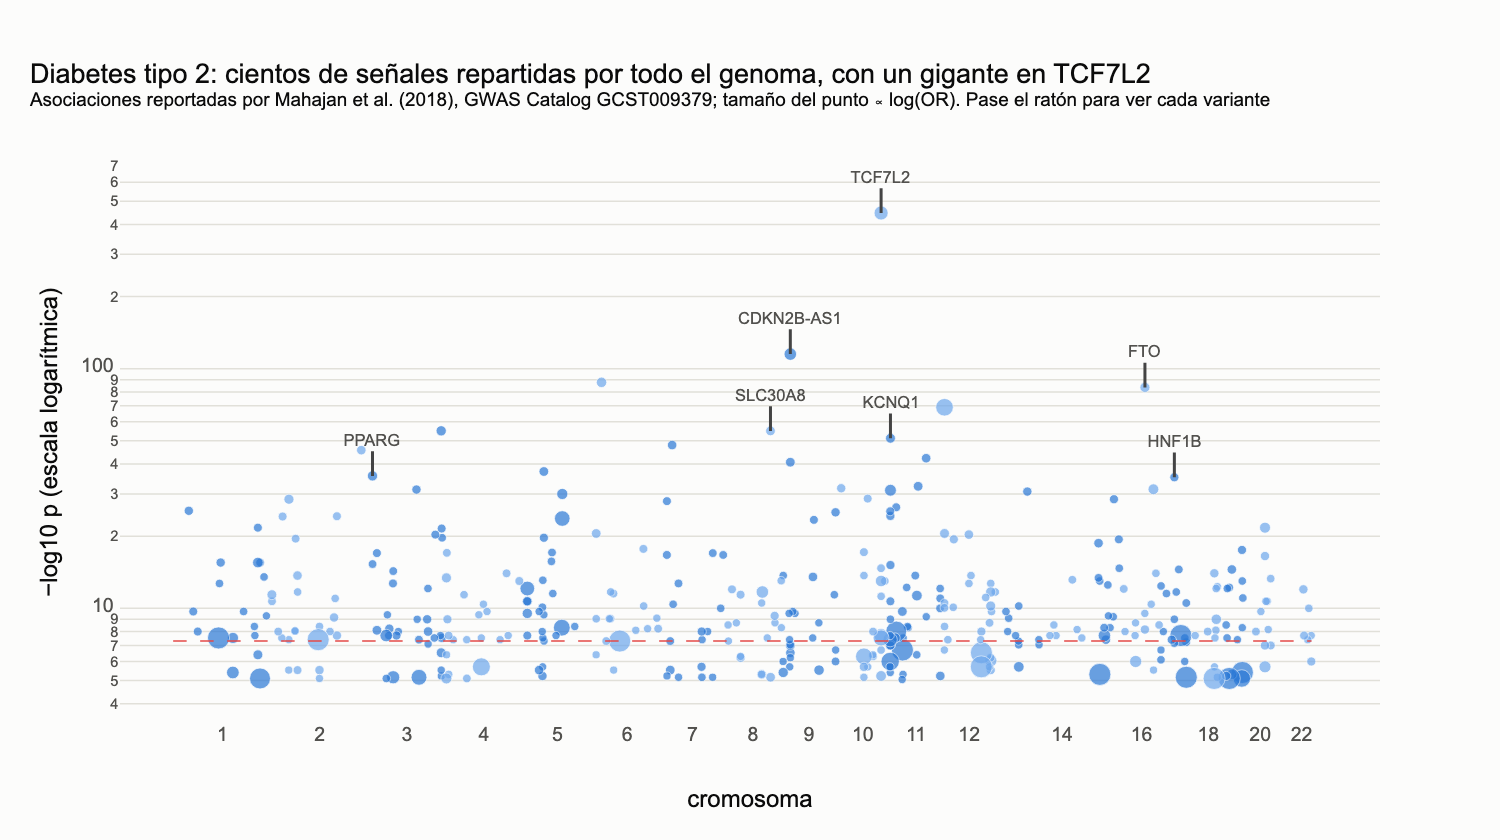

In [33]:
# Manhattan de las asociaciones reportadas (GRCh38)
CHR_LEN_38 = [248956422, 242193529, 198295559, 190214555, 181538259, 170805979, 159345973, 145138636,
              138394717, 133797422, 135086622, 133275309, 114364328, 107043718, 101991189, 90338345,
              83257441, 80373285, 58617616, 64444167, 46709983, 50818468]
off38 = np.r_[0, np.cumsum(CHR_LEN_38)[:-1]] / 1e6
t2d["x"] = off38[t2d.chrom - 1] + t2d.pos / 1e6
t2d["hover"] = [f"<b>{r.genes}</b> · {r.snp}<br>chr{r.chrom}:{r.pos:,} (GRCh38)<br>p = {r.p_txt}"
                f"<br>OR = {r.OR:.2f} {r.ci}<br>frecuencia del alelo de riesgo = "
                f"{'—' if np.isnan(r.raf) else f'{r.raf:.2f}'}<br>Mahajan et al. 2018 · GCST009379"
                for r in t2d.itertuples()]
figc = go.Figure()
for parity, col in ((1, ec.BLUE), (0, ec.SEQ_BLUE[4])):
    d = t2d[t2d.chrom % 2 == parity]
    figc.add_trace(go.Scatter(x=d.x, y=d.mlog10p, mode="markers", hovertext=d.hover, hoverinfo="text",
                              marker=dict(size=5 + 14 * np.log(d.OR.fillna(1).clip(1, 2)), color=col,
                                          line=dict(color="white", width=0.5)), showlegend=False))
for g in ("TCF7L2", "CDKN2B-AS1", "KCNQ1", "FTO", "SLC30A8", "PPARG", "IRS1", "HNF1B"):
    d = t2d[t2d.genes.str.contains(g)]
    if len(d):
        r = d.loc[d.mlog10p.idxmax()]
        figc.add_annotation(x=r.x, y=math.log10(r.mlog10p), text=g, showarrow=True, arrowhead=0, ax=0, ay=-24,
                            font=dict(size=11, color=ec.INK_2))
figc.add_trace(go.Scatter(x=[0, off38[-1] + CHR_LEN_38[-1] / 1e6], y=[-math.log10(GW)] * 2, mode="lines",
                          line=dict(color=ec.RED, dash="dash", width=1), hoverinfo="skip", showlegend=False))
figc.update_xaxes(tickvals=off38 + np.array(CHR_LEN_38) / 2e6,
                  ticktext=[str(i) if i <= 12 or i % 2 == 0 else "" for i in range(1, 23)],
                  title="cromosoma", showgrid=False, tickangle=0)
figc.update_yaxes(type="log", title="−log10 p (escala logarítmica)", exponentformat="none")
figc.update_layout(height=560, margin=dict(t=110),
                   title="Diabetes tipo 2: cientos de señales repartidas por todo el genoma, con un gigante en TCF7L2"
                         "<br><sup>Asociaciones reportadas por Mahajan et al. (2018), GWAS Catalog GCST009379; "
                         "tamaño del punto ∝ log(OR). Pase el ratón para ver cada variante</sup>")
figc.show()

> 🔎 **Qué observamos.** No es un Manhattan completo (el catálogo sólo guarda las variantes **reportadas**, no los
> millones de SNP probados), pero muestra lo esencial: la diabetes tipo 2 es **altamente poligénica**, con señales en
> casi todos los cromosomas. *TCF7L2*, el locus más fuerte conocido para esta enfermedad, domina con un $-\log_{10}p$ de
> varios cientos; la mayoría de las demás señales tienen OR entre 1,03 y 1,15. Casi todas caen en regiones **no
> codificantes** (Visscher *et al.*, 2017), y los nombres de genes del catálogo son los genes "mapeados" más cercanos:
> recuerde la segunda advertencia de la sección 7. Hay además casi un centenar de asociaciones que **no** alcanzan
> $5\times10^{-8}$ (con $p$ de hasta $10^{-6}$), por debajo de la línea roja: el catálogo incluye señales secundarias o
> condicionales que el artículo reporta con su propio criterio.

### El tamaño del efecto frente a la frecuencia

¿Por qué casi todas las variantes descubiertas son **comunes y de efecto pequeño**? Porque son las únicas que un GWAS
puede ver. En un estudio de casos y controles con $N$ personas y una fracción $\phi$ de casos, la no centralidad de la
prueba aditiva es aproximadamente $2N\phi(1-\phi)\,p(1-p)\,(\ln\mathrm{OR})^2$: la misma estructura que $n q^2$, con la
varianza del genotipo $2p(1-p)$. Para cada frecuencia $p$ hay un OR mínimo detectable con 80 % de potencia al umbral
genómico: una **frontera de detección**.

| Símbolo | Significado |
|---|---|
| $N$, $\phi$ | tamaño total del estudio y fracción de casos |
| $p$ | frecuencia del alelo de riesgo (RAF) |
| $\ln\mathrm{OR}$ | efecto por copia en escala logarítmica ($=\beta_j$ de la regresión logística) |

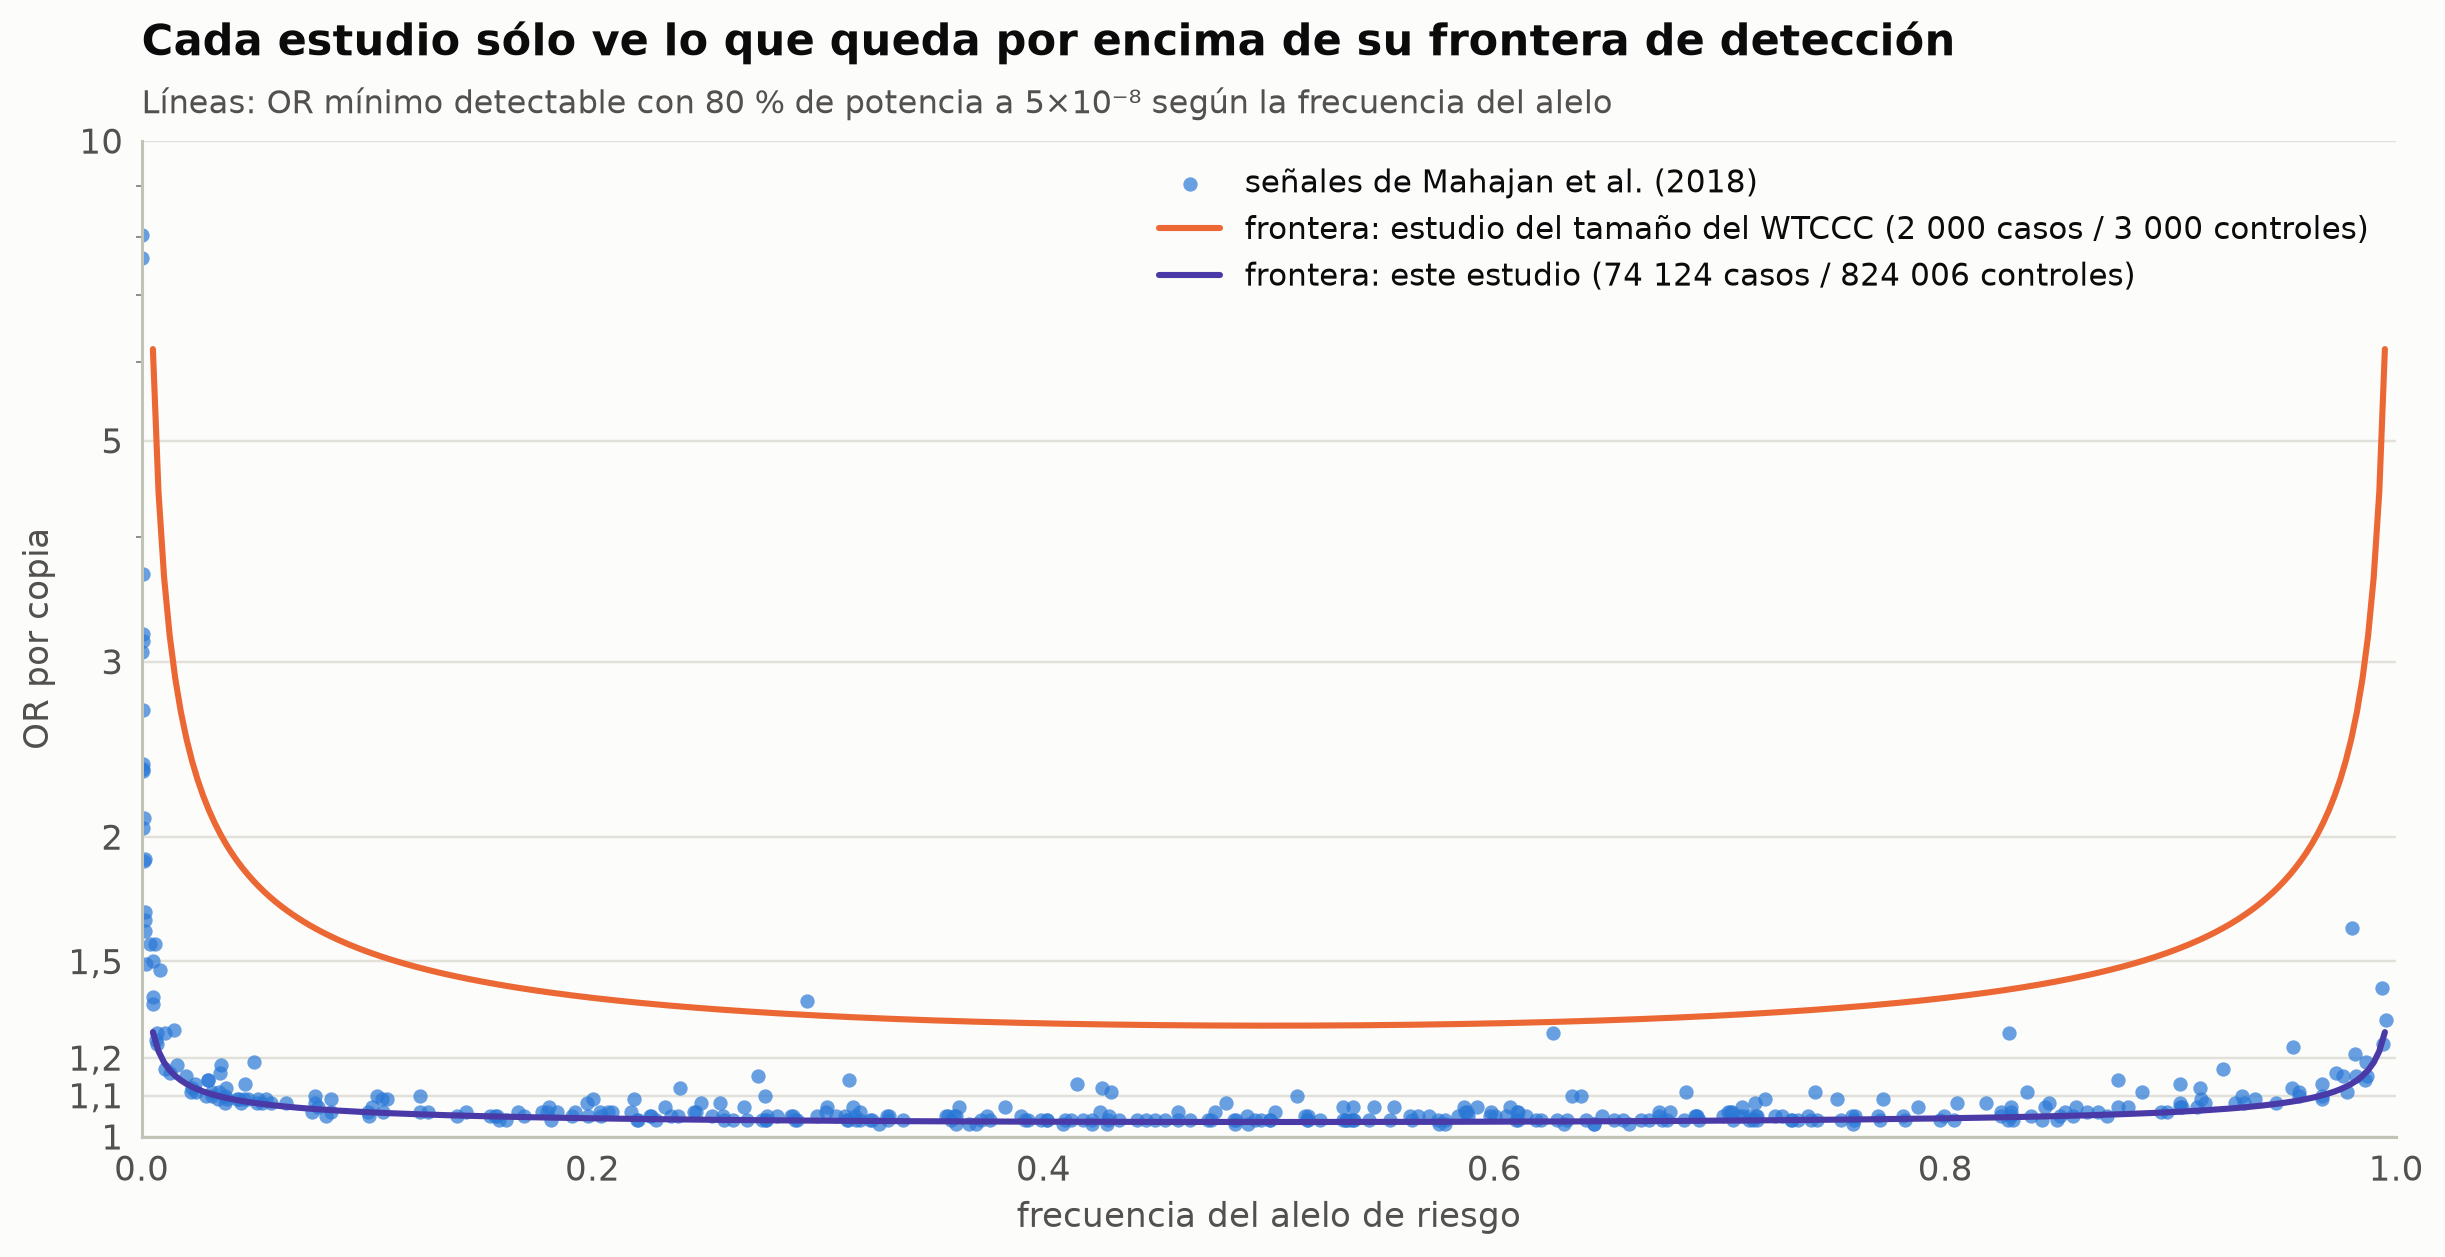

No centralidad para 80 % de potencia a 5e-8: 39.6
Señales con OR ≥ 1,2: 38 de 382; mediana del OR: 1.060


In [34]:
from scipy.optimize import brentq
ncp80 = brentq(lambda x: stats.ncx2.sf(stats.chi2.isf(GW, 1), 1, x) - 0.8, 1, 200)
def or_frontier(p, n_cases, n_ctrl):
    N = n_cases + n_ctrl; phi = n_cases / N
    return np.exp(np.sqrt(ncp80 / (2 * N * phi * (1 - phi) * p * (1 - p))))

d = t2d.dropna(subset=["OR", "raf"]).copy()
flip = d.OR < 1                                            # orientar siempre hacia el alelo que aumenta el riesgo
d.loc[flip, "OR"] = 1 / d.loc[flip, "OR"]; d.loc[flip, "raf"] = 1 - d.loc[flip, "raf"]
pp = np.linspace(0.005, 0.995, 400)
fig, ax = plt.subplots(figsize=(11, 5.6))
ax.scatter(d.raf, d.OR, s=22, color=ec.BLUE, alpha=0.7, lw=0, label="señales de Mahajan et al. (2018)")
for (nca, nco, lab, col) in ((2000, 3000, "estudio del tamaño del WTCCC (2 000 casos / 3 000 controles)", ec.ORANGE),
                             (74124, 824006, "este estudio (74 124 casos / 824 006 controles)", ec.VIOLET)):
    ax.plot(pp, or_frontier(pp, nca, nco), color=col, lw=2, label="frontera: " + lab)
ax.set_yscale("log"); ax.set_ylim(1, max(3.2, d.OR.max() * 1.15)); ax.set_xlim(0, 1)
ax.set_yticks([1, 1.1, 1.2, 1.5, 2, 3, 5, 10], ["1", "1,1", "1,2", "1,5", "2", "3", "5", "10"])
ax.yaxis.set_minor_formatter(plt.NullFormatter())
ax.set_xlabel("frecuencia del alelo de riesgo"); ax.set_ylabel("OR por copia")
ax.legend(loc="upper right", frameon=False)
ec.title(ax, "Cada estudio sólo ve lo que queda por encima de su frontera de detección",
         "Líneas: OR mínimo detectable con 80 % de potencia a 5×10⁻⁸ según la frecuencia del alelo")
plt.show()
print(f"No centralidad para 80 % de potencia a 5e-8: {ncp80:.1f}")
print(f"Señales con OR ≥ 1,2: {(d.OR >= 1.2).sum()} de {len(d)}; mediana del OR: {d.OR.median():.3f}")

> 🔎 **Qué observamos.** Las señales se amontonan justo por encima de la frontera violeta, la del propio estudio: si
> hubiera variantes con OR de 1,02 a frecuencia intermedia, este estudio no las vería, y el siguiente, más grande, sí. Un
> estudio del tamaño del WTCCC sólo podía detectar efectos por encima de la curva naranja; por eso en 2007 se
> encontraron unos pocos loci y hoy cientos. Las pocas variantes **raras** que aparecen (a la izquierda del todo) tienen
> todas OR **grandes**: a esas frecuencias la frontera sube tanto que sólo los efectos fuertes la cruzan, y aun así este
> estudio sólo pudo verlas gracias a una imputación de alta densidad. Las variantes raras de efecto moderado siguen,
> en su mayoría, fuera del alcance de los GWAS basados en chips.

### La heredabilidad faltante

Manolio *et al.* (2009) plantearon el problema de la **heredabilidad faltante**: para la estatura, cuya heredabilidad
estimada en estudios de familias ronda el 80 %, las decenas de loci conocidos entonces explicaban apenas un 5 % de la
varianza. Hagamos la cuenta para la diabetes tipo 2 con las señales del catálogo. En la escala latente de la regresión
logística (una variable continua, no observada, cuya varianza residual es $\pi^2/3$ y que el modelo corta en un umbral
para decidir quién enferma), una variante explica aproximadamente

$$
h^2_j \approx \frac{2p_j(1-p_j)\,(\ln\mathrm{OR}_j)^2}{\pi^2/3},
$$

la misma fórmula que $q_j^2$ con $\beta_j=\ln\mathrm{OR}_j$ y $\sigma_y^2=\pi^2/3$. Es una **aproximación gruesa**, con
tres advertencias. Primera: es varianza en la **escala latente logit**, no «varianza explicada del riesgo» observado
(enfermo o sano), que sería mucho menor. Segunda: para no contar dos veces un mismo locus, conservaremos sólo las
señales con $p<5\times10^{-8}$ y, de cada región de 500 kb, la más significativa (las señales secundarias de un locus
no son independientes de la principal). Tercera: la **maldición del ganador**; las variantes que apenas superan el
umbral lo hicieron, en parte, porque su OR estimado salió por azar más alto que el real, así que la suma tiende a
sobreestimar.

Todas las señales con OR y frecuencia (382): suma ≈ 15.9%
p < 5e-8: 287 señales → 231 loci independientes (una por 500 kb)


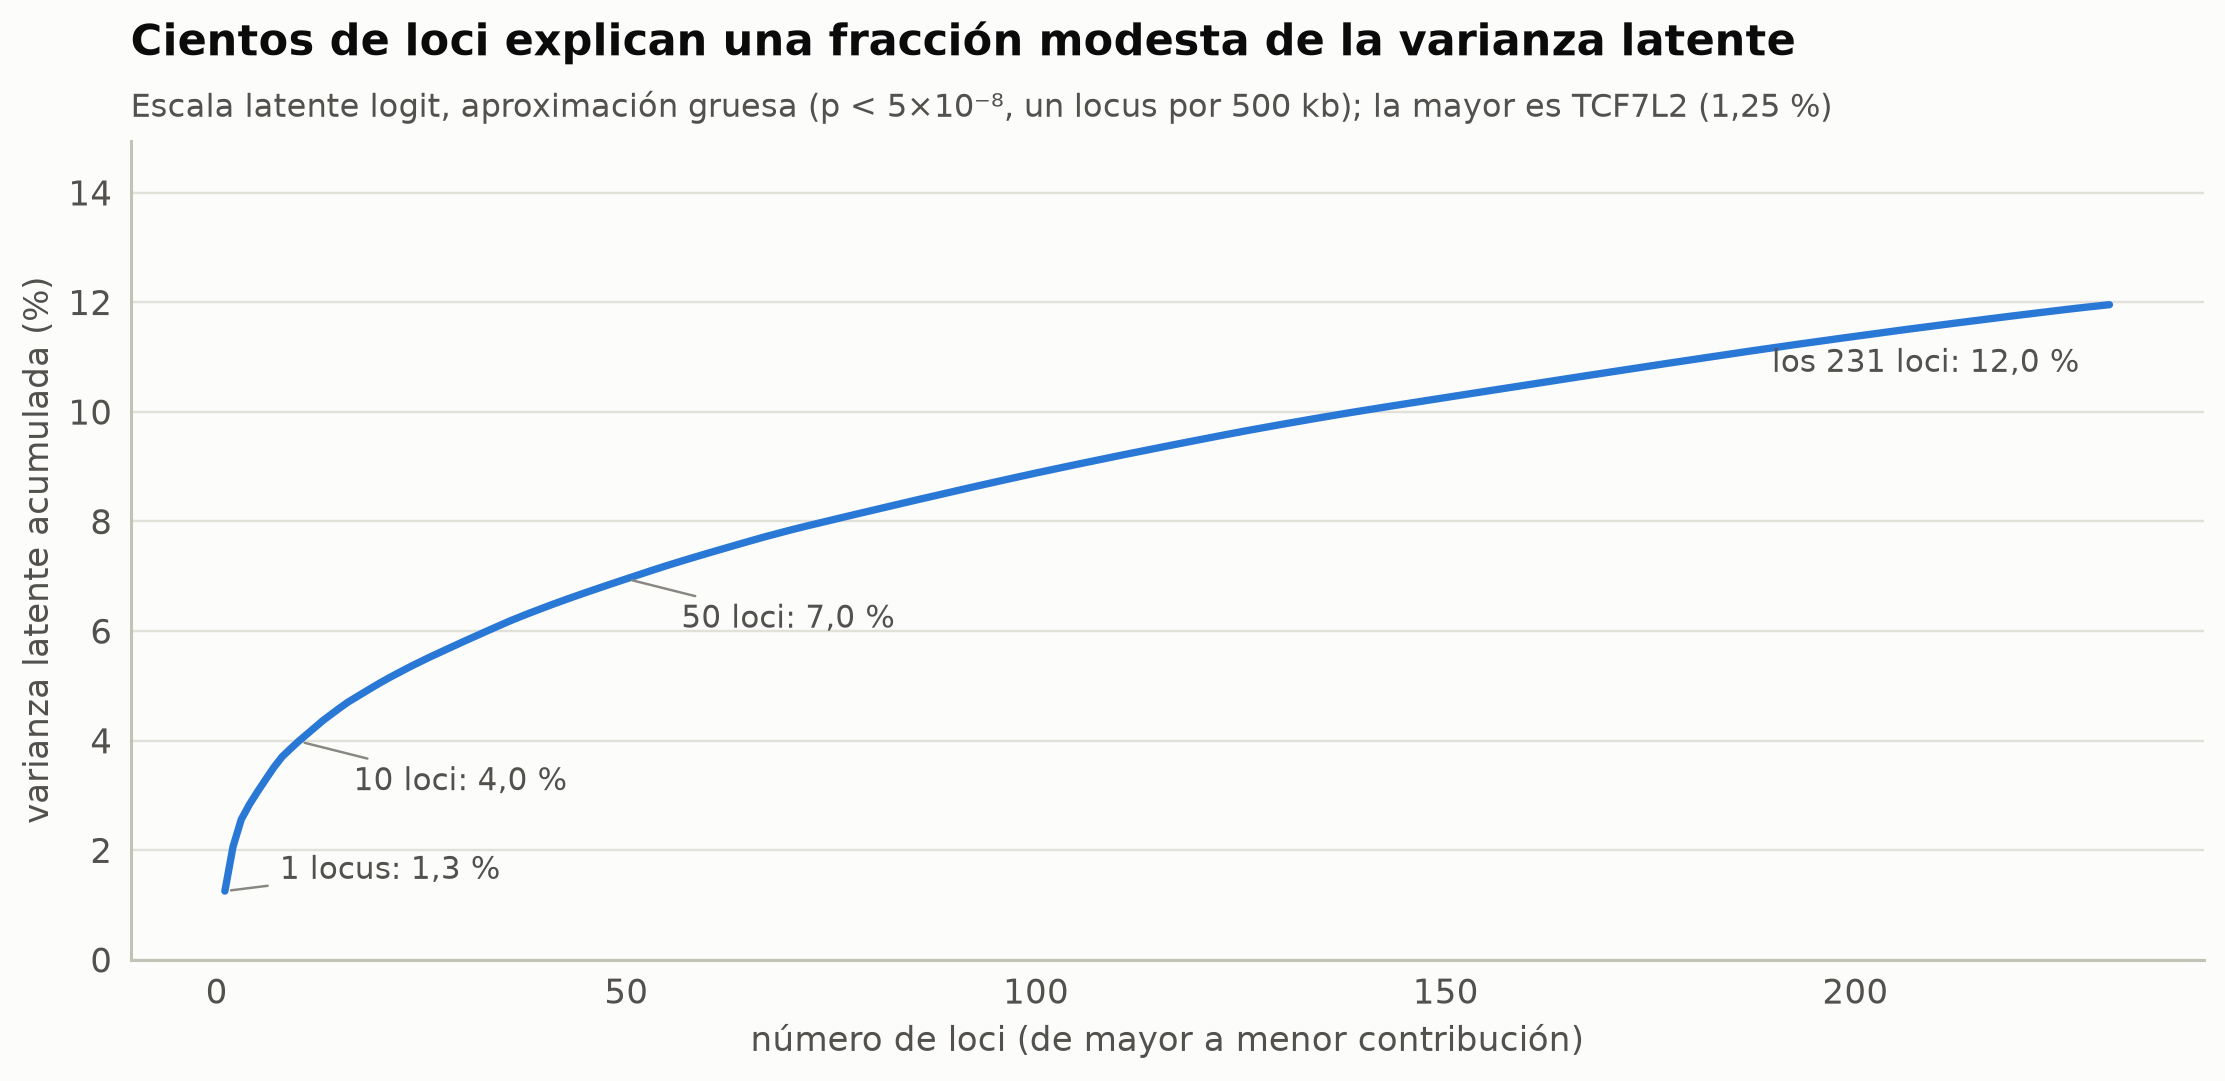

Suma de h² (escala latente logit) de 231 loci ≈ 12.0%


In [35]:
d["h2"] = 2 * d.raf * (1 - d.raf) * np.log(d.OR) ** 2 / (math.pi ** 2 / 3)
print(f"Todas las señales con OR y frecuencia ({len(d)}): suma ≈ {d.h2.sum():.1%}")
# Sólo p < 5e-8 y una señal por locus: la más significativa en cada ventana de ±500 kb
kept = []
for r in d[d.mlog10p >= -math.log10(GW)].sort_values("mlog10p", ascending=False).itertuples():
    if not any(r.chrom == k.chrom and abs(r.pos - k.pos) < 500_000 for k in kept):
        kept.append(r)
d = pd.DataFrame(kept).drop(columns="Index").sort_values("h2", ascending=False)
print(f"p < 5e-8: {(t2d.mlog10p >= -math.log10(GW)).sum()} señales → {len(d)} loci independientes (una por 500 kb)")
cum = d.h2.cumsum().values
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(np.arange(1, len(d) + 1), cum * 100, color=ec.BLUE, lw=2.4)
ax.set_xlabel("número de loci (de mayor a menor contribución)"); ax.set_ylabel("varianza latente acumulada (%)")
for k in (1, 10, 50):
    ax.annotate(f"{k} locus: {cum[k - 1] * 100:.1f} %".replace(".", ",") if k == 1 else
                f"{k} loci: {cum[k - 1] * 100:.1f} %".replace(".", ","), (k, cum[k - 1] * 100),
                xytext=(18, -16 if k > 1 else 4), textcoords="offset points", fontsize=10, color=ec.INK_2,
                arrowprops=dict(arrowstyle="-", color=ec.MUTED, lw=0.8))
ax.annotate(f"los {len(d)} loci: {cum[-1] * 100:.1f} %".replace(".", ","), (len(d), cum[-1] * 100),
            xytext=(-10, -22), textcoords="offset points", ha="right", fontsize=10, color=ec.INK_2)
ax.set_ylim(0, cum[-1] * 100 * 1.25)
top_gene = d.iloc[0]
ec.title(ax, "Cientos de loci explican una fracción modesta de la varianza latente",
         f"Escala latente logit, aproximación gruesa (p < 5×10⁻⁸, un locus por 500 kb); la mayor es {top_gene.genes} "
         f"({top_gene.h2 * 100:.2f} %)".replace(".", ","))
plt.show()
print(f"Suma de h² (escala latente logit) de {len(d)} loci ≈ {cum[-1]:.1%}")

> 🔎 **Qué observamos.** Contar todas las señales del catálogo daría un 16 %; quedarse con un locus por región y sólo
> con las significativas lo baja a un 12 %, y la maldición del ganador empuja todavía hacia abajo la cifra real. Del
> orden del 10–15 % en la escala latente, pues: ni siquiera más de 200 loci independientes, de uno de los GWAS más
> grandes de su época, suman una fracción grande de la varianza latente de la diabetes, mientras que los estudios de gemelos y familias atribuyen a la genética
> una parte sustancial de ella. ¿Dónde está el resto? Las explicaciones propuestas incluían variantes comunes de efecto
> demasiado pequeño para superar el umbral, variantes raras mal etiquetadas por los chips, variantes estructurales,
> interacciones y sobreestimaciones de la heredabilidad familiar. La primera resultó ser la más importante: la
> **heredabilidad SNP**, estimada con modelos mixtos (sección 4) usando *todas* las variantes a la vez y no sólo las
> significativas, recupera una parte sustancial de la heredabilidad faltante, y cada aumento del tamaño de muestra ha
> traído nuevos loci, como predice la curva de potencia.

> ⚠️ **Asociación no es causalidad (ni predicción universal).** Un GWAS encuentra correlaciones entre variantes y
> rasgos en una población concreta. El estudio que acabamos de explorar es **exclusivamente europeo**, como la mayoría
> de los GWAS publicados. Como el LD y las frecuencias alélicas difieren entre poblaciones (Lección 10.2), una variante
> etiqueta que funciona bien en una población puede no hacerlo en otra, y las puntuaciones de riesgo poligénico pierden
> buena parte de su capacidad predictiva en otras ascendencias. La asociación más fuerte del catálogo para la diabetes
> tipo 2 que obtuvimos arriba viene precisamente de un metaanálisis **multiancestría** reciente: diversificar las
> cohortes es hoy una prioridad científica, no sólo ética.

> 💡 **Idea clave.** Un GWAS es un millón de regresiones con un solo enemigo sistemático, la **estructura poblacional**,
> y un solo enemigo aleatorio, la **multiplicidad**. El gráfico QQ vigila al primero; el umbral de $5\times10^{-8}$, al
> segundo.

## 9. ✍️ Ejercicios

**Ejercicio 1 (control genómico a mano).** Ocho variantes nulas dan $z^2=0{,}10;\ 0{,}35;\ 0{,}62;\ 0{,}90;\ 1{,}30;\
1{,}85;\ 2{,}40;\ 3{,}10$. (a) Calcule $\hat\lambda_{GC}$. (b) Una variante candidata tiene $z^2=40$ ($p\approx2{,}5\times10^{-10}$).
¿Sigue siendo significativa a $5\times10^{-8}$ después del control genómico? (c) ¿Qué habría pasado si la inflación
se debiera a estratificación y la candidata tuviera frecuencias parecidas en todas las poblaciones?

In [36]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
z2 = np.array([0.10, 0.35, 0.62, 0.90, 1.30, 1.85, 2.40, 3.10])
lam1 = np.median(z2) / stats.chi2.ppf(0.5, 1)
print(f"(a) mediana = ({z2[3]} + {z2[4]})/2 = {np.median(z2):.2f}  →  λ_GC = {lam1:.2f}")
print(f"(b) z² corregido = 40 / {lam1:.2f} = {40 / lam1:.1f}  →  p = {stats.chi2.sf(40 / lam1, 1):.1e}  (ya no es significativa)")
print("(c) Con componentes principales, una variante poco diferenciada apenas se corrige: conservaría p ≈ 2,5e-10.")

(a) mediana = (0.9 + 1.3)/2 = 1.10  →  λ_GC = 2.42
(b) z² corregido = 40 / 2.42 = 16.5  →  p = 4.8e-05  (ya no es significativa)
(c) Con componentes principales, una variante poco diferenciada apenas se corrige: conservaría p ≈ 2,5e-10.


**Ejercicio 2 (Bonferroni frente a BH).** Doce pruebas dan $p = 0{,}00002;\ 0{,}0004;\ 0{,}0009;\ 0{,}003;\ 0{,}0041;\
0{,}006;\ 0{,}009;\ 0{,}012;\ 0{,}030;\ 0{,}2;\ 0{,}5;\ 0{,}8$. Con $\alpha=0{,}05$, ¿cuántas rechaza Bonferroni? ¿Cuántas
Benjamini-Hochberg? Hágalo primero a mano con una tabla como la del ejemplo del libro.

In [37]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
p12 = np.array([0.00002, 0.0004, 0.0009, 0.003, 0.0041, 0.006, 0.009, 0.012, 0.030, 0.2, 0.5, 0.8])
M12 = len(p12)
tab = pd.DataFrame({"k": np.arange(1, M12 + 1), "p_(k)": p12, "kα/M": 0.05 * np.arange(1, M12 + 1) / M12})
tab["¿p ≤ kα/M?"] = np.where(tab["p_(k)"] <= tab["kα/M"], "sí", "no")
display(tab.round(5).set_index("k").T)
print(f"Bonferroni (p ≤ {0.05 / M12:.5f}): {np.sum(p12 <= 0.05 / M12)} rechazos · "
      f"BH: k* = {benjamini_hochberg(p12).sum()} rechazos")

k,1,2,3,4,5,6,7,8,9,10,11,12
p_(k),0.00002,0.0004,0.0009,0.003,0.0041,0.006,0.009,0.012,0.03,0.2,0.5,0.8
kα/M,0.00417,0.00833,0.0125,0.01667,0.02083,0.025,0.02917,0.03333,0.0375,0.04167,0.04583,0.05
¿p ≤ kα/M?,sí,sí,sí,sí,sí,sí,sí,sí,sí,no,no,no


Bonferroni (p ≤ 0.00417): 5 rechazos · BH: k* = 9 rechazos


**Ejercicio 3 (tamaño de muestra y marcadores imperfectos).** (a) ¿Cuántas personas hacen falta para detectar con 80 %
de potencia, a $5\times10^{-8}$, una variante que explica $q^2=0{,}2\,\%$ de la varianza? (b) Si la variante causal no
está genotipada y el mejor marcador tiene $r^2=0{,}6$ con ella, el marcador explica sólo $r^2q^2$. ¿Cuántas personas
hacen falta ahora? (Es el ejercicio 8 del capítulo del libro, en versión numérica.)

In [38]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
def n_for_power(q2, target=0.8):
    lo, hi = 1e2, 1e8
    for _ in range(100):
        mid = math.sqrt(lo * hi)
        lo, hi = (mid, hi) if power_gw(mid, q2) < target else (lo, mid)
    return hi
n_a = n_for_power(0.002); n_b = n_for_power(0.6 * 0.002)
print(f"(a) q² = 0,2 %: n ≈ {n_a:,.0f}")
print(f"(b) r² = 0,6 → el marcador explica {0.6 * 0.002:.4f}: n ≈ {n_b:,.0f}  (≈ n_a / r² = {n_a / 0.6:,.0f})")
print("La no centralidad es proporcional a n·r²·q²: un marcador imperfecto equivale a perder un 40 % de la muestra.")

(a) q² = 0,2 %: n ≈ 19,761
(b) r² = 0,6 → el marcador explica 0.0012: n ≈ 32,961  (≈ n_a / r² = 32,935)
La no centralidad es proporcional a n·r²·q²: un marcador imperfecto equivale a perder un 40 % de la muestra.


**Ejercicio 4 (Campbell dentro de Europa: el límite de la PCA).** Repita el experimento de la sección 5 **sólo con las
503 personas europeas**, con un rasgo 1 DE más alto en el norte (CEU, GBR, FIN) que en el sur (IBS, TSI) y sin ninguna
causa genética. (a) ¿Aparece la asociación espuria con rs4988235? (b) ¿La corrigen 4 o 10 componentes principales
calculados con los SNP del cromosoma 22? (c) ¿Y las etiquetas de población como covariables? (d) Explique el resultado
con el umbral de detección de Patterson *et al.* (2006): la estructura sólo es visible si $F_{ST}\gtrsim1/\sqrt{nM}$.
Estime $F_{ST}$ entre CEU y TSI con el estimador de Hudson.

In [39]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
eur_m = spop == "EUR"
pe = pops[eur_m]
Xe_all = np.column_stack([GL[eur_m], G22[eur_m]])
poly = Xe_all.std(0) > 0                                  # descartar SNP monomórficos dentro de Europa
Xe = Xe_all[:, poly]; is22_e = is22[poly]; i_l = int(poly[:i_lct].sum())
PCe, lam_e = pca_genotipos(G22[eur_m], k=10)
north = np.isin(pe, ["CEU", "GBR", "FIN"]).astype(float)
ye = 1.0 * north + np.random.default_rng(2005).normal(size=len(north))
dummies = pd.get_dummies(pe, drop_first=True).values.astype(float)
print("|corr(PC_k, norte)|:", [round(float(abs(np.corrcoef(PCe[:, k], north)[0, 1])), 2) for k in range(5)])
for lab, C in (("ingenuo", None), ("4 PCs", PCe[:, :4]), ("10 PCs", PCe[:, :10]), ("etiquetas de población", dummies)):
    _, pv = gwas_lineal(ye, Xe, C)
    print(f"{lab:24s} λ_GC(chr22) = {lambda_gc(pv[is22_e]):.2f}   p(rs4988235) = {pv[i_l]:.1e}")

def hudson_fst(Ga, Gb):
    pa_, pb_ = Ga.mean(0) / 2, Gb.mean(0) / 2
    na, nb_ = 2 * len(Ga), 2 * len(Gb)
    num = (pa_ - pb_) ** 2 - pa_ * (1 - pa_) / (na - 1) - pb_ * (1 - pb_) / (nb_ - 1)
    den = pa_ * (1 - pb_) + pb_ * (1 - pa_)
    return num.sum() / den.sum()
fst = hudson_fst(G22[pops == "CEU"], G22[pops == "TSI"])
n_e, M_e = int(eur_m.sum()), G22.shape[1]
print(f"F_ST(CEU, TSI) ≈ {fst:.4f}   ·   umbral 1/√(nM) = 1/√({n_e}·{M_e}) = {1 / math.sqrt(n_e * M_e):.4f}")
print("F_ST supera el umbral sólo unas pocas veces y el primer eje lo ocupa el aislamiento de FIN: con 3 000 SNP la PCA\n"
      "ve el gradiente norte-sur de forma difusa, y los PCs corrigen la señal espuria sólo en parte (sigue con p ~ 1e-4\n"
      "o 1e-5); las etiquetas de población la eliminan. Con cientos de miles de SNP (Novembre et al., 2008) la PCA de\n"
      "europeos recupera incluso el mapa de Europa, y ésa es la escala a la que trabajan los estudios reales.")

|corr(PC_k, norte)|: [0.15, 0.42, 0.02, 0.25, 0.12]


ingenuo                  λ_GC(chr22) = 1.47   p(rs4988235) = 2.6e-08


4 PCs                    λ_GC(chr22) = 1.06   p(rs4988235) = 7.6e-06


10 PCs                   λ_GC(chr22) = 1.02   p(rs4988235) = 7.9e-05
etiquetas de población   λ_GC(chr22) = 0.98   p(rs4988235) = 8.4e-01
F_ST(CEU, TSI) ≈ 0.0028   ·   umbral 1/√(nM) = 1/√(503·3112) = 0.0008
F_ST supera el umbral sólo unas pocas veces y el primer eje lo ocupa el aislamiento de FIN: con 3 000 SNP la PCA
ve el gradiente norte-sur de forma difusa, y los PCs corrigen la señal espuria sólo en parte (sigue con p ~ 1e-4
o 1e-5); las etiquetas de población la eliminan. Con cientos de miles de SNP (Novembre et al., 2008) la PCA de
europeos recupera incluso el mapa de Europa, y ésa es la escala a la que trabajan los estudios reales.


**Ejercicio 5 (un GWAS nulo y la inflación que crece).** (a) Simule 2 000 individuos y 10 000 SNP independientes sin
ningún efecto genético. Verifique que $\hat\lambda_{GC}\approx1$ y que el número de variantes con $p<10^{-4}$ es
aproximadamente 1. (b) Añada una estratificación como la del ejemplo del libro (dos poblaciones con $F_{ST}\approx0{,}02$)
y estudie cómo crece $\hat\lambda_{GC}$ con la diferencia de medias $d\in\{0;\,0{,}1;\,0{,}2;\,0{,}3;\,0{,}5\}$.

(a) λ_GC = 0.979 · p < 1e-4: 0 (esperado 1)


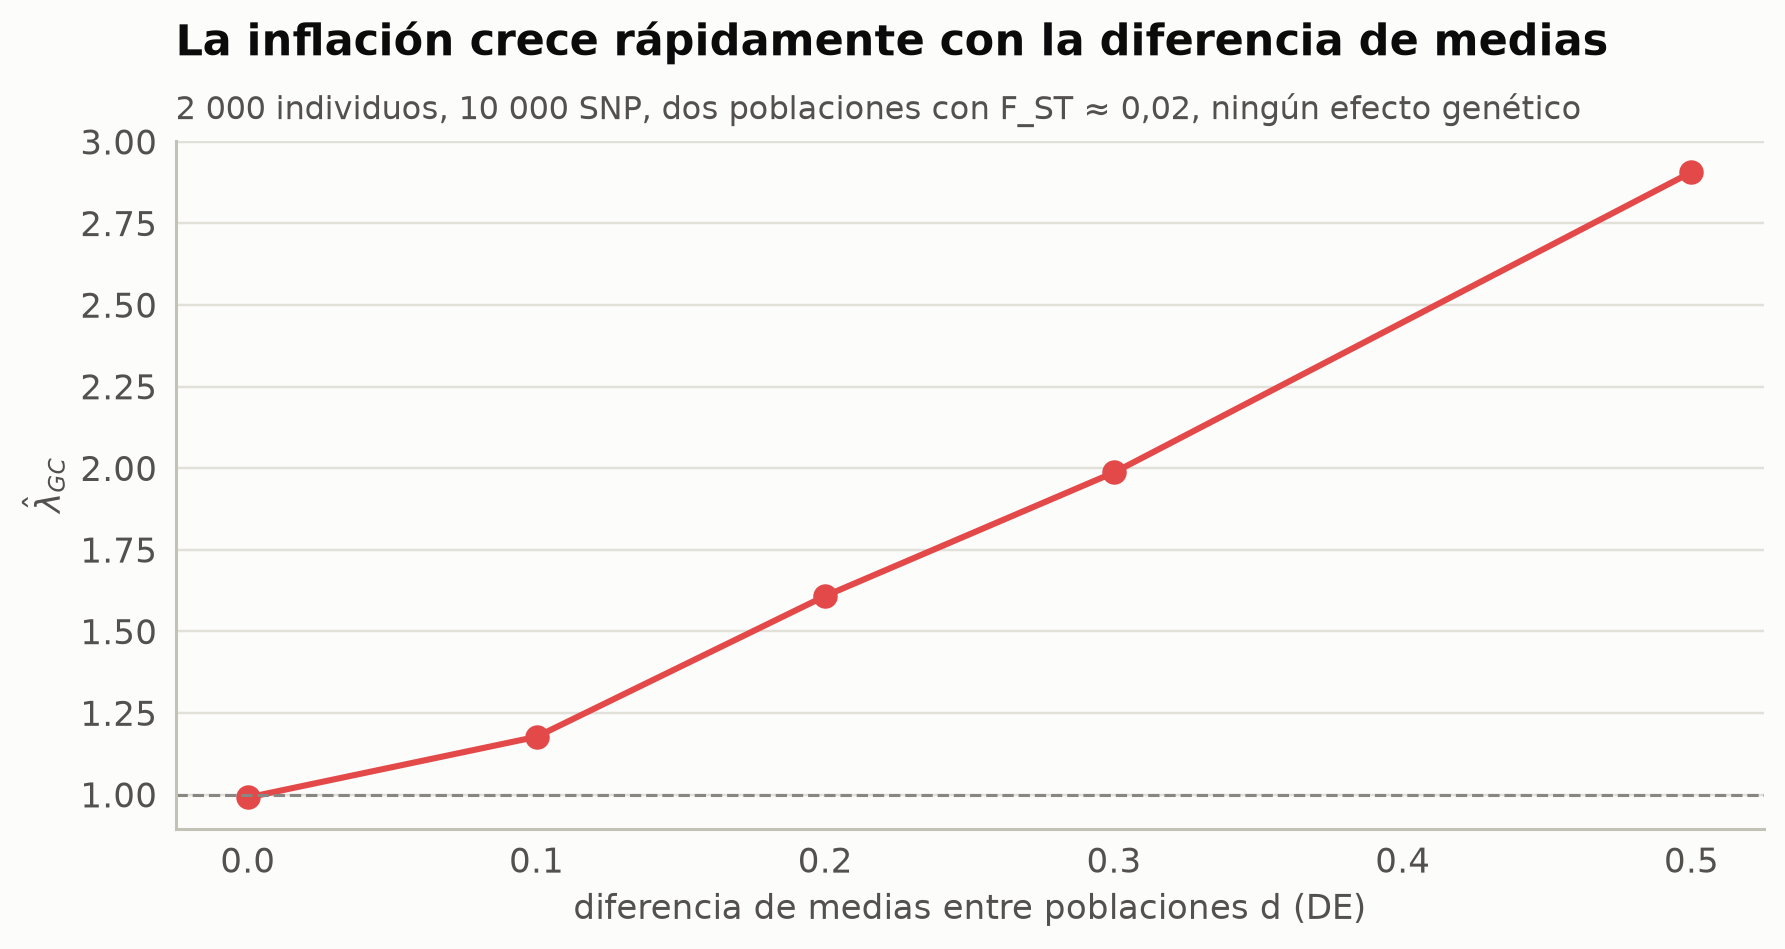

(b) {0: 0.99, 0.1: 1.18, 0.2: 1.61, 0.3: 1.99, 0.5: 2.91}


In [40]:
#@title 🔑 Solución — Ejercicio 5 { display-mode: "form" }
rng5 = np.random.default_rng(5)
n5, M5 = 2000, 10000
pa5 = rng5.uniform(0.05, 0.95, M5)
G5 = rng5.binomial(2, pa5, (n5, M5)).astype(float)
_, pv5 = gwas_lineal(rng5.normal(size=n5), G5)
print(f"(a) λ_GC = {lambda_gc(pv5):.3f} · p < 1e-4: {(pv5 < 1e-4).sum()} (esperado {M5 * 1e-4:.0f})")
q1, q2_ = balding_nichols(pa5, 0.02, rng5), balding_nichols(pa5, 0.02, rng5)
G5s = np.vstack([rng5.binomial(2, q1, (n5 // 2, M5)), rng5.binomial(2, q2_, (n5 // 2, M5))]).astype(float)
pop5 = np.r_[np.zeros(n5 // 2), np.ones(n5 // 2)]
ds = [0, 0.1, 0.2, 0.3, 0.5]
lams5 = [lambda_gc(gwas_lineal(d_ * pop5 + rng5.normal(size=n5), G5s)[1]) for d_ in ds]
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(ds, lams5, "o-", color=ec.RED, lw=2)
ax.axhline(1, color=ec.MUTED, ls="--", lw=1)
ax.set_xlabel("diferencia de medias entre poblaciones d (DE)"); ax.set_ylabel("$\\hat\\lambda_{GC}$")
ec.title(ax, "La inflación crece rápidamente con la diferencia de medias",
         "2 000 individuos, 10 000 SNP, dos poblaciones con F_ST ≈ 0,02, ningún efecto genético")
plt.show()
print("(b)", {d_: round(float(l_), 2) for d_, l_ in zip(ds, lams5)})

## 📌 Resumen

* Un **GWAS** ajusta una regresión **aditiva** por variante ($g_{ij}\in\{0,1,2\}$): lineal para rasgos cuantitativos,
  logística (o la prueba de tendencia de Armitage) para casos y controles. El modelo aditivo tiene buena potencia incluso
  si la variante es dominante o recesiva.
* Una variante explica $q_j^2=2p_j(1-p_j)\beta_j^2/\sigma_y^2$ de la varianza, y la no centralidad de la prueba es
  $nq^2/(1-q^2)$. Con $q^2=0{,}1\,\%$ hacen falta unas 40 000 personas para un 80 % de potencia a $5\times10^{-8}$; lo
  verificamos por simulación sobre genotipos reales.
* La **estratificación poblacional** infla todo el genoma ($\hat\lambda_{GC}>1$, QQ despegado desde el principio). El
  control genómico corrige a todos por igual; los **componentes principales** corrigen a cada variante según su
  diferenciación. Reprodujimos el ejemplo del libro ($\hat\lambda_{GC}$ 1,86 → 0,98) y fabricamos, sobre 2 504 genomas
  reales, una falsa asociación con *LCT* al estilo de Campbell *et al.* (2005) que desaparece con 4 PCs.
* El **control de calidad** importa: un SNP con casi todos heterocigotos es un paralog, no un alelo; y la prueba de HWE
  debe hacerse **dentro** de cada población para no descartar variantes diferenciadas por efecto Wahlund.
* **Bonferroni** controla la probabilidad de al menos un falso positivo; con un millón de pruebas efectivas da
  $5\times10^{-8}$. **Benjamini-Hochberg** controla la proporción esperada de falsos descubrimientos (FDR) y siempre
  declara al menos tantos como Bonferroni.
* En un **Manhattan**, cada señal es una torre de variantes en LD; la líder no es necesariamente la causal, el gen más
  cercano no es necesariamente el efector, y una aguja aislada es sospechosa.
* El **GWAS Catalog** muestra que los rasgos complejos son muy poligénicos (cientos de señales para la diabetes tipo 2),
  que los estudios sólo ven lo que queda por encima de su frontera de detección y que las señales significativas explican
  sólo una parte de la heredabilidad: la **heredabilidad faltante**.

## 📚 Lecturas y referencias

* Armitage, P. (1955). Tests for linear trends in proportions and frequencies. *Biometrics*, 11(3), 375–386.
* Benjamini, Y. y Hochberg, Y. (1995). Controlling the false discovery rate: a practical and powerful approach to
  multiple testing. *Journal of the Royal Statistical Society B*, 57(1), 289–300.
* Bersaglieri, T. *et al.* (2004). Genetic signatures of strong recent positive selection at the lactase gene.
  *American Journal of Human Genetics*, 74(6), 1111–1120. https://doi.org/10.1086/421051
* Campbell, C. D. *et al.* (2005). Demonstrating stratification in a European American population. *Nature Genetics*,
  37(8), 868–872. https://doi.org/10.1038/ng1607
* Chang, C. C. *et al.* (2015). Second-generation PLINK: rising to the challenge of larger and richer datasets.
  *GigaScience*, 4, 7. https://doi.org/10.1186/s13742-015-0047-8
* Devlin, B. y Roeder, K. (1999). Genomic control for association studies. *Biometrics*, 55(4), 997–1004.
* Enattah, N. S. *et al.* (2002). Identification of a variant associated with adult-type hypolactasia. *Nature
  Genetics*, 30(3), 233–237. https://doi.org/10.1038/ng826
* Loh, P.-R. *et al.* (2015). Efficient Bayesian mixed-model analysis increases association power in large cohorts.
  *Nature Genetics*, 47(3), 284–290. https://doi.org/10.1038/ng.3190
* Mahajan, A. *et al.* (2018). Fine-mapping type 2 diabetes loci to single-variant resolution using high-density
  imputation and islet-specific epigenome maps. *Nature Genetics*, 50(11), 1505–1513.
  https://doi.org/10.1038/s41588-018-0241-6
* Manolio, T. A. *et al.* (2009). Finding the missing heritability of complex diseases. *Nature*, 461(7265), 747–753.
  https://doi.org/10.1038/nature08494
* Novembre, J. *et al.* (2008). Genes mirror geography within Europe. *Nature*, 456(7218), 98–101.
  https://doi.org/10.1038/nature07331
* Patterson, N., Price, A. L. y Reich, D. (2006). Population structure and eigenanalysis. *PLoS Genetics*, 2(12), e190.
* Pe'er, I. *et al.* (2008). Estimation of the multiple testing burden for genomewide association studies of nearly all
  common variants. *Genetic Epidemiology*, 32(4), 381–385. https://doi.org/10.1002/gepi.20303
* Price, A. L. *et al.* (2006). Principal components analysis corrects for stratification in genome-wide association
  studies. *Nature Genetics*, 38(8), 904–909. https://doi.org/10.1038/ng1847
* Purcell, S. *et al.* (2007). PLINK: a tool set for whole-genome association and population-based linkage analyses.
  *American Journal of Human Genetics*, 81(3), 559–575. https://doi.org/10.1086/519795
* Sollis, E. *et al.* (2023). The NHGRI-EBI GWAS Catalog: knowledgebase and deposition resource. *Nucleic Acids
  Research*, 51(D1), D977–D985. https://doi.org/10.1093/nar/gkac1010
* The 1000 Genomes Project Consortium (2015). A global reference for human genetic variation. *Nature*, 526(7571),
  68–74. https://doi.org/10.1038/nature15393
* The Wellcome Trust Case Control Consortium (2007). Genome-wide association study of 14,000 cases of seven common
  diseases and 3,000 shared controls. *Nature*, 447(7145), 661–678. https://doi.org/10.1038/nature05911
* Visscher, P. M. *et al.* (2017). 10 years of GWAS discovery: biology, function, and translation. *American Journal of
  Human Genetics*, 101(1), 5–22. https://doi.org/10.1016/j.ajhg.2017.06.005
* Yang, J. *et al.* (2011). GCTA: a tool for genome-wide complex trait analysis. *American Journal of Human Genetics*,
  88(1), 76–82. https://doi.org/10.1016/j.ajhg.2010.11.011

**Datos:** Proyecto 1000 Genomas, fase 3 (GRCh37); GWAS Catalog, API REST v2 (https://www.ebi.ac.uk/gwas/rest/api/v2),
estudio GCST009379 y asociaciones con MONDO_0005148, respuestas guardadas en `data/api_cache/`.

---

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai)